# Exploratory Data Analysis - BTC/ETH USDT-M Perpetual Futures

**Master's Thesis in Data Science - Chapter 4: Data and Exploratory Data Analysis**

This notebook is the reproducible exploratory analysis underpinning a thesis on the automated
discovery, validation and machine-learning enhancement of interpretable trading strategies for
BTCUSDT and ETHUSDT USDT-M perpetual futures. It is deliberately *analytically deep but technically
thin*: all statistical, validation and plotting logic lives in tested modules under `src/perp_lab/`,
and the notebook orchestrates those functions, arranges results and provides interpretation.

## 1. Executive summary and reproducibility

**Objective.** Understand and characterise the market data before any feature is engineered or any
model is trained. This EDA describes data integrity, price behaviour, return distributions, tail
risk, volatility, temporal dependence, market activity and order flow, funding, cross-asset
dependence, timeframe trade-offs and preliminary volatility regimes, and connects each finding to a
later methodological decision (Chapter 5).

**Scope of this notebook (EDA, not feature engineering).** We compute *exploratory* quantities only:
log/absolute/squared returns, rolling volatility, drawdown, relative volume, taker-buy imbalance,
funding, trade-vs-mark basis, correlations and preliminary volatility regimes. We deliberately do
**not** build a technical-indicator catalogue (RSI, MACD, Bollinger, etc.), perform feature
selection, compute SHAP or train models; those belong to Chapter 5.

**Reproducibility.** Everything is driven by the versioned data contract
(`configs/data_contract.yaml`) and EDA configuration (`configs/eda.yaml`). We pin the random seed,
record package versions, resolve the development window and the frozen-holdout boundary, and fix the
24/7 (365-day) annualisation convention. Paths are relative to the repository root. Figures are
exported as high-resolution PNG plus vector PDF with a JSON metadata sidecar; tables are exported as
CSV and Markdown.

**Temporal separation (mandatory).** Development window: `2020-01-01 00:00 UTC` .. `2025-12-31 23:55
UTC`. Frozen holdout: `[2026-01-01 00:00 UTC, 2026-07-01 00:00 UTC)`. **No holdout observation is
loaded, analysed, plotted or used to compute any statistic or threshold.** A hard assertion fails the
notebook if any analysed observation carries a timestamp at or after `2026-01-01 00:00 UTC`.

**What this EDA cannot prove.** Exploratory analysis is descriptive. A statistically significant
autocorrelation at high frequency does not imply an exploitable edge once costs, slippage and
multiple testing are accounted for. Every pattern here is a *hypothesis* to be validated on the
frozen holdout and via a cost-aware backtest in a later phase.

### Research questions

- **RQ1.** Are the BTC/ETH perpetual datasets complete and internally consistent on 5m, 15m and 1h?
- **RQ2.** How are returns distributed, and how does aggregation from 5m to 1h change shape and tails?
- **RQ3.** How large is historical tail risk (VaR/ES, drawdowns) and how does it scale with timeframe?
- **RQ4.** Is volatility persistent and clustered, and are returns stationary?
- **RQ5.** Is there dependence in return *direction* versus return *magnitude/volatility*?
- **RQ6.** Do volume, order flow, liquidity proxies and funding show stable, interpretable structure?
- **RQ7.** How strongly and stably do BTC and ETH co-move, including in the tails?
- **RQ8.** Can we define transparent, provisional market regimes useful for later risk/strategy design?

## 2. Configuration and data loading

**Analytical question.** What exactly are we analysing, and can we guarantee the holdout is excluded?
**Method.** We centralise all configuration (paths, assets, timeframes, development dates, plotting
style, random seed, figure format/DPI), load only the *development* partitions through the
holdout-safe `DataLake`, and then run two hard gates: (i) a holdout guard that fails if any analysed
timestamp reaches the holdout, and (ii) an expected-vs-observed observation-count check that stops
execution on any mismatch. **Interpretation.** If both gates pass, every downstream result is
computed strictly on development data with the exact expected coverage.

In [1]:
# Locate the repository root and make src/ importable, so the notebook runs
# unchanged from the repository root or from the notebooks/ directory.
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
REPO_ROOT = _root

# matplotlib stamps a CreationDate into every PDF; pinning this keeps two runs
# of the notebook byte-identical instead of differing in metadata alone.
os.environ.setdefault("SOURCE_DATE_EPOCH", "946684800")
print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
import platform
from datetime import UTC, datetime, timedelta

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy
import statsmodels
from IPython.display import display
from scipy import stats as sstats

from perp_lab import __version__ as perp_lab_version
from perp_lab import eda
from perp_lab.config import load_data_contract, load_eda_config, load_settings
from perp_lab.config.models import Paths
from perp_lab.eda import DataLake
from perp_lab.reporting import (
    ArtifactContext,
    apply_house_style,
    asset_color,
    regime_color,
    save_figure,
    save_table,
)
from perp_lab.utils.timeutils import TIMEFRAME_TO_MS
from perp_lab.validation.quality import find_gaps, quality_report

apply_house_style()
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# --- Centralised configuration and reproducibility ---------------------------
SETTINGS = load_settings()
SEED = SETTINGS.seed
np.random.seed(SEED)

CONTRACT = load_data_contract()
EDA_CFG = load_eda_config()
PATHS = Paths()
LAKE = DataLake(CONTRACT, PATHS)

SYMBOLS = list(CONTRACT.symbol_names())  # ["BTCUSDT", "ETHUSDT"]
TIMEFRAMES = list(CONTRACT.all_timeframes())  # ["5m", "15m", "1h"]
PRIMARY_TF = "1h"  # selected primary timeframe (justified in Section 11)
HOLDOUT_START = LAKE.holdout_start  # tz-aware UTC
CUTOFF = datetime(
    CONTRACT.cutoff_date.year, CONTRACT.cutoff_date.month, CONTRACT.cutoff_date.day, tzinfo=UTC
)
DAYS_PER_YEAR = EDA_CFG.trading_days_per_year  # 365 (24/7 crypto)
DAY_WINDOW = {"5m": 288, "15m": 96, "1h": 24}  # bars in one 24h clock day
FIG_DPI = 300  # raster export DPI (vector PDF also written)

# Expected DEVELOPMENT observation counts (2020-01-01 .. 2025-12-31 23:55 UTC).
# These are the theoretical 24/7 counts; they are CHECKED, never forced.
EXPECTED_COUNTS = {
    ("BTCUSDT", "5m"): 631296,
    ("ETHUSDT", "5m"): 631296,
    ("BTCUSDT", "15m"): 210432,
    ("ETHUSDT", "15m"): 210432,
    ("BTCUSDT", "1h"): 52608,
    ("ETHUSDT", "1h"): 52608,
}
EXPECTED_FUNDING = 6576  # per asset (8h schedule)

print("Environment")
print(f"  Python      : {platform.python_version()} ({sys.platform})")
print(f"  perp_lab    : {perp_lab_version}")
print(f"  polars      : {pl.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")
print(f"  statsmodels : {statsmodels.__version__} | matplotlib {matplotlib.__version__}")
print(f"  random seed : {SEED}")
print("Data contract")
print(f"  exchange/market : {CONTRACT.exchange}/{CONTRACT.market_type}")
print(f"  symbols         : {SYMBOLS}")
print(
    f"  timeframes      : base={CONTRACT.base_timeframe}, derived={list(CONTRACT.derived_timeframes)}"
)
print(f"  cutoff (excl.)  : {CUTOFF.isoformat()}")
print(f"  holdout start   : {HOLDOUT_START.isoformat()}  (frozen; excluded from EDA)")
print(f"  annualisation   : {DAYS_PER_YEAR} days (24/7)")

Environment
  Python      : 3.12.3 (win32)
  perp_lab    : 0.1.0
  polars      : 1.43.1 | numpy 2.5.1 | scipy 1.18.0
  statsmodels : 0.14.6 | matplotlib 3.11.1
  random seed : 42
Data contract
  exchange/market : binance/um
  symbols         : ['BTCUSDT', 'ETHUSDT']
  timeframes      : base=5m, derived=['15m', '1h']
  cutoff (excl.)  : 2026-07-01T00:00:00+00:00
  holdout start   : 2026-01-01T00:00:00+00:00  (frozen; excluded from EDA)
  annualisation   : 365 days (24/7)


In [3]:
# --- Artifact export context (figures/tables + reproducibility sidecars) -----
NB_ID = "01_comprehensive_exploratory_data_analysis"
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "eda",
    tables_dir=PATHS.reports_root / "tables" / "eda",
    metadata_dir=PATHS.reports_root / "metadata" / "eda",
    config={
        "seed": SEED,
        "contract_version": CONTRACT.version,
        "cutoff": CUTOFF.isoformat(),
        "holdout_start": HOLDOUT_START.isoformat(),
        "timeframes": TIMEFRAMES,
        "primary_timeframe": PRIMARY_TF,
        "days_per_year": DAYS_PER_YEAR,
        "return_kind": EDA_CFG.return_kind,
        "rolling_moment_window_days": EDA_CFG.rolling_moment_window_days,
    },
    repo_root=".",
)


def show(fig, name, caption=""):
    # Save a figure (PNG + vector PDF + metadata sidecar) and embed it, then close it.
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


# --- Load DEVELOPMENT partitions only (holdout excluded on load) -------------
KL: dict[str, dict[str, pl.DataFrame]] = {s: {} for s in SYMBOLS}
RET: dict[str, dict[str, pl.DataFrame]] = {s: {} for s in SYMBOLS}
FUND: dict[str, pl.DataFrame] = {}
MARK: dict[str, pl.DataFrame] = {}

prov_rows: list[dict] = []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        ds = LAKE.load_klines(sym, tf, partition="development")
        KL[sym][tf] = ds.frame
        RET[sym][tf] = eda.add_simple_returns(eda.add_log_returns(ds.frame))
        ctx.datasets[ds.dataset_id] = ds.sha256 or ""
        prov_rows.append(
            {
                "dataset_id": ds.dataset_id,
                "rows": ds.n_rows,
                "start": str(ds.period_start),
                "end": str(ds.period_end),
                "sha256_12": (ds.sha256 or "")[:12],
                "holdout_excluded": ds.holdout_excluded,
            }
        )
    fds = LAKE.load_funding(sym, partition="development")
    FUND[sym] = fds.frame
    ctx.datasets[fds.dataset_id] = fds.sha256 or ""
    prov_rows.append(
        {
            "dataset_id": fds.dataset_id,
            "rows": fds.n_rows,
            "start": str(fds.period_start),
            "end": str(fds.period_end),
            "sha256_12": (fds.sha256 or "")[:12],
            "holdout_excluded": fds.holdout_excluded,
        }
    )
    mds = LAKE.load_mark(sym, partition="development")
    MARK[sym] = mds.frame
    ctx.datasets[mds.dataset_id] = mds.sha256 or ""
    prov_rows.append(
        {
            "dataset_id": mds.dataset_id,
            "rows": mds.n_rows,
            "start": str(mds.period_start),
            "end": str(mds.period_end),
            "sha256_12": (mds.sha256 or "")[:12],
            "holdout_excluded": mds.holdout_excluded,
        }
    )

provenance = pl.DataFrame(prov_rows)
_btc_1h = RET[SYMBOLS[0]][PRIMARY_TF]
DEV_START = _btc_1h.select(pl.col("open_time").min()).item()
DEV_END = _btc_1h.select(pl.col("open_time").max()).item()
ctx.period = f"{DEV_START} .. {DEV_END} (development, holdout excluded)"
print(f"Development span (BTC {PRIMARY_TF}): {DEV_START}  ..  {DEV_END}")
print(f"Datasets loaded: {len(ctx.datasets)}")

Development span (BTC 1h): 2020-01-01 00:00:00+00:00  ..  2025-12-31 23:00:00+00:00
Datasets loaded: 10


In [4]:
# === Gate 1: Holdout guard (must never fail) =================================
EXPECTED_HOLDOUT = datetime(2026, 1, 1, tzinfo=UTC)
assert HOLDOUT_START == EXPECTED_HOLDOUT, f"Holdout boundary drifted: {HOLDOUT_START}"
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        eda.assert_no_holdout(KL[sym][tf], HOLDOUT_START, time_col="open_time")
    eda.assert_no_holdout(FUND[sym], HOLDOUT_START, time_col="funding_time")
    eda.assert_no_holdout(MARK[sym], HOLDOUT_START, time_col="open_time")
print(f"GATE 1 PASSED - every analysed frame ends strictly before {HOLDOUT_START.isoformat()}")

# === Gate 2: Expected vs observed observation counts (stop on mismatch) ======
count_rows, mismatches = [], []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        obs = KL[sym][tf].height
        exp = EXPECTED_COUNTS[(sym, tf)]
        ok = obs == exp
        count_rows.append(
            {
                "symbol": sym,
                "stream": tf,
                "expected": exp,
                "observed": obs,
                "coverage_pct": round(100 * obs / exp, 4),
                "match": ok,
            }
        )
        if not ok:
            mismatches.append(f"{sym} {tf}: expected {exp}, observed {obs}")
    fobs = FUND[sym].height
    fok = fobs == EXPECTED_FUNDING
    count_rows.append(
        {
            "symbol": sym,
            "stream": "funding",
            "expected": EXPECTED_FUNDING,
            "observed": fobs,
            "coverage_pct": round(100 * fobs / EXPECTED_FUNDING, 4),
            "match": fok,
        }
    )
    if not fok:
        mismatches.append(f"{sym} funding: expected {EXPECTED_FUNDING}, observed {fobs}")
count_check = pl.DataFrame(count_rows)
with pl.Config(tbl_rows=30, tbl_width_chars=200):
    print(count_check)
if mismatches:
    raise AssertionError(
        "Observation-count mismatch (data differs from the contract):\n  " + "\n  ".join(mismatches)
    )
print("GATE 2 PASSED - observed counts match the expected development-window counts exactly.")
DEV_FIRST = datetime(2020, 1, 1, tzinfo=UTC)
DEV_LAST = datetime(2025, 12, 31, 23, 55, tzinfo=UTC)
COVERAGE_COMPLETE = True

GATE 1 PASSED - every analysed frame ends strictly before 2026-01-01T00:00:00+00:00
shape: (8, 6)
┌─────────┬─────────┬──────────┬──────────┬──────────────┬───────┐
│ symbol  ┆ stream  ┆ expected ┆ observed ┆ coverage_pct ┆ match │
│ ---     ┆ ---     ┆ ---      ┆ ---      ┆ ---          ┆ ---   │
│ str     ┆ str     ┆ i64      ┆ i64      ┆ f64          ┆ bool  │
╞═════════╪═════════╪══════════╪══════════╪══════════════╪═══════╡
│ BTCUSDT ┆ 5m      ┆ 631296   ┆ 631296   ┆ 100.0        ┆ true  │
│ BTCUSDT ┆ 15m     ┆ 210432   ┆ 210432   ┆ 100.0        ┆ true  │
│ BTCUSDT ┆ 1h      ┆ 52608    ┆ 52608    ┆ 100.0        ┆ true  │
│ BTCUSDT ┆ funding ┆ 6576     ┆ 6576     ┆ 100.0        ┆ true  │
│ ETHUSDT ┆ 5m      ┆ 631296   ┆ 631296   ┆ 100.0        ┆ true  │
│ ETHUSDT ┆ 15m     ┆ 210432   ┆ 210432   ┆ 100.0        ┆ true  │
│ ETHUSDT ┆ 1h      ┆ 52608    ┆ 52608    ┆ 100.0        ┆ true  │
│ ETHUSDT ┆ funding ┆ 6576     ┆ 6576     ┆ 100.0        ┆ true  │
└─────────┴─────────┴──────────

## 3. Data sources and analytical scope

**Analytical question.** What are the data sources, their canonical schema and units, and the exact
analytical scope? **Method.** We document provenance (Binance USDT-M perpetuals via
`data.binance.vision`), the canonical kline schema with units and timestamp semantics, and assemble a
compact **dataset inventory (Summary Table 1)** covering every asset/stream, its row count, coverage
and time span. **Interpretation.** Timestamps label the *open* of each bar, are UTC and
left-closed/right-open. Open interest is not available in the bulk archive for the full history and
is therefore excluded (documented in `docs/data_contract.md`).

In [5]:
# Canonical schema and a column dictionary.
_schema_df = KL[SYMBOLS[0]]["5m"]
_units = {
    "open_time": "UTC bar-open timestamp (ms precision)",
    "open": "first trade price in bar (USDT)",
    "high": "max price in bar (USDT)",
    "low": "min price in bar (USDT)",
    "close": "last trade price in bar (USDT)",
    "volume": "traded base volume (BTC/ETH)",
    "quote_volume": "traded quote volume (USDT ~ dollar volume)",
    "trade_count": "number of trades (int)",
    "taker_buy_base": "taker-initiated buy base volume",
    "taker_buy_quote": "taker-initiated buy quote volume (USDT)",
}
column_dict = pl.DataFrame(
    {
        "column": _schema_df.columns,
        "dtype": [str(dt) for dt in _schema_df.dtypes],
        "meaning": [_units.get(c, "") for c in _schema_df.columns],
    }
)
with pl.Config(fmt_str_lengths=60, tbl_width_chars=160):
    print(column_dict)
save_table(
    column_dict, "t02_column_dictionary", ctx, caption="Canonical kline schema, dtypes and units"
)
save_table(
    provenance,
    "t01b_dataset_provenance",
    ctx,
    caption="Development dataset provenance and content hashes",
)

shape: (10, 3)
┌─────────────────┬───────────────────────────────────────────┬────────────────────────────────────────────┐
│ column          ┆ dtype                                     ┆ meaning                                    │
│ ---             ┆ ---                                       ┆ ---                                        │
│ str             ┆ str                                       ┆ str                                        │
╞═════════════════╪═══════════════════════════════════════════╪════════════════════════════════════════════╡
│ open_time       ┆ Datetime(time_unit='ms', time_zone='UTC') ┆ UTC bar-open timestamp (ms precision)      │
│ open            ┆ Float64                                   ┆ first trade price in bar (USDT)            │
│ high            ┆ Float64                                   ┆ max price in bar (USDT)                    │
│ low             ┆ Float64                                   ┆ min price in bar (USDT)                    │
│ cl

WindowsPath('reports/tables/eda/t01b_dataset_provenance.md')

In [6]:
# === SUMMARY TABLE 1: dataset inventory and analytical scope =================
inv_rows = []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        df = KL[sym][tf]
        inv_rows.append(
            {
                "asset": sym,
                "stream": f"klines_{tf}",
                "rows": df.height,
                "expected": EXPECTED_COUNTS[(sym, tf)],
                "coverage_pct": round(100 * df.height / EXPECTED_COUNTS[(sym, tf)], 3),
                "start": str(df.select(pl.col("open_time").min()).item()),
                "end": str(df.select(pl.col("open_time").max()).item()),
            }
        )
    f = FUND[sym]
    inv_rows.append(
        {
            "asset": sym,
            "stream": "fundingRate",
            "rows": f.height,
            "expected": EXPECTED_FUNDING,
            "coverage_pct": round(100 * f.height / EXPECTED_FUNDING, 3),
            "start": str(f.select(pl.col("funding_time").min()).item()),
            "end": str(f.select(pl.col("funding_time").max()).item()),
        }
    )
    m = MARK[sym]
    inv_rows.append(
        {
            "asset": sym,
            "stream": "markPrice_5m",
            "rows": m.height,
            "expected": EXPECTED_COUNTS[(sym, "5m")],
            "coverage_pct": round(100 * m.height / EXPECTED_COUNTS[(sym, "5m")], 3),
            "start": str(m.select(pl.col("open_time").min()).item()),
            "end": str(m.select(pl.col("open_time").max()).item()),
        }
    )
dataset_inventory = pl.DataFrame(inv_rows)
with pl.Config(tbl_rows=30, tbl_width_chars=260, fmt_str_lengths=40):
    print(dataset_inventory)
save_table(
    dataset_inventory,
    "s1_dataset_inventory",
    ctx,
    caption="Summary Table 1 - dataset inventory and analytical scope (development; holdout excluded)",
)

shape: (10, 7)
┌─────────┬──────────────┬────────┬──────────┬──────────────┬───────────────────────────┬──────────────────────────────────┐
│ asset   ┆ stream       ┆ rows   ┆ expected ┆ coverage_pct ┆ start                     ┆ end                              │
│ ---     ┆ ---          ┆ ---    ┆ ---      ┆ ---          ┆ ---                       ┆ ---                              │
│ str     ┆ str          ┆ i64    ┆ i64      ┆ f64          ┆ str                       ┆ str                              │
╞═════════╪══════════════╪════════╪══════════╪══════════════╪═══════════════════════════╪══════════════════════════════════╡
│ BTCUSDT ┆ klines_5m    ┆ 631296 ┆ 631296   ┆ 100.0        ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:55:00+00:00        │
│ BTCUSDT ┆ klines_15m   ┆ 210432 ┆ 210432   ┆ 100.0        ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:45:00+00:00        │
│ BTCUSDT ┆ klines_1h    ┆ 52608  ┆ 52608    ┆ 100.0        ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:00:00+

WindowsPath('reports/tables/eda/s1_dataset_inventory.md')

**Interpretation (scope).** *What is observed:* the development sample covers BTCUSDT and ETHUSDT
from 2020-01-01 to 2025-12-31 23:55 UTC on 5m/15m/1h grids, with 8-hourly funding and 5-minute
mark-price streams; all row counts match the expected 24/7 counts exactly. *What cannot be
concluded:* full coverage does not by itself certify internal consistency (checked next). *Decision:*
proceed with all three timeframes; open interest is excluded as unavailable for the full history.

## 4. Data integrity and coverage

**Analytical question (RQ1).** Are the datasets internally consistent enough for quantitative
analysis? **Method.** For each asset/timeframe we check chronological ordering, duplicate timestamps,
missing expected timestamps, nulls, infinities, negative prices/volumes, invalid OHLC relationships,
zero-volume bars, constant-price runs, extreme returns and coverage, using the tested
`perp_lab.validation.quality` and `perp_lab.eda.coverage` functions. We assemble the **data-quality
assessment (Summary Table 2)**, verify the deterministic 5m->15m/1h resampling, summarise funding and
mark-price coverage, and show a monthly coverage heatmap. Extreme observations are *flagged, never
deleted*. The (empty) gap-structure diagnostic is deferred to the Appendix.

In [7]:
# Structural integrity checks per dataset (PASS/WARNING/FAIL classification).
_CRIT = ["open", "high", "low", "close", "volume"]


def _longest_constant_run(df):
    if df.height == 0:
        return 0
    grp = (pl.col("close") != pl.col("close").shift(1)).fill_null(True).cum_sum().alias("g")
    return int(df.select(grp).group_by("g").len().select(pl.col("len").max()).item())


status_rows, numeric_rows, fitness = [], [], {}
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        df = KL[sym][tf]
        start = df.select(pl.col("open_time").min()).item()
        last = df.select(pl.col("open_time").max()).item()
        end = last + timedelta(milliseconds=TIMEFRAME_TO_MS[tf])
        rep = quality_report(df, symbol=sym, timeframe=tf, start=start, end=end)
        n_neg = df.filter(
            (pl.col("open") < 0)
            | (pl.col("high") < 0)
            | (pl.col("low") < 0)
            | (pl.col("close") < 0)
            | (pl.col("volume") < 0)
        ).height
        n_null = int(df.select(_CRIT).null_count().to_numpy().sum())
        n_inf = int(df.select([pl.col(c).is_infinite().sum() for c in _CRIT]).to_numpy().sum())
        n_zero = df.filter(pl.col("volume") == 0).height
        const_run = _longest_constant_run(df)
        numeric_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "rows": rep.row_count,
                "expected": rep.expected_bars,
                "missing": rep.missing_bars,
                "coverage": round(rep.coverage_ratio, 5),
                "dupes": rep.duplicate_timestamps,
                "monotonic": rep.is_monotonic,
                "ohlc_viol": rep.ohlc_violations,
                "negatives": n_neg,
                "nulls": n_null,
                "infs": n_inf,
                "zero_vol": n_zero,
                "const_run": const_run,
                "extreme_flags": rep.extreme_return_flags,
            }
        )
        checks = {
            "monotonic_timestamps": ("PASS" if rep.is_monotonic else "FAIL", rep.is_monotonic),
            "duplicate_keys": (
                "PASS" if rep.duplicate_timestamps == 0 else "FAIL",
                rep.duplicate_timestamps,
            ),
            "ohlc_validity": ("PASS" if rep.ohlc_violations == 0 else "FAIL", rep.ohlc_violations),
            "negative_values": ("PASS" if n_neg == 0 else "FAIL", n_neg),
            "critical_nulls": ("PASS" if n_null == 0 else "FAIL", n_null),
            "infinite_values": ("PASS" if n_inf == 0 else "FAIL", n_inf),
            "candle_coverage": (
                "PASS"
                if rep.coverage_ratio >= 0.999
                else ("WARNING" if rep.coverage_ratio >= 0.99 else "FAIL"),
                f"{rep.coverage_ratio:.4f} ({rep.missing_bars} missing)",
            ),
            "zero_volume_bars": ("PASS" if n_zero == 0 else "WARNING", n_zero),
            "constant_price_runs": ("PASS" if const_run <= 12 else "WARNING", const_run),
            "extreme_returns_flagged": (
                "PASS" if rep.extreme_return_flags == 0 else "WARNING",
                rep.extreme_return_flags,
            ),
        }
        structural_fail = any(
            checks[c][0] == "FAIL"
            for c in (
                "monotonic_timestamps",
                "duplicate_keys",
                "ohlc_validity",
                "negative_values",
                "critical_nulls",
                "infinite_values",
            )
        )
        fitness[f"{sym} {tf}"] = "NOT FIT" if structural_fail else "FIT FOR EDA"
        for check, (st, val) in checks.items():
            status_rows.append(
                {"symbol": sym, "timeframe": tf, "check": check, "value": str(val), "status": st}
            )

integrity_status = pl.DataFrame(status_rows)
save_table(
    integrity_status,
    "t04_integrity_status",
    ctx,
    caption="Per-check PASS/WARNING/FAIL classification (development)",
)
print("Fitness verdict per dataset:")
for k, v in fitness.items():
    print(f"  {k:14s} -> {v}")

Fitness verdict per dataset:
  BTCUSDT 5m     -> FIT FOR EDA
  BTCUSDT 15m    -> FIT FOR EDA
  BTCUSDT 1h     -> FIT FOR EDA
  ETHUSDT 5m     -> FIT FOR EDA
  ETHUSDT 15m    -> FIT FOR EDA
  ETHUSDT 1h     -> FIT FOR EDA


In [8]:
# === SUMMARY TABLE 2: comprehensive data-quality assessment ==================
dq_rows = [
    eda.dataset_quality_row(KL[sym][tf], symbol=sym, timeframe=tf)
    for sym in SYMBOLS
    for tf in TIMEFRAMES
]
data_quality = pl.DataFrame(dq_rows)
with pl.Config(tbl_rows=20, tbl_width_chars=320, fmt_str_lengths=28):
    print(data_quality)
save_table(
    data_quality,
    "s2_data_quality_assessment",
    ctx,
    caption="Summary Table 2 - data-quality assessment per asset/timeframe (development): expected/observed, "
    "coverage %, missing, duplicates, invalid OHLC, nulls, negatives, zero-volume, longest gap, span",
)
COV_LOOKUP = {
    (r["symbol"], r["timeframe"]): r["coverage_pct"] for r in data_quality.iter_rows(named=True)
}

shape: (6, 15)
┌─────────┬───────────┬───────────────────────────┬───────────────────────────┬───┬─────────────────┬─────────────┬──────────────────┬───────────┐
│ symbol  ┆ timeframe ┆ start                     ┆ end                       ┆ … ┆ negative_values ┆ zero_volume ┆ longest_gap_bars ┆ monotonic │
│ ---     ┆ ---       ┆ ---                       ┆ ---                       ┆   ┆ ---             ┆ ---         ┆ ---              ┆ ---       │
│ str     ┆ str       ┆ str                       ┆ str                       ┆   ┆ i64             ┆ i64         ┆ i64              ┆ bool      │
╞═════════╪═══════════╪═══════════════════════════╪═══════════════════════════╪═══╪═════════════════╪═════════════╪══════════════════╪═══════════╡
│ BTCUSDT ┆ 5m        ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:55:00+00:00 ┆ … ┆ 0               ┆ 66          ┆ 0                ┆ true      │
│ BTCUSDT ┆ 15m       ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:45:00+00:00 ┆ … ┆ 0               ┆ 1

In [9]:
# Resampling consistency: stored 15m/1h must equal an independent 5m -> resample.
from perp_lab.data.bars import resample_klines

resample_rows = []
for sym in SYMBOLS:
    base5 = KL[sym]["5m"]
    for tf in ("15m", "1h"):
        derived = resample_klines(base5, "5m", tf, drop_incomplete=True)
        stored = KL[sym][tf]
        joined = derived.join(stored, on="open_time", how="inner", suffix="_stored")
        max_open = joined.select((pl.col("open") - pl.col("open_stored")).abs().max()).item()
        max_high = joined.select((pl.col("high") - pl.col("high_stored")).abs().max()).item()
        max_low = joined.select((pl.col("low") - pl.col("low_stored")).abs().max()).item()
        max_close = joined.select((pl.col("close") - pl.col("close_stored")).abs().max()).item()
        max_vol = joined.select((pl.col("volume") - pl.col("volume_stored")).abs().max()).item()
        max_tc = joined.select(
            (pl.col("trade_count") - pl.col("trade_count_stored")).abs().max()
        ).item()
        resample_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "stored_rows": stored.height,
                "resampled_rows": derived.height,
                "matched_rows": joined.height,
                "max_open_diff": float(max_open or 0.0),
                "max_high_diff": float(max_high or 0.0),
                "max_low_diff": float(max_low or 0.0),
                "max_close_diff": float(max_close or 0.0),
                "max_volume_diff": float(max_vol or 0.0),
                "max_tradecount_diff": int(max_tc or 0),
                "status": "PASS"
                if (max_close or 0.0) < 1e-6 and derived.height == stored.height
                else "WARNING",
            }
        )
resampling_consistency = pl.DataFrame(resample_rows)
with pl.Config(tbl_width_chars=260):
    print(resampling_consistency)
save_table(
    resampling_consistency,
    "t06_resampling_consistency",
    ctx,
    caption="Deterministic 5m->15m/1h resampling vs stored derived bars: open=first, high=max, low=min, "
    "close=last, volume=sum, trade_count=sum (development)",
)

shape: (4, 12)
┌─────────┬───────────┬─────────────┬────────────────┬───┬────────────────┬─────────────────┬─────────────────────┬────────┐
│ symbol  ┆ timeframe ┆ stored_rows ┆ resampled_rows ┆ … ┆ max_close_diff ┆ max_volume_diff ┆ max_tradecount_diff ┆ status │
│ ---     ┆ ---       ┆ ---         ┆ ---            ┆   ┆ ---            ┆ ---             ┆ ---                 ┆ ---    │
│ str     ┆ str       ┆ i64         ┆ i64            ┆   ┆ f64            ┆ f64             ┆ i64                 ┆ str    │
╞═════════╪═══════════╪═════════════╪════════════════╪═══╪════════════════╪═════════════════╪═════════════════════╪════════╡
│ BTCUSDT ┆ 15m       ┆ 210432      ┆ 210432         ┆ … ┆ 0.0            ┆ 0.0             ┆ 0                   ┆ PASS   │
│ BTCUSDT ┆ 1h        ┆ 52608       ┆ 52608          ┆ … ┆ 0.0            ┆ 0.0             ┆ 0                   ┆ PASS   │
│ ETHUSDT ┆ 15m       ┆ 210432      ┆ 210432         ┆ … ┆ 0.0            ┆ 0.0             ┆ 0               

WindowsPath('reports/tables/eda/t06_resampling_consistency.md')

In [10]:
# Auxiliary-stream coverage (funding and mark price).
aux_rows = []
for sym in SYMBOLS:
    fund = FUND[sym]
    f_start = fund.select(pl.col("funding_time").min()).item()
    f_end = fund.select(pl.col("funding_time").max()).item()
    span_h = (f_end - f_start).total_seconds() / 3600.0
    interval = float(fund.select(pl.col("funding_interval_hours").median()).item() or 8.0)
    expected_fund = int(span_h / interval) + 1
    aux_rows.append(
        {
            "symbol": sym,
            "stream": "fundingRate",
            "rows": fund.height,
            "expected_approx": expected_fund,
            "start": str(f_start),
            "end": str(f_end),
            "interval_h": interval,
            "status": "PASS" if fund.height >= 0.98 * expected_fund else "WARNING",
        }
    )
    mark = MARK[sym]
    k5 = KL[sym]["5m"].height
    aux_rows.append(
        {
            "symbol": sym,
            "stream": "markPriceKlines",
            "rows": mark.height,
            "expected_approx": k5,
            "start": str(mark.select(pl.col("open_time").min()).item()),
            "end": str(mark.select(pl.col("open_time").max()).item()),
            "interval_h": 5 / 60,
            "status": "PASS" if mark.height >= 0.98 * k5 else "WARNING",
        }
    )
aux_coverage = pl.DataFrame(aux_rows)
with pl.Config(fmt_str_lengths=40, tbl_width_chars=220):
    print(aux_coverage)
save_table(
    aux_coverage,
    "t07_aux_stream_coverage",
    ctx,
    caption="Funding and mark-price coverage (development)",
)

shape: (4, 8)
┌─────────┬─────────────────┬────────┬─────────────────┬───────────────────────────┬──────────────────────────────────┬────────────┬────────┐
│ symbol  ┆ stream          ┆ rows   ┆ expected_approx ┆ start                     ┆ end                              ┆ interval_h ┆ status │
│ ---     ┆ ---             ┆ ---    ┆ ---             ┆ ---                       ┆ ---                              ┆ ---        ┆ ---    │
│ str     ┆ str             ┆ i64    ┆ i64             ┆ str                       ┆ str                              ┆ f64        ┆ str    │
╞═════════╪═════════════════╪════════╪═════════════════╪═══════════════════════════╪══════════════════════════════════╪════════════╪════════╡
│ BTCUSDT ┆ fundingRate     ┆ 6576   ┆ 6576            ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 16:00:00.001000+00:00 ┆ 8.0        ┆ PASS   │
│ BTCUSDT ┆ markPriceKlines ┆ 628978 ┆ 631296          ┆ 2020-01-01 00:00:00+00:00 ┆ 2025-12-31 23:55:00+00:00        ┆ 0.083333   ┆ P

WindowsPath('reports/tables/eda/t07_aux_stream_coverage.md')

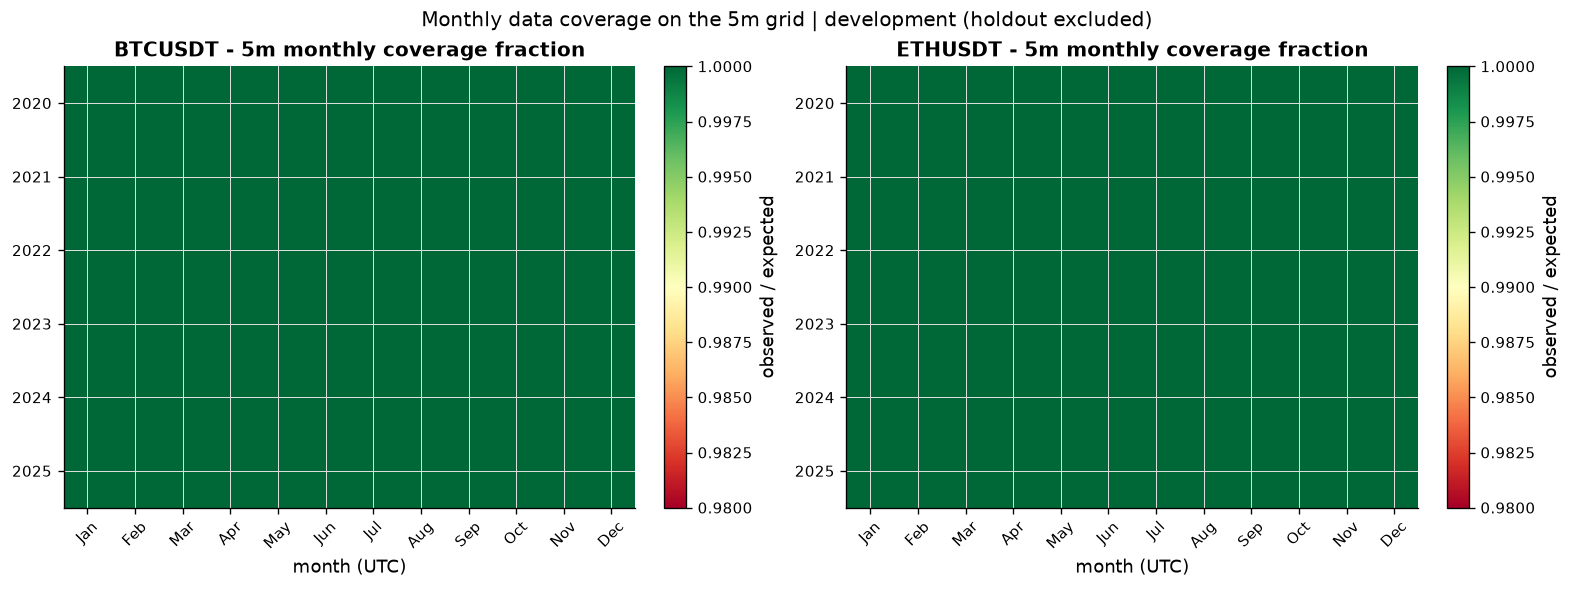

shape: (2, 4)
┌─────────┬────────┬────────────────────┬──────────────┐
│ symbol  ┆ n_gaps ┆ total_missing_bars ┆ max_gap_bars │
│ ---     ┆ ---    ┆ ---                ┆ ---          │
│ str     ┆ i64    ┆ i64                ┆ i64          │
╞═════════╪════════╪════════════════════╪══════════════╡
│ BTCUSDT ┆ 0      ┆ 0                  ┆ 0            │
│ ETHUSDT ┆ 0      ┆ 0                  ┆ 0            │
└─────────┴────────┴────────────────────┴──────────────┘

>>> No missing-candle gaps detected in the 5m trading-price klines (development). <<<


In [11]:
# Monthly data-coverage heatmap on the 5m base grid (BTC and ETH).
fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(13, 4.8), constrained_layout=True)
cmap = plt.get_cmap("RdYlGn").copy()
cmap.set_bad("lightgrey")
cov_frames = []
for j, sym in enumerate(SYMBOLS):
    cov = eda.monthly_coverage(KL[sym]["5m"], "5m")
    cov_frames.append(cov.with_columns(pl.lit(sym).alias("symbol")))
    mat, years = eda.to_year_month_matrix(cov, "coverage")
    ax = axes[j]
    im = ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=cmap, vmin=0.98, vmax=1.0)
    ax.set_xticks(range(12), MONTHS, rotation=45)
    ax.set_yticks(range(len(years)), years)
    ax.set_title(f"{sym} - 5m monthly coverage fraction")
    ax.set_xlabel("month (UTC)")
    fig.colorbar(im, ax=ax, label="observed / expected")
fig.suptitle("Monthly data coverage on the 5m grid | development (holdout excluded)", fontsize=12)
show(
    fig,
    "f02_monthly_coverage_heatmap",
    caption="Monthly 5m coverage fraction per asset (development). Grey = month absent; the scale starts at 0.98 to reveal any shortfall.",
)
monthly_cov = pl.concat(cov_frames)
save_table(
    monthly_cov,
    "t10_monthly_coverage",
    ctx,
    caption="Monthly observed/expected 5m coverage per asset (development)",
)

# Compact completeness annotation (no empty axes here; the empty gap plot is in the Appendix).
gap_summary_rows = []
for sym in SYMBOLS:
    gaps = find_gaps(KL[sym]["5m"], "5m")
    miss = gaps["missing"].to_numpy() if gaps.height else np.array([])
    gap_summary_rows.append(
        {
            "symbol": sym,
            "n_gaps": gaps.height,
            "total_missing_bars": int(miss.sum()) if miss.size else 0,
            "max_gap_bars": int(miss.max()) if miss.size else 0,
        }
    )
gap_summary = pl.DataFrame(gap_summary_rows)
print(gap_summary)
save_table(gap_summary, "t09_gap_summary", ctx, caption="5m gap summary per symbol (development)")
if int(gap_summary["n_gaps"].sum()) == 0:
    print("\n>>> No missing-candle gaps detected in the 5m trading-price klines (development). <<<")

**Interpretation (RQ1).** *What is observed:* the structural invariants hold for both assets and all
three timeframes (strict monotonicity, no duplicate keys, valid OHLC, no negatives, no critical
nulls, no infinities); observed counts equal the expected counts; the monthly heatmap is uniformly
1.0; and the stored 15m/1h bars reproduce the deterministic 5m aggregation exactly (open=first,
high=max, low=min, close=last, volume/trade-count=sum). **No missing-candle gaps were detected** in
the 5m trading-price klines over the development window, so there are zero missing intervals and zero
duplicated timestamps; we make no claim about venue outages. *Evidence:* Summary Table 2, tables
t04/t06/t07/t09/t10 and figure f02. *What cannot be concluded:* completeness does not certify that
the mark-price stream (which has a small number of unmatched 5m stamps, never imputed) is identical
to trades. *Decision:* every dataset is classified `FIT FOR EDA`; extreme observations are flagged
and retained.

## 5. Price dynamics and market episodes

**Analytical question.** What broad price regimes and drawdown episodes characterise the development
period, how do BTC and ETH compare, and how did prices behave around widely documented market events?
**Method.** On the 1h series we plot price, log price, a return-indexed normalised comparison and the
underwater (drawdown) curve; we add a monthly-returns calendar; and we overlay a **market-context**
panel that marks publicly documented events (crashes, halvings, major adoption/collapse dates)
against a transparent, price-only *market-stress proxy* (rolling-volatility percentile blended with
drawdown depth). **Note on the stress proxy and events:** the event dates are external qualitative
annotations only, and the stress index is derived exclusively from price/volatility. Neither is a
sentiment feed and neither is used to compute any threshold, feature or model input.

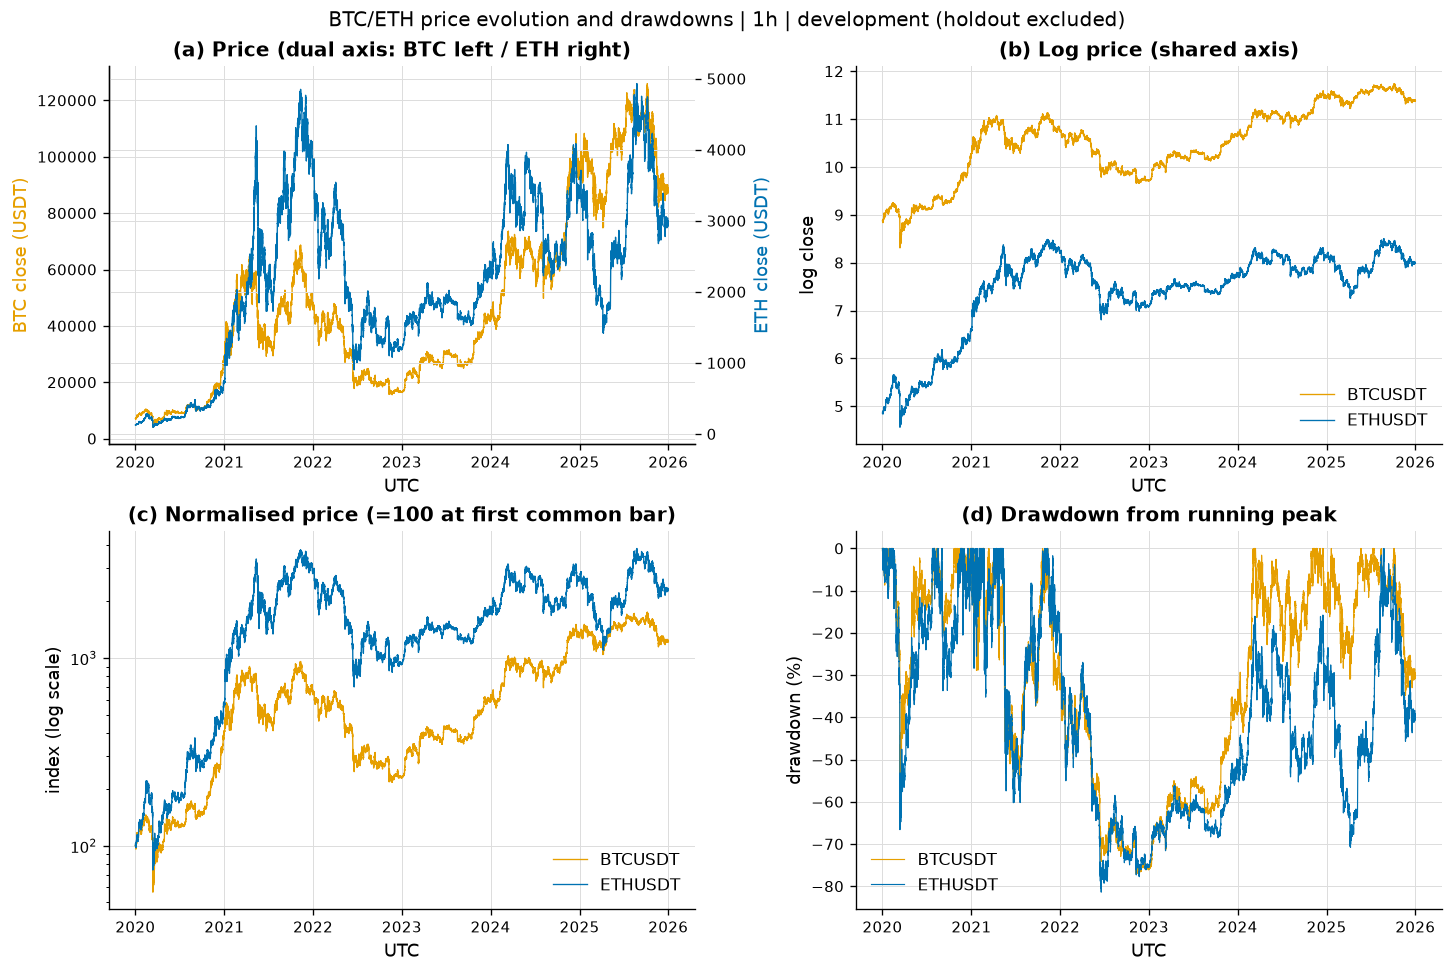

shape: (10, 7)
┌─────────┬───────────────────────────┬───────────────────────────┬───────────┬───────────────┬───────────────┬───────────┐
│ symbol  ┆ peak_time                 ┆ trough_time               ┆ depth_pct ┆ drawdown_bars ┆ recovery_bars ┆ recovered │
│ ---     ┆ ---                       ┆ ---                       ┆ ---       ┆ ---           ┆ ---           ┆ ---       │
│ str     ┆ str                       ┆ str                       ┆ f64       ┆ i64           ┆ i64           ┆ bool      │
╞═════════╪═══════════════════════════╪═══════════════════════════╪═══════════╪═══════════════╪═══════════════╪═══════════╡
│ BTCUSDT ┆ 2021-11-10 17:00:00+00:00 ┆ 2022-11-21 21:00:00+00:00 ┆ -77.24    ┆ 9028          ┆ 11273         ┆ true      │
│ BTCUSDT ┆ 2020-02-13 06:00:00+00:00 ┆ 2020-03-13 01:00:00+00:00 ┆ -61.18    ┆ 691           ┆ 3279          ┆ true      │
│ BTCUSDT ┆ 2021-04-14 06:00:00+00:00 ┆ 2021-06-22 13:00:00+00:00 ┆ -54.79    ┆ 1663          ┆ 2880          ┆ true 

WindowsPath('reports/tables/eda/t11_top_drawdowns_1h.md')

In [12]:
# Price evolution, normalised comparison and drawdown (1h development).
PRICE_TF = PRIMARY_TF
b1h, e1h = KL["BTCUSDT"][PRICE_TF], KL["ETHUSDT"][PRICE_TF]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axp = axes[0, 0]
axp2 = axp.twinx()
axp.plot(b1h["open_time"].to_numpy(), b1h["close"].to_numpy(), color=asset_color("BTCUSDT"), lw=0.8)
axp2.plot(
    e1h["open_time"].to_numpy(), e1h["close"].to_numpy(), color=asset_color("ETHUSDT"), lw=0.8
)
axp.set_ylabel("BTC close (USDT)", color=asset_color("BTCUSDT"))
axp2.set_ylabel("ETH close (USDT)", color=asset_color("ETHUSDT"))
axp.set_title("(a) Price (dual axis: BTC left / ETH right)")
axp.set_xlabel("UTC")

axl = axes[0, 1]
for sym, df in (("BTCUSDT", b1h), ("ETHUSDT", e1h)):
    axl.plot(
        df["open_time"].to_numpy(),
        np.log(df["close"].to_numpy()),
        color=asset_color(sym),
        lw=0.8,
        label=sym,
    )
axl.set_title("(b) Log price (shared axis)")
axl.set_xlabel("UTC")
axl.set_ylabel("log close")
axl.legend()

axn = axes[1, 0]
common = (
    b1h.select("open_time")
    .join(e1h.select("open_time"), on="open_time", how="inner")
    .sort("open_time")
)
t0 = common["open_time"].min()
for sym, df in (("BTCUSDT", b1h), ("ETHUSDT", e1h)):
    d = df.filter(pl.col("open_time") >= t0).sort("open_time")
    axn.plot(
        d["open_time"].to_numpy(),
        100.0 * d["close"].to_numpy() / d["close"][0],
        color=asset_color(sym),
        lw=0.8,
        label=sym,
    )
axn.set_title("(c) Normalised price (=100 at first common bar)")
axn.set_xlabel("UTC")
axn.set_ylabel("index (log scale)")
axn.set_yscale("log")
axn.legend()

axd = axes[1, 1]
for sym, df in (("BTCUSDT", b1h), ("ETHUSDT", e1h)):
    dd = eda.add_drawdown(df)
    axd.plot(
        dd["open_time"].to_numpy(),
        100.0 * dd["drawdown"].to_numpy(),
        color=asset_color(sym),
        lw=0.7,
        label=sym,
    )
axd.set_title("(d) Drawdown from running peak")
axd.set_xlabel("UTC")
axd.set_ylabel("drawdown (%)")
axd.legend()
fig.suptitle(
    f"BTC/ETH price evolution and drawdowns | {PRICE_TF} | development (holdout excluded)",
    fontsize=12,
)
show(
    fig,
    "f03_price_evolution_drawdown",
    caption="Price, log price, normalised comparison and drawdown (1h, development)",
)

dd_rows = []
for sym in SYMBOLS:
    for r in eda.top_drawdowns(KL[sym][PRICE_TF], n=5).iter_rows(named=True):
        dd_rows.append(
            {
                "symbol": sym,
                "peak_time": str(r["peak_time"]),
                "trough_time": str(r["trough_time"]),
                "depth_pct": round(100 * r["depth"], 2),
                "drawdown_bars": r["drawdown_bars"],
                "recovery_bars": r["recovery_bars"],
                "recovered": r["recovered"],
            }
        )
top_dd = pl.DataFrame(dd_rows)
with pl.Config(fmt_str_lengths=40, tbl_width_chars=220, tbl_rows=20):
    print(top_dd)
save_table(
    top_dd,
    "t11_top_drawdowns_1h",
    ctx,
    caption="Five deepest 1h drawdown episodes per asset (development)",
)

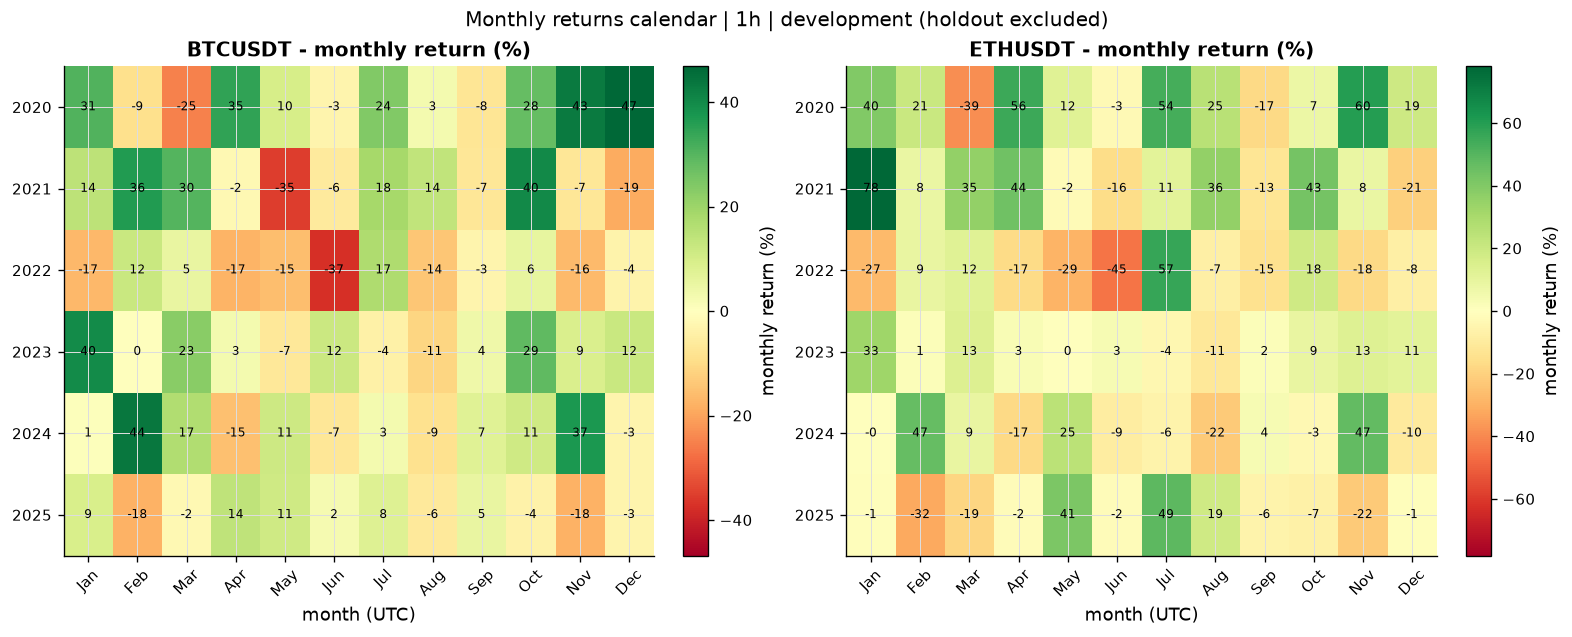

WindowsPath('reports/tables/eda/t12_monthly_returns.md')

In [13]:
# Calendar view - monthly compounded returns (%) per asset (1h series).
fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(13, 5.2), constrained_layout=True)
mcmap = plt.get_cmap("RdYlGn").copy()
mcmap.set_bad("lightgrey")
mr_frames = []
for j, sym in enumerate(SYMBOLS):
    mr = eda.monthly_returns(RET[sym][PRIMARY_TF])
    mr_frames.append(mr.with_columns(pl.lit(sym).alias("symbol")))
    mat, years = eda.to_year_month_matrix(mr, "return_pct")
    vmax = float(np.nanmax(np.abs(mat)))
    ax = axes[j]
    im = ax.imshow(np.ma.masked_invalid(mat), aspect="auto", cmap=mcmap, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(12), MONTHS, rotation=45)
    ax.set_yticks(range(len(years)), years)
    for yy in range(mat.shape[0]):
        for mm in range(12):
            if not np.isnan(mat[yy, mm]):
                ax.text(
                    mm,
                    yy,
                    f"{mat[yy, mm]:.0f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="black",
                )
    ax.set_title(f"{sym} - monthly return (%)")
    ax.set_xlabel("month (UTC)")
    fig.colorbar(im, ax=ax, label="monthly return (%)")
fig.suptitle("Monthly returns calendar | 1h | development (holdout excluded)", fontsize=12)
show(
    fig,
    "f04_calendar_monthly_returns",
    caption="Monthly compounded returns per asset (1h, development); visualises market cycles and distributional instability.",
)
save_table(
    pl.concat(mr_frames),
    "t12_monthly_returns",
    ctx,
    caption="Monthly compounded returns (%) per asset (1h, development)",
)

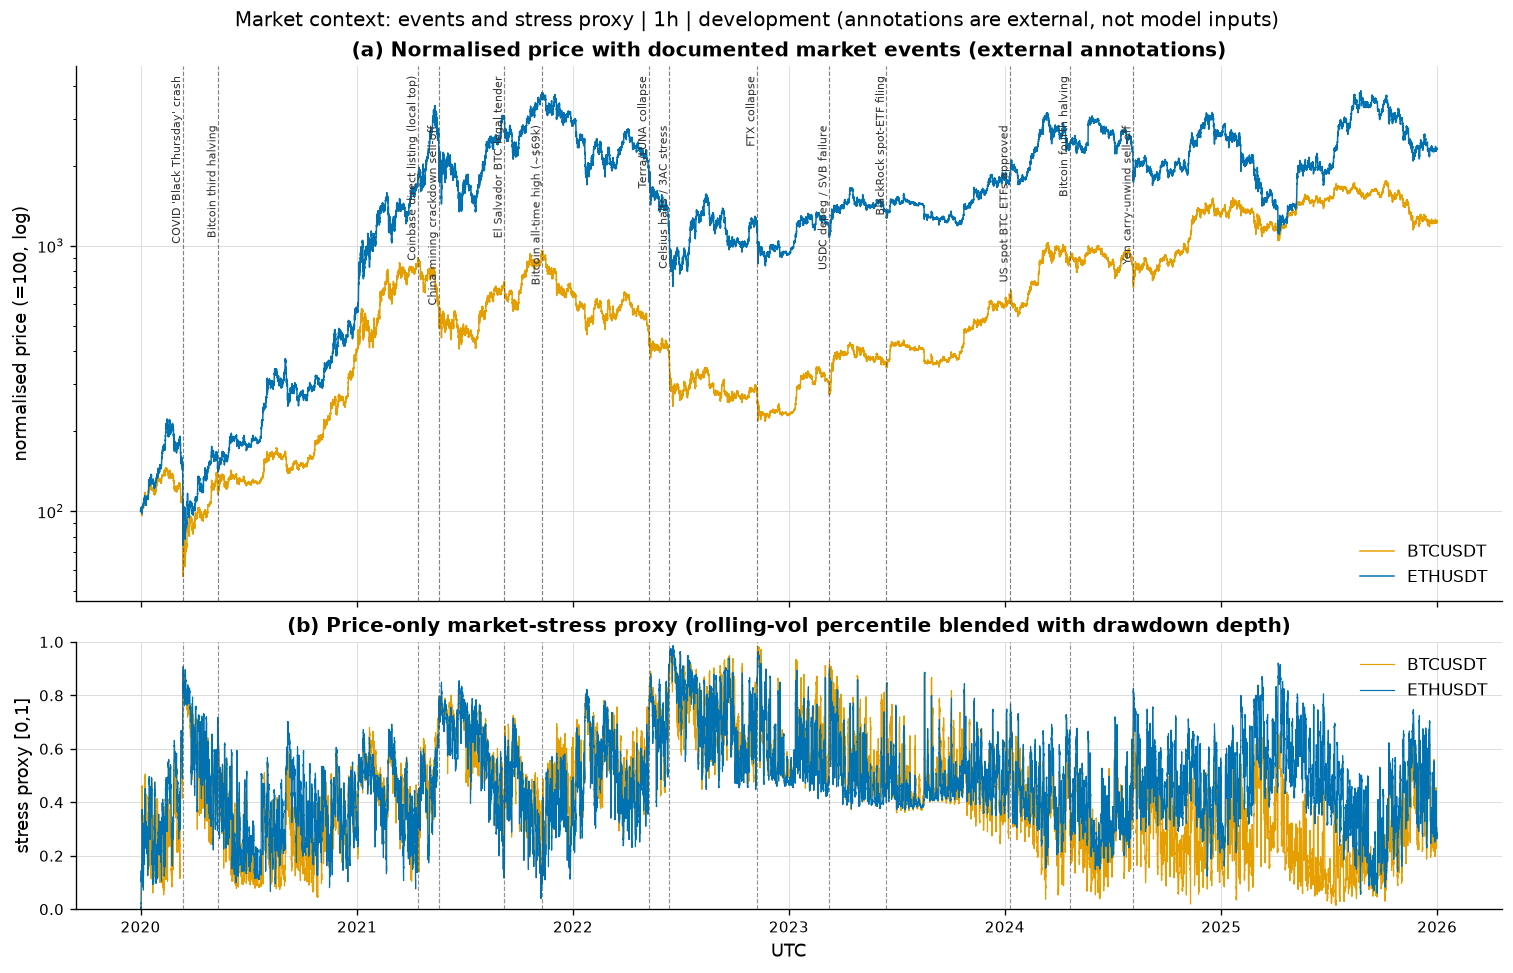

WindowsPath('reports/tables/eda/t12b_market_events.md')

In [14]:
# Market-context: documented events + price-only market-stress proxy (development only).
events = eda.market_events_frame(DEV_START, HOLDOUT_START)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12.5, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
axp = axes[0]
for sym, df in (("BTCUSDT", b1h), ("ETHUSDT", e1h)):
    d = df.filter(pl.col("open_time") >= t0).sort("open_time")
    axp.plot(
        d["open_time"].to_numpy(),
        100.0 * d["close"].to_numpy() / d["close"][0],
        color=asset_color(sym),
        lw=0.9,
        label=sym,
    )
axp.set_yscale("log")
axp.set_ylabel("normalised price (=100, log)")
axp.set_title("(a) Normalised price with documented market events (external annotations)")
ymin, ymax = axp.get_ylim()
for i, r in enumerate(events.iter_rows(named=True)):
    axp.axvline(r["date"], color="#4D4D4D", ls="--", lw=0.7, alpha=0.7)
    axp.text(
        r["date"],
        ymax * (0.92 if i % 2 == 0 else 0.60),
        r["label"],
        rotation=90,
        va="top",
        ha="right",
        fontsize=6.5,
        color="#333333",
    )
axp.legend(loc="lower right")

axs = axes[1]
for sym in SYMBOLS:
    si = eda.market_stress_index(RET[sym][PRIMARY_TF], vol_window=DAY_WINDOW[PRIMARY_TF])
    axs.plot(
        si["open_time"].to_numpy(),
        si["stress_index"].to_numpy(),
        color=asset_color(sym),
        lw=0.7,
        label=sym,
    )
for r in events.iter_rows(named=True):
    axs.axvline(r["date"], color="#4D4D4D", ls="--", lw=0.7, alpha=0.6)
axs.set_ylim(0, 1)
axs.set_ylabel("stress proxy [0,1]")
axs.set_xlabel("UTC")
axs.set_title(
    "(b) Price-only market-stress proxy (rolling-vol percentile blended with drawdown depth)"
)
axs.legend(loc="upper right")
fig.suptitle(
    "Market context: events and stress proxy | 1h | development (annotations are external, not model inputs)",
    fontsize=12,
)
show(
    fig,
    "f21_market_context_events",
    caption="Normalised price with widely documented event dates (external qualitative annotations) and a price-only market-stress proxy (1h, development). Neither the annotations nor the proxy are used to compute thresholds or features.",
)
save_table(
    events.with_columns(pl.col("date").cast(pl.Utf8)),
    "t12b_market_events",
    ctx,
    caption="Curated, publicly documented market events used only as external chart annotations (development window)",
)

**Interpretation (Section 5).** *What is observed:* both assets share the same broad cycles (the
2020-2021 expansion, the 2022 drawdown, the subsequent recovery); ETH is somewhat more volatile on
the normalised index; drawdowns reach tens of percent and last weeks to months; and the largest moves
in the stress proxy line up with well-known dated episodes (e.g. the 2020 COVID crash, the 2022
Terra/LUNA and FTX events). *Evidence:* figures f03-f04 and f21, table t11. *What cannot be
concluded:* the event overlay is descriptive context, not a causal attribution, and the stress proxy
is a price-derived indicator, not a sentiment measurement; these episodes are historical and do not
predict future cycles. *Decision:* the development period spans multiple regimes, a prerequisite for
chronological validation windows that must each cover several volatility cycles (Section 7).

## 6. Return distributions and tail risk

**Analytical question (RQ2, RQ3).** How are returns distributed, how does aggregation reshape them,
and how large is historical tail risk? **Method.** For each asset/timeframe we report full
distribution statistics (moments, robust dispersion, quantiles, Jarque-Bera) and historical
(non-parametric) VaR/Expected Shortfall in the **return-distribution and tail-risk summary (Summary
Table 3)**; we redesign the distribution figure to be readable (linear histogram with a normal
*reference*, ECDF, normal QQ and a survival-tail panel); and we rank extreme events with leak-free
pre-event context. **On extreme observations:** they are *never* winsorised or removed from any
statistic; histogram axes are clipped to robust quantiles for readability only, with the excluded
count reported. **On normality tests:** with hundreds of thousands of observations even negligible
departures are "significant", so we emphasise effect sizes (kurtosis, tail quantiles) over p-values.

In [15]:
# === SUMMARY TABLE 3: return-distribution and tail-risk statistics ===========
stat_rows = []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        r = RET[sym][tf]
        s = eda.return_stats(r, "log_return")
        if not s:
            continue
        vals = r.select("log_return").drop_nulls().to_series().to_numpy()
        q05, q25, q75, q95 = np.quantile(vals, [0.05, 0.25, 0.75, 0.95])
        iqr = float(q75 - q25)
        mad = float(np.median(np.abs(vals - np.median(vals))))
        jb = sstats.jarque_bera(vals)
        ann = eda.annualization_factor(tf, DAYS_PER_YEAR)
        vt = eda.tail_risk_table(r, "log_return", levels=(0.01, 0.05))
        var_es = {
            round(rec["level"] * 100): (rec["var"], rec["es"]) for rec in vt.iter_rows(named=True)
        }
        stat_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "n": int(s["n"]),
                "mean_bps": round(1e4 * s["mean"], 3),
                "median_bps": round(1e4 * s["median"], 3),
                "std_bps": round(1e4 * s["std"], 2),
                "ann_vol": round(s["std"] * ann, 3),
                "skew": round(s["skew"], 3),
                "exc_kurt": round(s["excess_kurtosis"], 1),
                "iqr_bps": round(1e4 * iqr, 2),
                "mad_bps": round(1e4 * mad, 2),
                "p01_bps": round(1e4 * s["p01"], 1),
                "p05_bps": round(1e4 * float(q05), 1),
                "p95_bps": round(1e4 * float(q95), 1),
                "p99_bps": round(1e4 * s["p99"], 1),
                "min_pct": round(100 * s["min"], 2),
                "max_pct": round(100 * s["max"], 2),
                "VaR5_pct": round(100 * var_es[5][0], 3),
                "ES5_pct": round(100 * var_es[5][1], 3),
                "VaR1_pct": round(100 * var_es[1][0], 3),
                "ES1_pct": round(100 * var_es[1][1], 3),
                "jb_stat": round(float(jb.statistic), 1),
                "jb_pvalue": float(jb.pvalue),
            }
        )
return_stats_tbl = pl.DataFrame(stat_rows)
with pl.Config(tbl_rows=20, tbl_width_chars=420):
    print(return_stats_tbl)
save_table(
    return_stats_tbl,
    "s3_return_tailrisk_statistics",
    ctx,
    caption="Summary Table 3 - log-return distribution and historical tail-risk statistics by asset/timeframe "
    "(development). std/quantiles in bps; ann_vol annualised with 365 days; VaR/ES are non-parametric.",
)

shape: (6, 23)
┌─────────┬───────────┬────────┬──────────┬───┬──────────┬─────────┬───────────┬───────────┐
│ symbol  ┆ timeframe ┆ n      ┆ mean_bps ┆ … ┆ VaR1_pct ┆ ES1_pct ┆ jb_stat   ┆ jb_pvalue │
│ ---     ┆ ---       ┆ ---    ┆ ---      ┆   ┆ ---      ┆ ---     ┆ ---       ┆ ---       │
│ str     ┆ str       ┆ i64    ┆ f64      ┆   ┆ f64      ┆ f64     ┆ f64       ┆ f64       │
╞═════════╪═══════════╪════════╪══════════╪═══╪══════════╪═════════╪═══════════╪═══════════╡
│ BTCUSDT ┆ 5m        ┆ 631295 ┆ 0.04     ┆ … ┆ -0.556   ┆ -0.897  ┆ 7.6614e8  ┆ 0.0       │
│ BTCUSDT ┆ 15m       ┆ 210431 ┆ 0.119    ┆ … ┆ -0.962   ┆ -1.527  ┆ 1.5223e8  ┆ 0.0       │
│ BTCUSDT ┆ 1h        ┆ 52607  ┆ 0.476    ┆ … ┆ -1.965   ┆ -3.01   ┆ 7164433.2 ┆ 0.0       │
│ ETHUSDT ┆ 5m        ┆ 631295 ┆ 0.05     ┆ … ┆ -0.724   ┆ -1.148  ┆ 9.3052e9  ┆ 0.0       │
│ ETHUSDT ┆ 15m       ┆ 210431 ┆ 0.149    ┆ … ┆ -1.258   ┆ -1.957  ┆ 4.1931e7  ┆ 0.0       │
│ ETHUSDT ┆ 1h        ┆ 52607  ┆ 0.597    ┆ … ┆ -2.547 

WindowsPath('reports/tables/eda/s3_return_tailrisk_statistics.md')

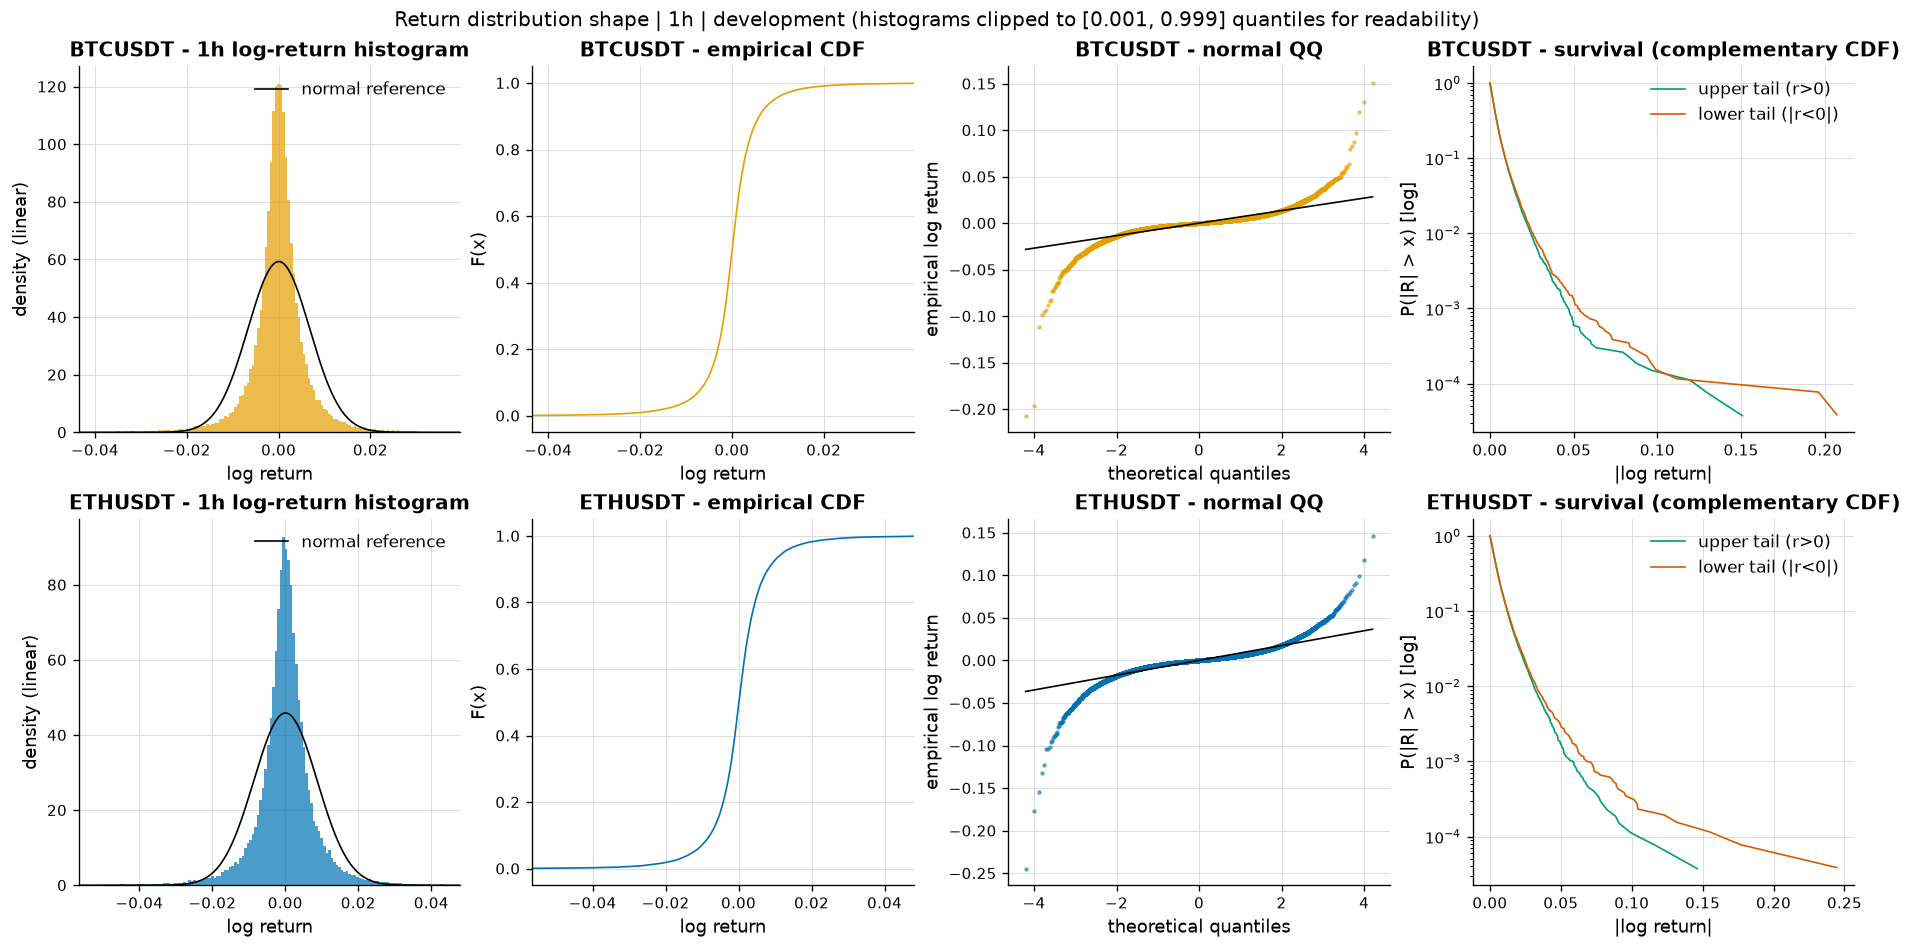

shape: (2, 7)
┌─────────┬───────────┬───────┬───────────┬────────────┬────────────────────┬──────────────┐
│ symbol  ┆ timeframe ┆ n     ┆ x_low_bps ┆ x_high_bps ┆ excluded_from_hist ┆ excluded_pct │
│ ---     ┆ ---       ┆ ---   ┆ ---       ┆ ---        ┆ ---                ┆ ---          │
│ str     ┆ str       ┆ i64   ┆ f64       ┆ f64        ┆ i64                ┆ f64          │
╞═════════╪═══════════╪═══════╪═══════════╪════════════╪════════════════════╪══════════════╡
│ BTCUSDT ┆ 1h        ┆ 52607 ┆ -435.2    ┆ 395.7      ┆ 106                ┆ 0.201        │
│ ETHUSDT ┆ 1h        ┆ 52607 ┆ -565.7    ┆ 479.4      ┆ 106                ┆ 0.201        │
└─────────┴───────────┴───────┴───────────┴────────────┴────────────────────┴──────────────┘


WindowsPath('reports/tables/eda/t13b_histogram_excluded.md')

In [16]:
# Readable distribution figure: linear histogram + normal reference, ECDF, normal QQ, survival tail.
DIST_TF = PRIMARY_TF
QLO, QHI = 0.001, 0.999
fig, axes = plt.subplots(len(SYMBOLS), 4, figsize=(15.5, 7.8), constrained_layout=True)
excl_rows = []
for i, sym in enumerate(SYMBOLS):
    vals = RET[sym][DIST_TF].select("log_return").drop_nulls().to_series().to_numpy()
    mu, sd = float(np.mean(vals)), float(np.std(vals, ddof=1))
    lo, hi = np.quantile(vals, [QLO, QHI])
    core = vals[(vals >= lo) & (vals <= hi)]
    n_excl = int(vals.size - core.size)
    excl_rows.append(
        {
            "symbol": sym,
            "timeframe": DIST_TF,
            "n": int(vals.size),
            "x_low_bps": round(1e4 * float(lo), 1),
            "x_high_bps": round(1e4 * float(hi), 1),
            "excluded_from_hist": n_excl,
            "excluded_pct": round(100 * n_excl / vals.size, 3),
        }
    )
    col = asset_color(sym)
    ax = axes[i, 0]
    ax.hist(core, bins=150, density=True, color=col, alpha=0.7)
    xs = np.linspace(lo, hi, 400)
    ax.plot(xs, sstats.norm.pdf(xs, mu, sd), color="black", lw=1.0, label="normal reference")
    ax.set_xlim(lo, hi)
    ax.set_title(f"{sym} - {DIST_TF} log-return histogram")
    ax.set_xlabel("log return")
    ax.set_ylabel("density (linear)")
    ax.legend()
    ax = axes[i, 1]
    xs_sorted = np.sort(vals)
    ax.plot(xs_sorted, np.arange(1, xs_sorted.size + 1) / xs_sorted.size, color=col, lw=1.0)
    ax.set_xlim(lo, hi)
    ax.set_title(f"{sym} - empirical CDF")
    ax.set_xlabel("log return")
    ax.set_ylabel("F(x)")
    ax = axes[i, 2]
    (osm, osr), _ = sstats.probplot(vals, dist="norm")
    ax.scatter(osm, osr, s=3, color=col, alpha=0.5)
    lim = [float(osm.min()), float(osm.max())]
    ax.plot(lim, [mu + sd * z for z in lim], color="black", lw=1.0)
    ax.set_title(f"{sym} - normal QQ")
    ax.set_xlabel("theoretical quantiles")
    ax.set_ylabel("empirical log return")
    ax = axes[i, 3]
    pos = np.sort(vals[vals > 0])[::-1]
    neg = np.sort(np.abs(vals[vals < 0]))[::-1]
    ax.plot(
        pos,
        np.arange(1, pos.size + 1) / pos.size,
        color="#009E73",
        lw=1.0,
        label="upper tail (r>0)",
    )
    ax.plot(
        neg,
        np.arange(1, neg.size + 1) / neg.size,
        color="#D55E00",
        lw=1.0,
        label="lower tail (|r<0|)",
    )
    ax.set_yscale("log")
    ax.set_title(f"{sym} - survival (complementary CDF)")
    ax.set_xlabel("|log return|")
    ax.set_ylabel("P(|R| > x) [log]")
    ax.legend()
fig.suptitle(
    f"Return distribution shape | {DIST_TF} | development (histograms clipped to [{QLO}, {QHI}] quantiles for readability)",
    fontsize=12,
)
show(
    fig,
    "f05_return_distribution_shape",
    caption="Linear histogram + normal reference, ECDF, normal QQ and survival tails of 1h log returns (development). "
    "Histogram x-limits are robust quantiles; the excluded-extremes count is reported in t13b. No observation is removed from any statistic.",
)
excluded_tbl = pl.DataFrame(excl_rows)
print(excluded_tbl)
save_table(
    excluded_tbl,
    "t13b_histogram_excluded",
    ctx,
    caption="Robust histogram limits and count of extreme observations excluded from the 1h histogram VIEW only (never from statistics)",
)

shape: (30, 9)
┌─────────┬───────────────────────────────┬─────────┬────────────┬───┬─────────────┬─────────────┬──────────────┬────────────────────────────┐
│ symbol  ┆ timestamp                     ┆ ret_pct ┆ absret_pct ┆ … ┆ pre_vol_bps ┆ funding_bps ┆ other_symbol ┆ other_simultaneous_extreme │
│ ---     ┆ ---                           ┆ ---     ┆ ---        ┆   ┆ ---         ┆ ---         ┆ ---          ┆ ---                        │
│ str     ┆ str                           ┆ f64     ┆ f64        ┆   ┆ f64         ┆ f64         ┆ str          ┆ bool                       │
╞═════════╪═══════════════════════════════╪═════════╪════════════╪═══╪═════════════╪═════════════╪══════════════╪════════════════════════════╡
│ BTCUSDT ┆ 2020-03-12 10:00:00.000+00:00 ┆ -20.71  ┆ 20.71      ┆ … ┆ 95.3        ┆ 1.0         ┆ ETHUSDT      ┆ true                       │
│ BTCUSDT ┆ 2020-03-12 23:00:00.000+00:00 ┆ -19.61  ┆ 19.61      ┆ … ┆ 436.8       ┆ -1.515      ┆ ETHUSDT      ┆ true         

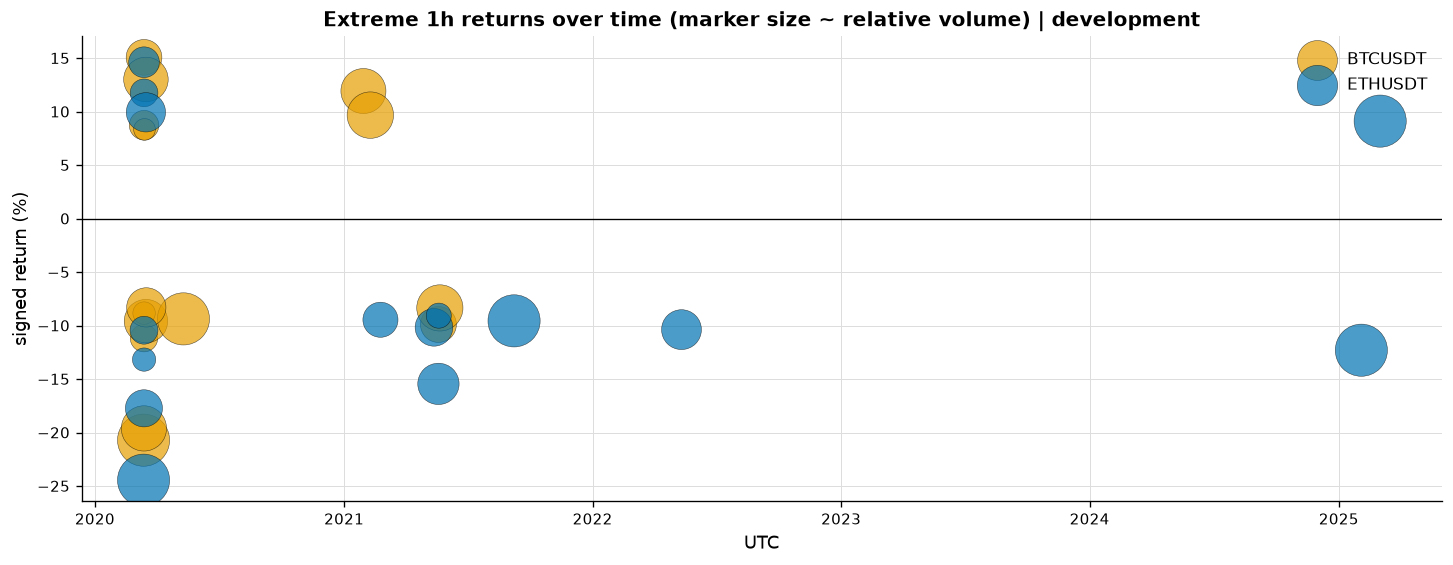

  BTCUSDT: 100% of its top-15 extreme bars coincided with an extreme bar in the other asset
  ETHUSDT: 93% of its top-15 extreme bars coincided with an extreme bar in the other asset


In [17]:
# Drawdown episode summary and extreme-event ranking with leak-free pre-event context (1h).
dd_summary_rows = []
for sym in SYMBOLS:
    for tf in (PRIMARY_TF, "5m"):
        eps = eda.drawdown_episodes(KL[sym][tf], min_depth=0.05)
        rec = eps.filter(pl.col("recovered"))
        step_h = TIMEFRAME_TO_MS[tf] / 3.6e6
        dd_summary_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "episodes_gt5pct": eps.height,
                "worst_depth_pct": round(100 * (eps["depth"].min() if eps.height else 0.0), 2),
                "median_recovery_days": round(
                    float(rec["recovery_bars"].median() or 0) * step_h / 24, 1
                )
                if rec.height
                else None,
                "underwater_fraction": round(eda.underwater_fraction(KL[sym][tf]), 3),
            }
        )
save_table(
    pl.DataFrame(dd_summary_rows),
    "t15_drawdown_summary",
    ctx,
    caption="Drawdown depth/recovery summary by asset/timeframe (development)",
)

EXT_TF, K_EXT = PRIMARY_TF, 15
ext_frames = []
for sym in SYMBOLS:
    other = "ETHUSDT" if sym == "BTCUSDT" else "BTCUSDT"
    ext_frames.append(
        eda.rank_extreme_events(
            RET[sym][EXT_TF],
            symbol=sym,
            other=RET[other][EXT_TF],
            other_symbol=other,
            funding=FUND[sym],
            k=K_EXT,
            vol_window=24,
        )
    )
extreme_events = pl.concat(ext_frames)
extreme_disp = extreme_events.with_columns(
    pl.col("timestamp").cast(pl.Utf8),
    (pl.col("log_return") * 100).round(2).alias("ret_pct"),
    (pl.col("abs_ret") * 100).round(2).alias("absret_pct"),
    pl.col("rel_volume").round(2),
    (pl.col("pre_vol") * 1e4).round(1).alias("pre_vol_bps"),
    (pl.col("funding_known") * 1e4).round(3).alias("funding_bps"),
).select(
    "symbol",
    "timestamp",
    "ret_pct",
    "absret_pct",
    "rel_volume",
    "pre_vol_bps",
    "funding_bps",
    "other_symbol",
    "other_simultaneous_extreme",
)
with pl.Config(tbl_rows=40, tbl_width_chars=260, fmt_str_lengths=30):
    print(extreme_disp)
save_table(
    extreme_disp,
    "t16_extreme_events",
    ctx,
    caption="Largest absolute 1h returns per asset with leak-free pre-event context (development). "
    "pre_vol_bps and funding_bps use only information known before the event.",
)

fig, ax = plt.subplots(figsize=(12, 4.6), constrained_layout=True)
for sym in SYMBOLS:
    ev = extreme_events.filter(pl.col("symbol") == sym)
    sizes = 20 + 120 * np.nan_to_num(ev["rel_volume"].to_numpy(), nan=1.0).clip(0, 8)
    ax.scatter(
        ev["timestamp"].to_numpy(),
        ev["log_return"].to_numpy() * 100,
        s=sizes,
        color=asset_color(sym),
        alpha=0.7,
        label=sym,
        edgecolors="black",
        linewidths=0.3,
    )
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Extreme 1h returns over time (marker size ~ relative volume) | development")
ax.set_xlabel("UTC")
ax.set_ylabel("signed return (%)")
ax.legend()
show(
    fig,
    "f07_extreme_event_timeline",
    caption="Timeline of the largest absolute 1h returns per asset; marker size scales with relative volume (development)",
)
for sym in SYMBOLS:
    rate = eda.coexceedance_rate(extreme_events.filter(pl.col("symbol") == sym))
    print(
        f"  {sym}: {100 * rate:.0f}% of its top-{K_EXT} extreme bars coincided with an extreme bar in the other asset"
    )

**Interpretation (RQ2, RQ3).** *What is observed:* returns are near-zero-mean and strongly
**leptokurtic** at all timeframes; the QQ plots bend away from the normal line in both tails and the
survival panel shows far heavier tails than a Gaussian, with the lower tail at least as heavy as the
upper. Excess kurtosis falls monotonically from 5m to 1h while per-bar volatility rises. Historical
5% Expected Shortfall is several times the standard deviation, and the largest 1h moves cluster in
known stress episodes and frequently coincide across the two assets. *Evidence:* Summary Table 3,
tables t13b/t15/t16 and figures f05, f07. *What cannot be concluded:* these are unconditional,
in-sample descriptive estimates that mix regimes and are not forecasts. *Decision:* risk management
must be tail-aware (historical VaR/ES, not Gaussian) with volatility-scaled sizing; heavy tails argue
for robust/rank-based features; the kurtosis-timeframe trade-off feeds timeframe selection (Section 11).

## 7. Volatility and temporal dependence

**Analytical question (RQ4, RQ5).** Is volatility persistent and clustered, are returns stationary,
and is there dependence in return *direction* versus *magnitude*? **Method.** On the 1h series we
compute annualised rolling close-to-close volatility over clock-consistent windows plus OHLC
estimators (Parkinson, Garman-Klass); we assemble the **stationarity and temporal-dependence
diagnostics (Summary Table 4)** (ADF, KPSS, Ljung-Box on raw and squared returns, ARCH-LM); we track
rolling distribution moments; and we estimate the ACF of raw/absolute/squared returns. We stress
**effect size over p-values** given the very large samples, and we distinguish *price levels*,
*returns* and *volatility proxies* throughout.

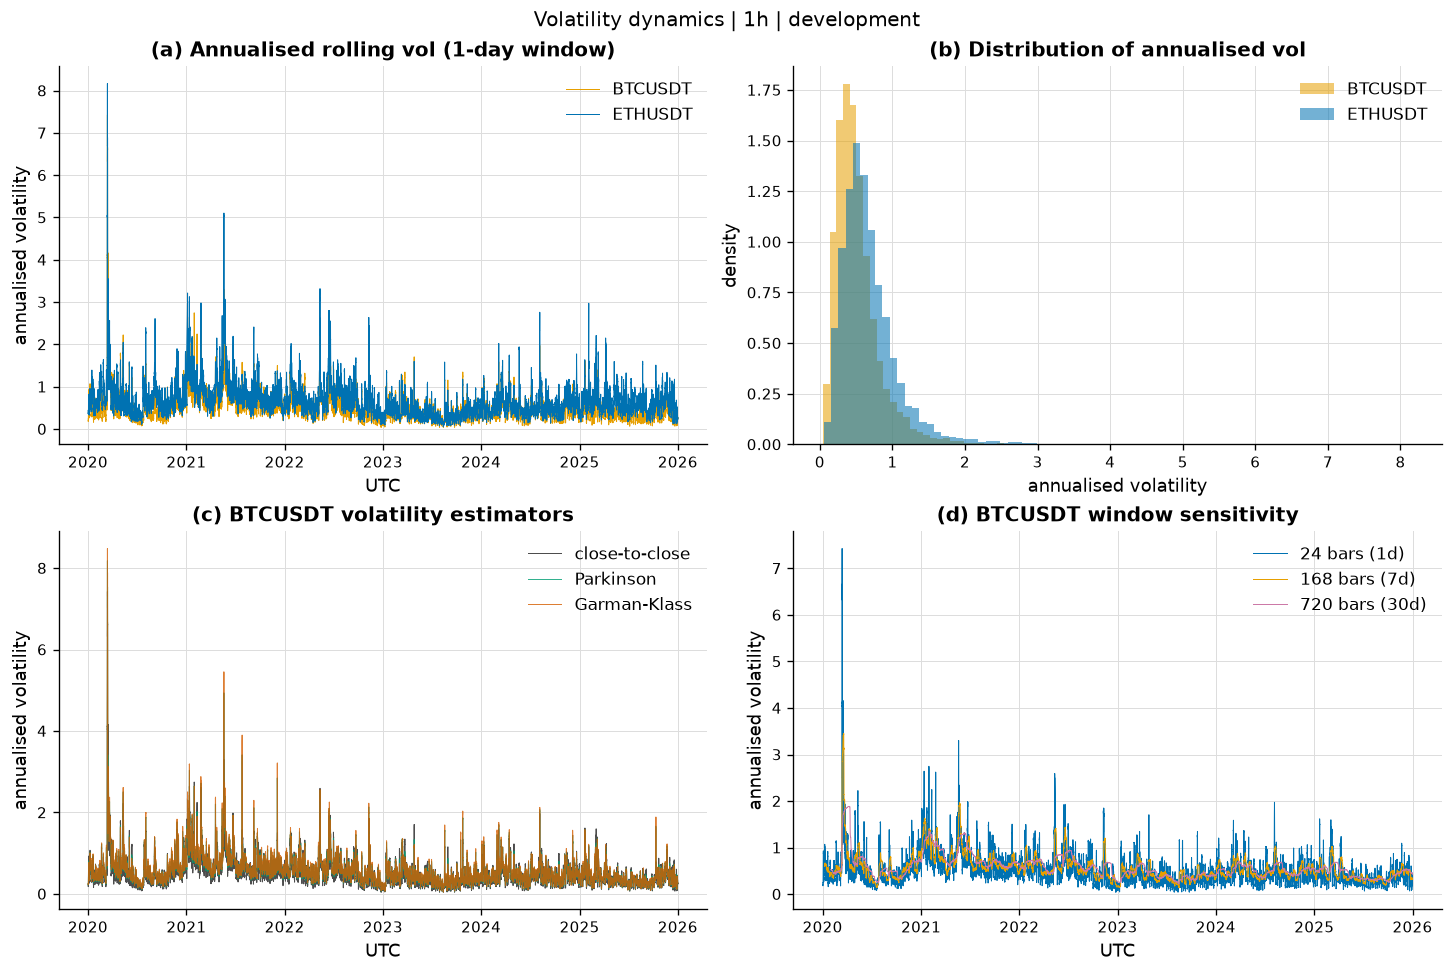

WindowsPath('reports/tables/eda/t17_volatility_summary.md')

In [18]:
# Volatility over time, distribution, estimators and window sensitivity (1h).
VOL_TF, DAY_W = PRIMARY_TF, 24
factor_1h = eda.annualization_factor(VOL_TF, DAYS_PER_YEAR)
vol_series = {
    sym: eda.annualized_volatility(RET[sym][VOL_TF], VOL_TF, DAY_W, days_per_year=DAYS_PER_YEAR)
    for sym in SYMBOLS
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax = axes[0, 0]
for sym in SYMBOLS:
    d = vol_series[sym]
    ax.plot(
        d["open_time"].to_numpy(),
        d[f"ann_vol_{DAY_W}"].to_numpy(),
        color=asset_color(sym),
        lw=0.6,
        label=sym,
    )
ax.set_title("(a) Annualised rolling vol (1-day window)")
ax.set_xlabel("UTC")
ax.set_ylabel("annualised volatility")
ax.legend()
ax = axes[0, 1]
for sym in SYMBOLS:
    v = vol_series[sym][f"ann_vol_{DAY_W}"].drop_nulls().to_numpy()
    ax.hist(v, bins=80, density=True, color=asset_color(sym), alpha=0.55, label=sym)
ax.set_title("(b) Distribution of annualised vol")
ax.set_xlabel("annualised volatility")
ax.set_ylabel("density")
ax.legend()
ax = axes[1, 0]
base = RET["BTCUSDT"][VOL_TF]
c2c = eda.annualized_volatility(base, VOL_TF, DAY_W, days_per_year=DAYS_PER_YEAR)[
    f"ann_vol_{DAY_W}"
].to_numpy()
pk = eda.parkinson_volatility(base, DAY_W)[f"parkinson_vol_{DAY_W}"].to_numpy() * factor_1h
gk = eda.garman_klass_volatility(base, DAY_W)[f"garman_klass_vol_{DAY_W}"].to_numpy() * factor_1h
t = base["open_time"].to_numpy()
ax.plot(t, c2c, color="#4D4D4D", lw=0.6, label="close-to-close")
ax.plot(t, pk, color="#009E73", lw=0.6, label="Parkinson", alpha=0.8)
ax.plot(t, gk, color="#D55E00", lw=0.6, label="Garman-Klass", alpha=0.8)
ax.set_title("(c) BTCUSDT volatility estimators")
ax.set_xlabel("UTC")
ax.set_ylabel("annualised volatility")
ax.legend()
ax = axes[1, 1]
for w, cc in ((24, "#0072B2"), (168, "#E69F00"), (720, "#CC79A7")):
    s = eda.annualized_volatility(base, VOL_TF, w, days_per_year=DAYS_PER_YEAR)[
        f"ann_vol_{w}"
    ].to_numpy()
    ax.plot(t, s, lw=0.6, color=cc, label=f"{w} bars ({w // 24}d)")
ax.set_title("(d) BTCUSDT window sensitivity")
ax.set_xlabel("UTC")
ax.set_ylabel("annualised volatility")
ax.legend()
fig.suptitle(f"Volatility dynamics | {VOL_TF} | development", fontsize=12)
show(
    fig,
    "f08_volatility_dynamics",
    caption="Rolling vol, distribution, estimator comparison and window sensitivity (1h, development)",
)

vol_summary_rows = []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        w = DAY_WINDOW[tf]
        d = eda.annualized_volatility(RET[sym][tf], tf, w, days_per_year=DAYS_PER_YEAR)
        s = d[f"ann_vol_{w}"].drop_nulls().to_numpy()
        acf1 = float(np.corrcoef(s[1:], s[:-1])[0, 1]) if s.size > 2 else float("nan")
        vol_summary_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "window_1day_bars": w,
                "mean_ann_vol": round(float(np.mean(s)), 3),
                "median_ann_vol": round(float(np.median(s)), 3),
                "vol_of_vol": round(float(np.std(s) / np.mean(s)), 3),
                "p05_ann_vol": round(float(np.quantile(s, 0.05)), 3),
                "p95_ann_vol": round(float(np.quantile(s, 0.95)), 3),
                "persistence_acf1": round(acf1, 3),
            }
        )
save_table(
    pl.DataFrame(vol_summary_rows),
    "t17_volatility_summary",
    ctx,
    caption="Annualised volatility summary and lag-1 persistence (1-day clock window) by asset/timeframe (development)",
)

In [19]:
# === SUMMARY TABLE 4: stationarity and temporal-dependence diagnostics =======
stationarity = pl.concat(
    [eda.stationarity_report(RET[sym][PRIMARY_TF], symbol=sym) for sym in SYMBOLS]
)
with pl.Config(tbl_rows=20, tbl_width_chars=260):
    print(stationarity)
save_table(
    stationarity,
    "s4_stationarity_dependence",
    ctx,
    caption="Summary Table 4 - ADF/KPSS on log price and log returns, Ljung-Box on raw and squared returns, "
    "ARCH-LM (BTC/ETH, 1h, development). Tests are low-powered under structural breaks; statistical "
    "significance is NOT economic exploitability.",
)

shape: (14, 6)
┌─────────┬─────────────────┬────────────────┬──────────────┬────────────┬────────────────────────────┐
│ symbol  ┆ test            ┆ series         ┆ statistic    ┆ pvalue     ┆ null                       │
│ ---     ┆ ---             ┆ ---            ┆ ---          ┆ ---        ┆ ---                        │
│ str     ┆ str             ┆ str            ┆ f64          ┆ f64        ┆ str                        │
╞═════════╪═════════════════╪════════════════╪══════════════╪════════════╪════════════════════════════╡
│ BTCUSDT ┆ ADF             ┆ log_price      ┆ -1.786048    ┆ 0.38741    ┆ unit root (non-stationary) │
│ BTCUSDT ┆ ADF             ┆ log_return     ┆ -31.948827   ┆ 0.0        ┆ unit root (non-stationary) │
│ BTCUSDT ┆ KPSS            ┆ log_price      ┆ 22.948879    ┆ 0.01       ┆ stationary                 │
│ BTCUSDT ┆ KPSS            ┆ log_return     ┆ 0.162274     ┆ 0.1        ┆ stationary                 │
│ BTCUSDT ┆ Ljung-Box(l=20) ┆ log_return     ┆ 12

WindowsPath('reports/tables/eda/s4_stationarity_dependence.md')

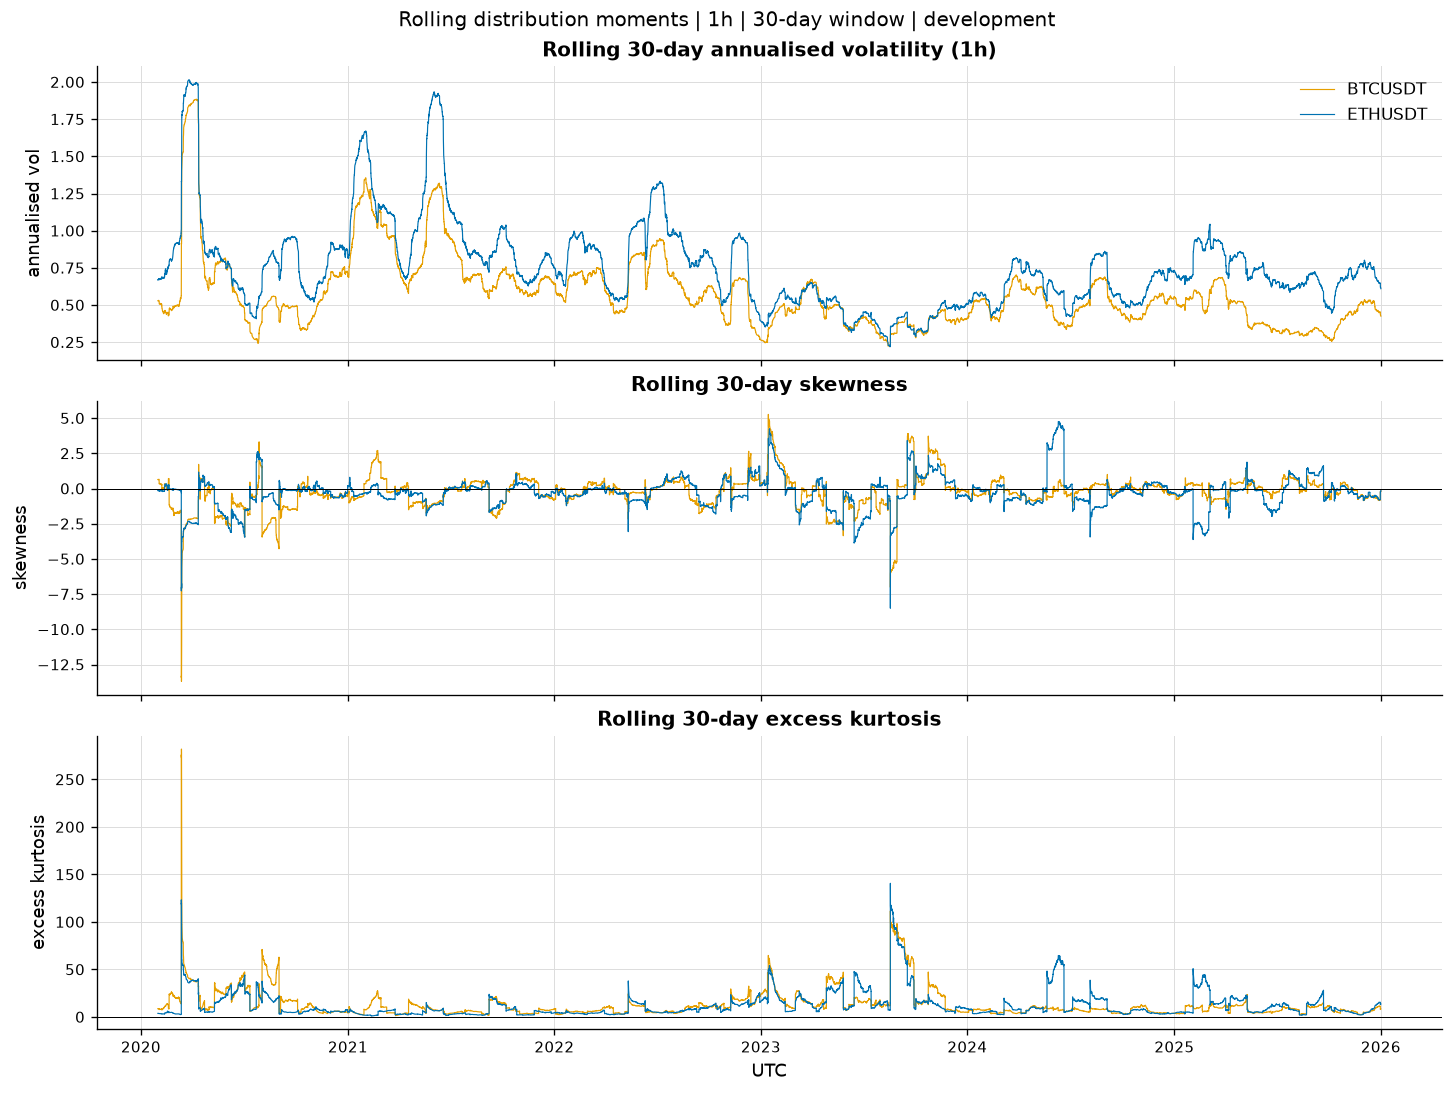

WindowsPath('reports/tables/eda/t19_rolling_moments_by_year.md')

In [20]:
# Rolling distribution moments (annualised vol, skewness, excess kurtosis) - 1h, configurable window.
RM_TF = PRIMARY_TF
WIN_DAYS = EDA_CFG.rolling_moment_window_days
WIN_BARS = WIN_DAYS * DAY_WINDOW[RM_TF]
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
for sym in SYMBOLS:
    rm = eda.rolling_moments(
        RET[sym][RM_TF], WIN_BARS, timeframe=RM_TF, days_per_year=DAYS_PER_YEAR
    )
    tt = rm["open_time"].to_numpy()
    axes[0].plot(tt, rm["rolling_vol"].to_numpy(), color=asset_color(sym), lw=0.7, label=sym)
    axes[1].plot(tt, rm["rolling_skew"].to_numpy(), color=asset_color(sym), lw=0.7, label=sym)
    axes[2].plot(tt, rm["rolling_kurt"].to_numpy(), color=asset_color(sym), lw=0.7, label=sym)
axes[0].set_title(f"Rolling {WIN_DAYS}-day annualised volatility (1h)")
axes[0].set_ylabel("annualised vol")
axes[0].legend()
axes[1].set_title(f"Rolling {WIN_DAYS}-day skewness")
axes[1].set_ylabel("skewness")
axes[1].axhline(0, color="black", lw=0.6)
axes[2].set_title(f"Rolling {WIN_DAYS}-day excess kurtosis")
axes[2].set_ylabel("excess kurtosis")
axes[2].axhline(0, color="black", lw=0.6)
axes[2].set_xlabel("UTC")
fig.suptitle(
    f"Rolling distribution moments | {RM_TF} | {WIN_DAYS}-day window | development", fontsize=12
)
show(
    fig,
    "f09_rolling_moments",
    caption=f"Rolling {WIN_DAYS}-day annualised volatility, skewness and excess kurtosis (1h, development); demonstrates distributional instability.",
)

by_year_rows = []
for sym in SYMBOLS:
    r1h = RET[sym][PRIMARY_TF].with_columns(pl.col("open_time").dt.year().alias("year"))
    for y in sorted(r1h["year"].unique().to_list()):
        s = eda.return_stats(r1h.filter(pl.col("year") == y), "log_return")
        if not s:
            continue
        by_year_rows.append(
            {
                "symbol": sym,
                "year": int(y),
                "n": int(s["n"]),
                "ann_vol": round(s["std"] * factor_1h, 3),
                "skew": round(s["skew"], 3),
                "exc_kurt": round(s["excess_kurtosis"], 1),
            }
        )
save_table(
    pl.DataFrame(by_year_rows),
    "t19_rolling_moments_by_year",
    ctx,
    caption="Annualised volatility, skewness and excess kurtosis by calendar year (1h, development)",
)

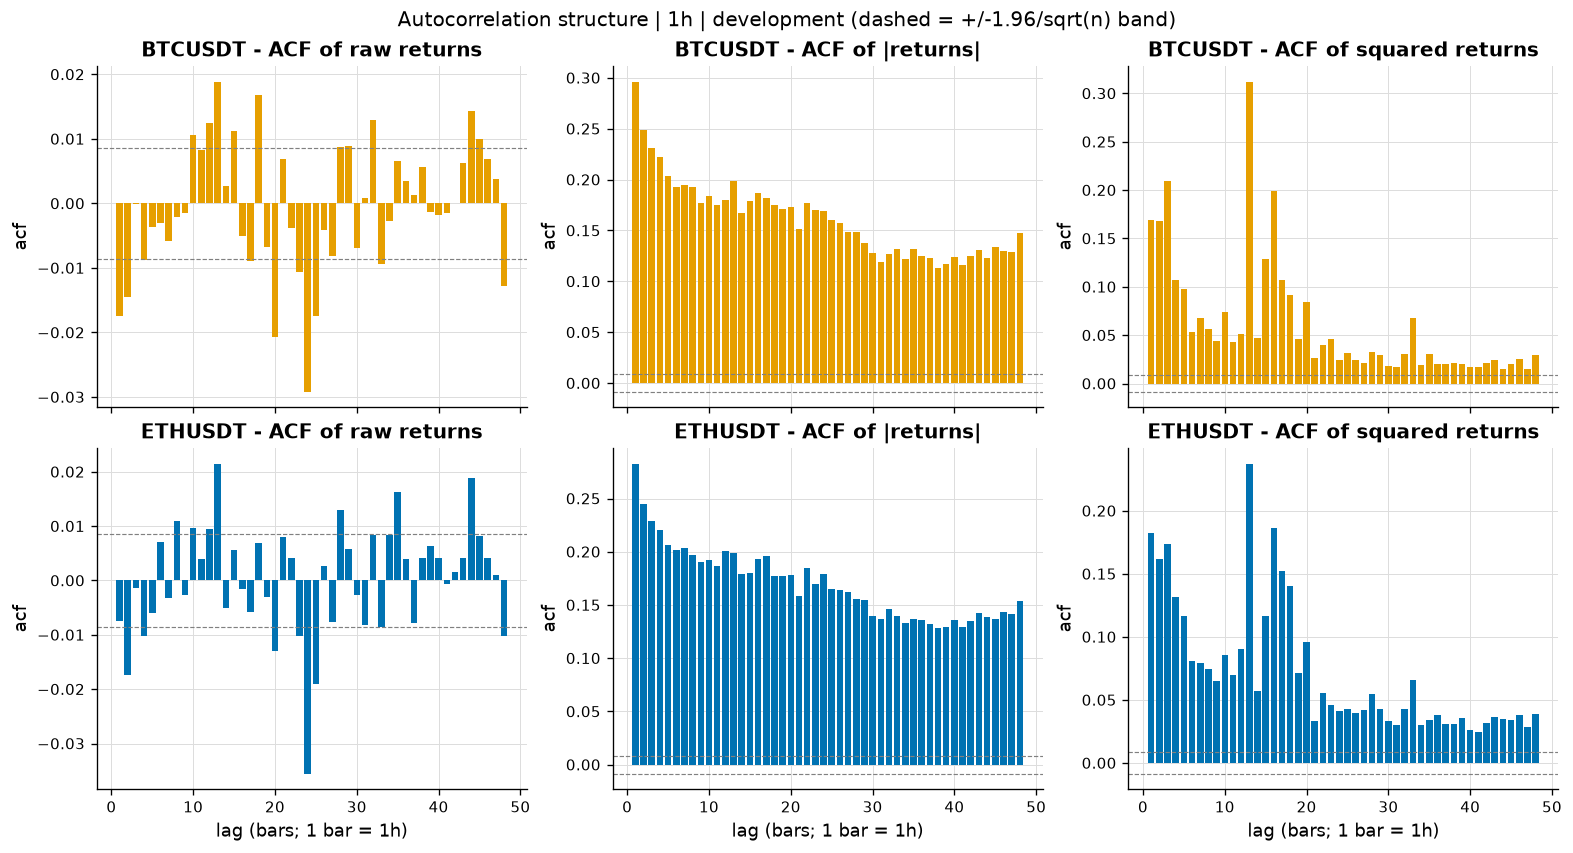

Lag reference: 48 bars at 1h = 48 hours; 24 bars = 1 day.


In [21]:
# ACF of raw/absolute/squared returns + Ljung-Box (1h).
ACF_TF, MAX_LAG = PRIMARY_TF, 48
fig, axes = plt.subplots(len(SYMBOLS), 3, figsize=(13, 7), constrained_layout=True, sharex=True)
lb_rows = []
transforms = [("identity", "raw returns"), ("abs", "|returns|"), ("square", "squared returns")]
for i, sym in enumerate(SYMBOLS):
    r = RET[sym][ACF_TF]
    n = r.select(pl.col("log_return")).drop_nulls().height
    conf = 1.96 / np.sqrt(n)
    for j, (tr, label) in enumerate(transforms):
        ac = eda.autocorrelation(r, "log_return", max_lag=MAX_LAG, transform=tr)
        lags = ac["lag"].to_numpy()[1:]
        vals = ac["acf"].to_numpy()[1:]
        ax = axes[i, j]
        ax.bar(lags, vals, color=asset_color(sym), width=0.8)
        ax.axhline(conf, color="grey", ls="--", lw=0.7)
        ax.axhline(-conf, color="grey", ls="--", lw=0.7)
        ax.set_title(f"{sym} - ACF of {label}")
        if i == len(SYMBOLS) - 1:
            ax.set_xlabel(f"lag (bars; 1 bar = {ACF_TF})")
        ax.set_ylabel("acf")
        lb_rows.append(
            {
                "symbol": sym,
                "series": label,
                "timeframe": ACF_TF,
                "acf_lag1": round(float(vals[0]), 4),
                "ljung_box_p_lag24": eda.ljung_box_pvalue(r, "log_return", lags=24, transform=tr),
            }
        )
fig.suptitle(
    f"Autocorrelation structure | {ACF_TF} | development (dashed = +/-1.96/sqrt(n) band)",
    fontsize=12,
)
show(
    fig,
    "f10_autocorrelation",
    caption="ACF of raw/absolute/squared 1h returns with white-noise band (development)",
)
save_table(
    pl.DataFrame(lb_rows),
    "t20_dependence",
    ctx,
    caption="Lag-1 ACF and Ljung-Box p-values (lag 24) for raw/abs/squared returns (1h, development)",
)
print(f"Lag reference: {MAX_LAG} bars at {ACF_TF} = {MAX_LAG} hours; 24 bars = 1 day.")

**Interpretation (RQ4, RQ5).** *What is observed:* volatility is strongly clustered and persistent
(high lag-1 autocorrelation of the rolling-vol series; ARCH-LM overwhelmingly rejects no ARCH;
Ljung-Box on squared returns rejects strongly), and the rolling-moment panels show volatility,
skewness and kurtosis all drifting over time (distributional instability). ADF rejects a unit root in
log *returns* while KPSS does not reject stationarity of returns; log *price* behaves like a unit-root
process, as expected. The ACF of *raw* returns is economically negligible, whereas the ACF of
*absolute/squared* returns is clearly positive and slowly decaying. *Evidence:* Summary Table 4,
tables t17/t19/t20 and figures f08-f10. *What cannot be concluded:* these are linear, unconditional
diagnostics under likely structural breaks; a significant statistic is not a tradable edge, and
stationarity tests do not prove stable behaviour. *Decision:* do not presume linear return
predictability; exploit volatility persistence (vol-scaling, vol-state features, regimes) and size
chronological validation windows to span several volatility cycles.

## 8. Market activity, order flow and seasonality

**Analytical question (RQ6, parts 1-2).** Do volume, order flow and liquidity proxies relate to
risk, and are there stable UTC intraday / weekly patterns? **Method.** We avoid comparing raw BTC vs
ETH base volume (different units) and instead compute dollar volume, relative volume, normalised
high-low range, ATR/price, an Amihud-style illiquidity proxy, the zero-return-bar share and the
taker-buy ratio. We relate relative activity to absolute returns and to rolling annualised volatility
with Spearman correlations (reporting sample sizes); we add a dedicated **taker-buy order-flow
imbalance** analysis; and we study seasonality with normalised measures, uncertainty bands,
per-group counts and a Kruskal-Wallis omnibus test. These are **liquidity/activity proxies**: OHLCV
data do not expose the order book.

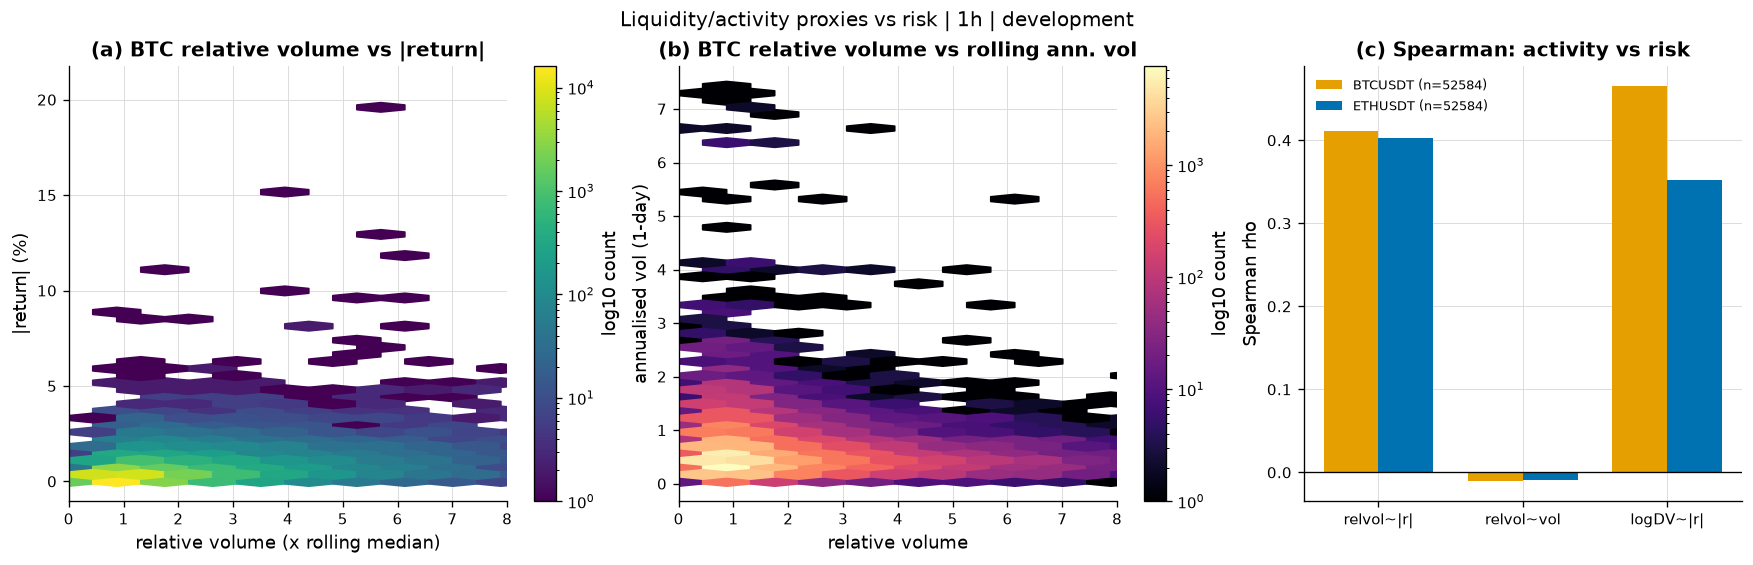

WindowsPath('reports/tables/eda/t22_liquidity_risk_spearman.md')

In [22]:
# Liquidity/activity proxy summary (median-based) per asset x timeframe.
liq_rows = [
    eda.liquidity_summary(RET[sym][tf], symbol=sym, timeframe=tf)
    for sym in SYMBOLS
    for tf in ("5m", PRIMARY_TF)
]
save_table(
    pl.DataFrame(liq_rows),
    "t21_liquidity_summary",
    ctx,
    caption="Liquidity/activity proxies (median dollar volume, HL range, ATR/price, Amihud, taker-buy ratio, zero-return %) by asset/timeframe (development)",
)

# Relative activity vs |return| and vs rolling annualised volatility (Spearman, with sample sizes).
LQ_TF, LQ_W = PRIMARY_TF, 24
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.6), constrained_layout=True)
enr = {}
for sym in SYMBOLS:
    e = eda.add_liquidity_proxies(RET[sym][LQ_TF], window=LQ_W)
    av = eda.annualized_volatility(RET[sym][LQ_TF], LQ_TF, LQ_W, days_per_year=DAYS_PER_YEAR)
    e = e.join(
        av.select("open_time", pl.col(f"ann_vol_{LQ_W}").alias("ann_vol")),
        on="open_time",
        how="left",
    )
    enr[sym] = e.drop_nulls(subset=["rel_volume", "log_return", "ann_vol"]).with_columns(
        pl.col("log_return").abs().alias("abs_ret")
    )
bt = enr["BTCUSDT"]
hb = axes[0].hexbin(
    bt["rel_volume"].to_numpy(),
    bt["abs_ret"].to_numpy() * 100,
    gridsize=50,
    bins="log",
    cmap="viridis",
)
axes[0].set_title("(a) BTC relative volume vs |return|")
axes[0].set_xlabel("relative volume (x rolling median)")
axes[0].set_ylabel("|return| (%)")
axes[0].set_xlim(0, 8)
fig.colorbar(hb, ax=axes[0], label="log10 count")
hb2 = axes[1].hexbin(
    bt["rel_volume"].to_numpy(), bt["ann_vol"].to_numpy(), gridsize=50, bins="log", cmap="magma"
)
axes[1].set_title("(b) BTC relative volume vs rolling ann. vol")
axes[1].set_xlabel("relative volume")
axes[1].set_ylabel("annualised vol (1-day)")
axes[1].set_xlim(0, 8)
fig.colorbar(hb2, ax=axes[1], label="log10 count")
spear_rows = []
labels = ["relvol~|r|", "relvol~vol", "logDV~|r|"]
x = np.arange(len(labels))
width = 0.38
for k, sym in enumerate(SYMBOLS):
    e = enr[sym]
    r1 = float(sstats.spearmanr(e["rel_volume"].to_numpy(), e["abs_ret"].to_numpy()).correlation)
    r2 = float(sstats.spearmanr(e["rel_volume"].to_numpy(), e["ann_vol"].to_numpy()).correlation)
    r3 = float(
        sstats.spearmanr(e["log_dollar_volume"].to_numpy(), e["abs_ret"].to_numpy()).correlation
    )
    axes[2].bar(
        x + (k - 0.5) * width,
        [r1, r2, r3],
        width,
        color=asset_color(sym),
        label=f"{sym} (n={e.height})",
    )
    spear_rows.append(
        {
            "symbol": sym,
            "n": e.height,
            "spearman_relvol_absret": round(r1, 3),
            "spearman_relvol_annvol": round(r2, 3),
            "spearman_logdollarvol_absret": round(r3, 3),
        }
    )
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_xticks(x, labels)
axes[2].set_title("(c) Spearman: activity vs risk")
axes[2].set_ylabel("Spearman rho")
axes[2].legend(fontsize=8)
fig.suptitle(f"Liquidity/activity proxies vs risk | {LQ_TF} | development", fontsize=12)
show(
    fig,
    "f11_liquidity_activity_risk",
    caption="Relative activity vs absolute return and vs rolling annualised volatility (1h, development); panel (c) Spearman correlations with sample sizes.",
)
save_table(
    pl.DataFrame(spear_rows),
    "t22_liquidity_risk_spearman",
    ctx,
    caption="Spearman correlations of relative activity with absolute return and with rolling annualised volatility, with sample sizes (1h, development)",
)

In [23]:
# Contemporaneous vs one-lag activity-risk correlations (volume, trade count).
act_rows = []
for sym in SYMBOLS:
    for tf in TIMEFRAMES:
        r = RET[sym][tf].drop_nulls(subset=["log_return"]).sort("open_time")
        vol = r["volume"].to_numpy()
        tc = r["trade_count"].to_numpy().astype(float)
        absr = np.abs(r["log_return"].to_numpy())
        act_rows.append(
            {
                "symbol": sym,
                "timeframe": tf,
                "spearman_vol_absret_t": round(float(sstats.spearmanr(vol, absr).correlation), 3),
                "spearman_trades_absret_t": round(float(sstats.spearmanr(tc, absr).correlation), 3),
                "spearman_vol_t_absret_t+1": round(
                    float(sstats.spearmanr(vol[:-1], absr[1:]).correlation), 3
                ),
            }
        )
save_table(
    pl.DataFrame(act_rows),
    "t23_activity_correlations",
    ctx,
    caption="Spearman correlations of volume/trades with |return| (contemporaneous and one-lag), by asset/timeframe (development)",
)

WindowsPath('reports/tables/eda/t23_activity_correlations.md')

shape: (2, 9)
┌─────────┬───────────┬───────┬──────────────────┬───┬───────────────┬───────────────┬──────────┬──────────────────────┐
│ symbol  ┆ timeframe ┆ n     ┆ median_imbalance ┆ … ┆ std_imbalance ┆ share_net_buy ┆ acf_lag1 ┆ spearman_with_return │
│ ---     ┆ ---       ┆ ---   ┆ ---              ┆   ┆ ---           ┆ ---           ┆ ---      ┆ ---                  │
│ str     ┆ str       ┆ i64   ┆ f64              ┆   ┆ f64           ┆ f64           ┆ f64      ┆ f64                  │
╞═════════╪═══════════╪═══════╪══════════════════╪═══╪═══════════════╪═══════════════╪══════════╪══════════════════════╡
│ BTCUSDT ┆ 1h        ┆ 52607 ┆ -0.0056          ┆ … ┆ 0.0879        ┆ 0.4735        ┆ 0.0195   ┆ 0.6763               │
│ ETHUSDT ┆ 1h        ┆ 52607 ┆ -0.0094          ┆ … ┆ 0.0855        ┆ 0.4539        ┆ 0.0108   ┆ 0.6719               │
└─────────┴───────────┴───────┴──────────────────┴───┴───────────────┴───────────────┴──────────┴──────────────────────┘


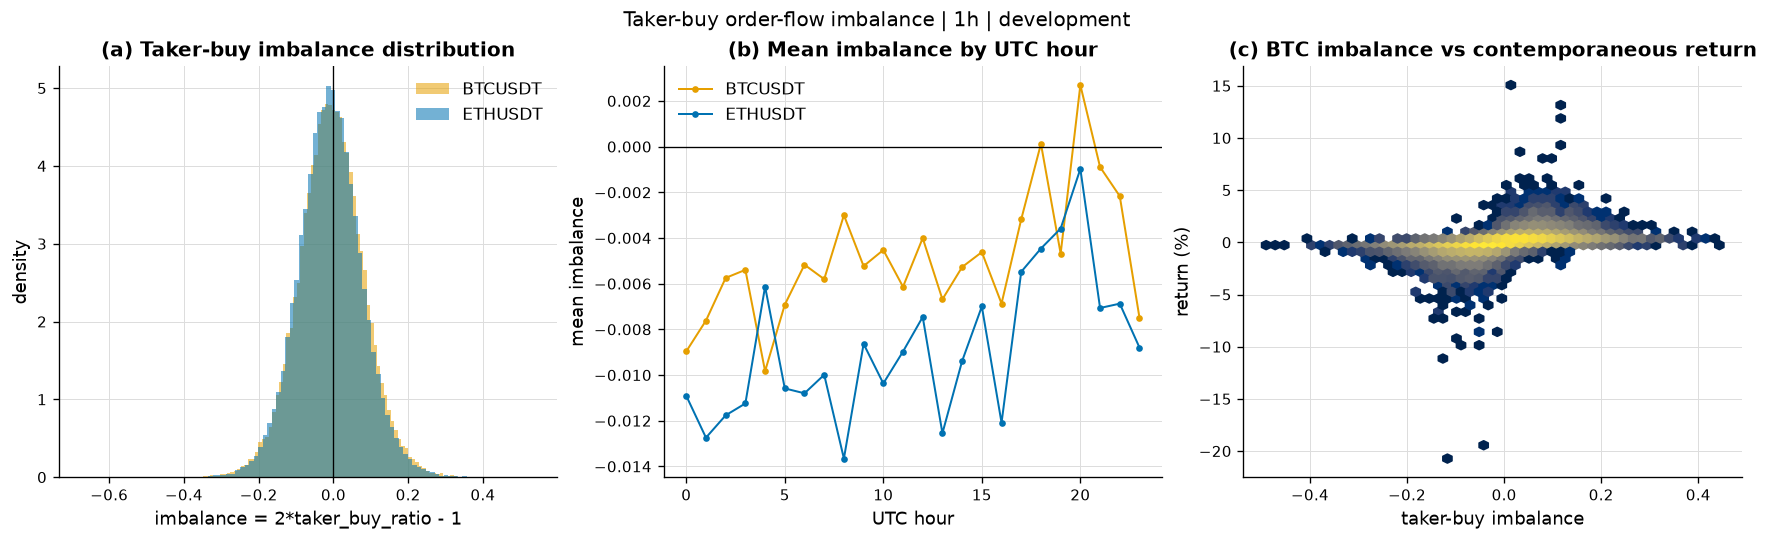

In [24]:
# Taker-buy order-flow imbalance: distribution, seasonality, and return co-movement (NEW).
OF_TF = PRIMARY_TF
of = {sym: eda.add_order_flow_imbalance(RET[sym][OF_TF]) for sym in SYMBOLS}
of_summary = pl.DataFrame(
    [eda.order_flow_summary(RET[sym][OF_TF], symbol=sym, timeframe=OF_TF) for sym in SYMBOLS]
)
with pl.Config(tbl_width_chars=240):
    print(of_summary)
save_table(
    of_summary,
    "t23b_order_flow_summary",
    ctx,
    caption="Taker-buy imbalance distribution, persistence and (descriptive) return co-movement (1h, development). "
    "Not evidence of predictive power.",
)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)
for sym in SYMBOLS:
    imb = of[sym].select("taker_buy_imbalance").drop_nulls().to_series().to_numpy()
    axes[0].hist(imb, bins=100, density=True, color=asset_color(sym), alpha=0.55, label=sym)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("(a) Taker-buy imbalance distribution")
axes[0].set_xlabel("imbalance = 2*taker_buy_ratio - 1")
axes[0].set_ylabel("density")
axes[0].legend()
for sym in SYMBOLS:
    h = (
        of[sym]
        .with_columns(pl.col("open_time").dt.hour().alias("hour"))
        .group_by("hour")
        .agg(pl.col("taker_buy_imbalance").mean().alias("m"))
        .sort("hour")
    )
    axes[1].plot(
        h["hour"].to_numpy(), h["m"].to_numpy(), marker="o", ms=3, color=asset_color(sym), label=sym
    )
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("(b) Mean imbalance by UTC hour")
axes[1].set_xlabel("UTC hour")
axes[1].set_ylabel("mean imbalance")
axes[1].legend()
bti = of["BTCUSDT"].drop_nulls(subset=["taker_buy_imbalance", "log_return"])
axes[2].hexbin(
    bti["taker_buy_imbalance"].to_numpy(),
    bti["log_return"].to_numpy() * 100,
    gridsize=50,
    bins="log",
    cmap="cividis",
)
axes[2].set_title("(c) BTC imbalance vs contemporaneous return")
axes[2].set_xlabel("taker-buy imbalance")
axes[2].set_ylabel("return (%)")
fig.suptitle(f"Taker-buy order-flow imbalance | {OF_TF} | development", fontsize=12)
show(
    fig,
    "f14_order_flow_imbalance",
    caption="Taker-buy order-flow imbalance: distribution, UTC-hour profile and contemporaneous (descriptive) return relationship (1h, development). Activity/order-flow proxy, not order-book depth.",
)

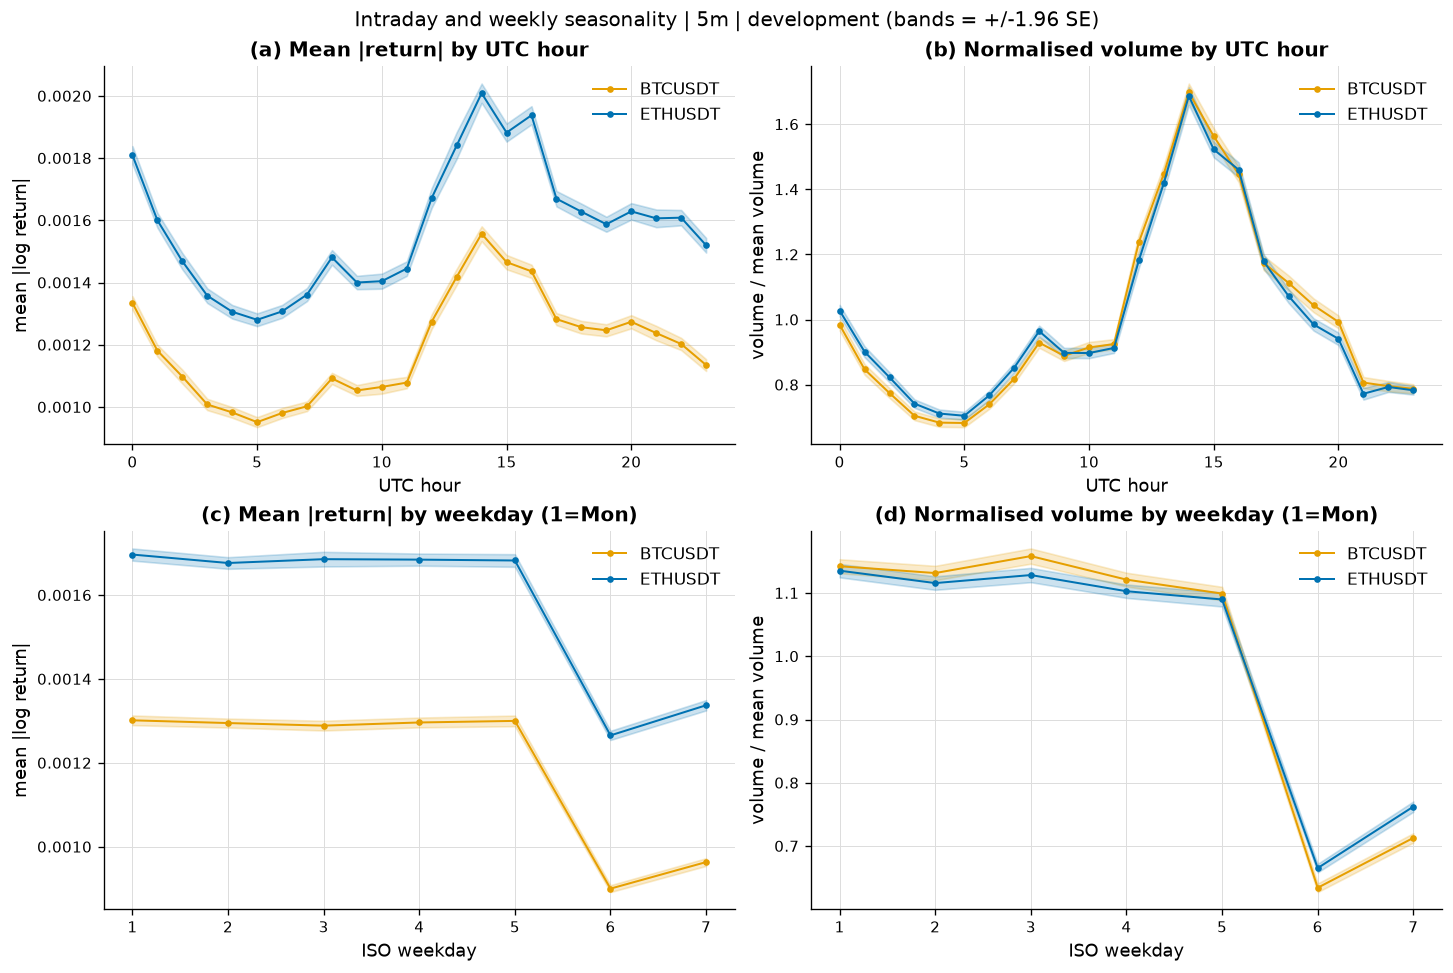

WindowsPath('reports/tables/eda/t24_seasonality_hour.md')

In [25]:
# Seasonality with normalised measures, +/-1.96 SE bands and Kruskal-Wallis (5m).
SEAS_TF = "5m"
seas = {
    sym: RET[sym][SEAS_TF].with_columns(
        pl.col("log_return").abs().alias("abs_ret"),
        (pl.col("volume") / pl.col("volume").mean()).alias("norm_volume"),
    )
    for sym in SYMBOLS
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)


def _plot_seasonality(ax, by, value_col, title, ylabel):
    for sym in SYMBOLS:
        s = eda.seasonality_stats(seas[sym], value_col, by=by)
        xv = s[by].to_numpy()
        m = s["mean"].to_numpy()
        er = 1.96 * s["stderr"].to_numpy()
        ax.plot(xv, m, color=asset_color(sym), lw=1.2, marker="o", ms=3, label=sym)
        ax.fill_between(xv, m - er, m + er, color=asset_color(sym), alpha=0.2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()


_plot_seasonality(
    axes[0, 0], "hour", "abs_ret", "(a) Mean |return| by UTC hour", "mean |log return|"
)
axes[0, 0].set_xlabel("UTC hour")
_plot_seasonality(
    axes[0, 1], "hour", "norm_volume", "(b) Normalised volume by UTC hour", "volume / mean volume"
)
axes[0, 1].set_xlabel("UTC hour")
_plot_seasonality(
    axes[1, 0], "weekday", "abs_ret", "(c) Mean |return| by weekday (1=Mon)", "mean |log return|"
)
axes[1, 0].set_xlabel("ISO weekday")
_plot_seasonality(
    axes[1, 1],
    "weekday",
    "norm_volume",
    "(d) Normalised volume by weekday (1=Mon)",
    "volume / mean volume",
)
axes[1, 1].set_xlabel("ISO weekday")
fig.suptitle(
    f"Intraday and weekly seasonality | {SEAS_TF} | development (bands = +/-1.96 SE)", fontsize=12
)
show(
    fig,
    "f13_seasonality",
    caption="UTC hour-of-day and weekday seasonality of |return| and normalised volume (5m, development)",
)

kr_rows = []
for sym in SYMBOLS:
    for by in ("hour", "weekday"):
        for val in ("abs_ret", "norm_volume"):
            k = eda.seasonality_kruskal(seas[sym], val, by=by)
            kr_rows.append(
                {
                    "symbol": sym,
                    "dimension": by,
                    "variable": val,
                    "H": round(k.get("H", float("nan")), 1),
                    "pvalue": k.get("pvalue", float("nan")),
                    "n_groups": int(k.get("n_groups", 0)),
                    "n": int(k.get("n", 0)),
                }
            )
save_table(
    pl.DataFrame(kr_rows),
    "t25_seasonality_kruskal",
    ctx,
    caption="Kruskal-Wallis omnibus test of |return|/normalised-volume across UTC hours and weekdays (5m, development). "
    "Omnibus only; no pairwise comparisons, so no multiple-comparison correction is required.",
)
btc_hour = (
    eda.seasonality_stats(seas["BTCUSDT"], "abs_ret", by="hour")
    .with_columns(
        pl.col("mean").mul(1e4).round(2).alias("mean_absret_bps"),
        pl.col("stderr").mul(1e4).round(3).alias("stderr_bps"),
    )
    .select("hour", "count", "mean_absret_bps", "stderr_bps")
)
save_table(
    btc_hour,
    "t24_seasonality_hour",
    ctx,
    caption="BTC |return| by UTC hour with sample size and SE (5m, development)",
)

**Interpretation (RQ6, parts 1-2).** *What is observed:* market activity is **positively associated
with contemporaneous absolute price movements** (Spearman rho of roughly 0.4 for both assets), but it
**does not show a meaningful monotonic relationship with the rolling annualised volatility estimate**
(rho near zero, slightly negative). The one-lag correlation is much weaker than the contemporaneous
one, so activity is coincident, not leading. The taker-buy imbalance is centred near zero with only a
mild UTC-hour profile. Seasonality shows a repeatable UTC intraday shape (higher activity around the
European/US overlap) and milder weekday effects; Kruskal-Wallis rejects equality across
hours/weekdays, but with such large samples the *economic* amplitude is modest. *Evidence:* tables
t21-t25 (incl. t23b) and figures f11, f13, f14. *What cannot be concluded:* rank correlations are
descriptive and in-sample seasonality overfits easily; none of this is causal, predictive or tradable
on its own. *Decision:* liquidity/activity and order-flow proxies feed transaction-cost/slippage
models and volatility-state features; UTC time-of-day is a plausible *conditioning* feature to be
confirmed out-of-sample, never a standalone signal.

## 9. Funding rates and mark-price basis

**Analytical question (RQ6, part 3).** How does the perpetual funding rate behave, how does it relate
to future price action, and how large is the trade-vs-mark basis? **Method.** We summarise the
funding distribution (positive/zero/negative shares, mean/median, tail quantiles), persistence (lag-1
and lag-3 autocorrelation), sign runs, and a yearly subperiod summary, then estimate a strictly
**leak-free** relationship between funding known at time t and future returns (funding attached by a
backward as-of join; the forward return lies entirely after t). We then align trading-price close and
mark-price close on **matched timestamps only** and analyse the basis in basis points. **Caution:**
funding is treated as a *holding cost / positioning* variable, not as direct evidence that price will
rise or fall.

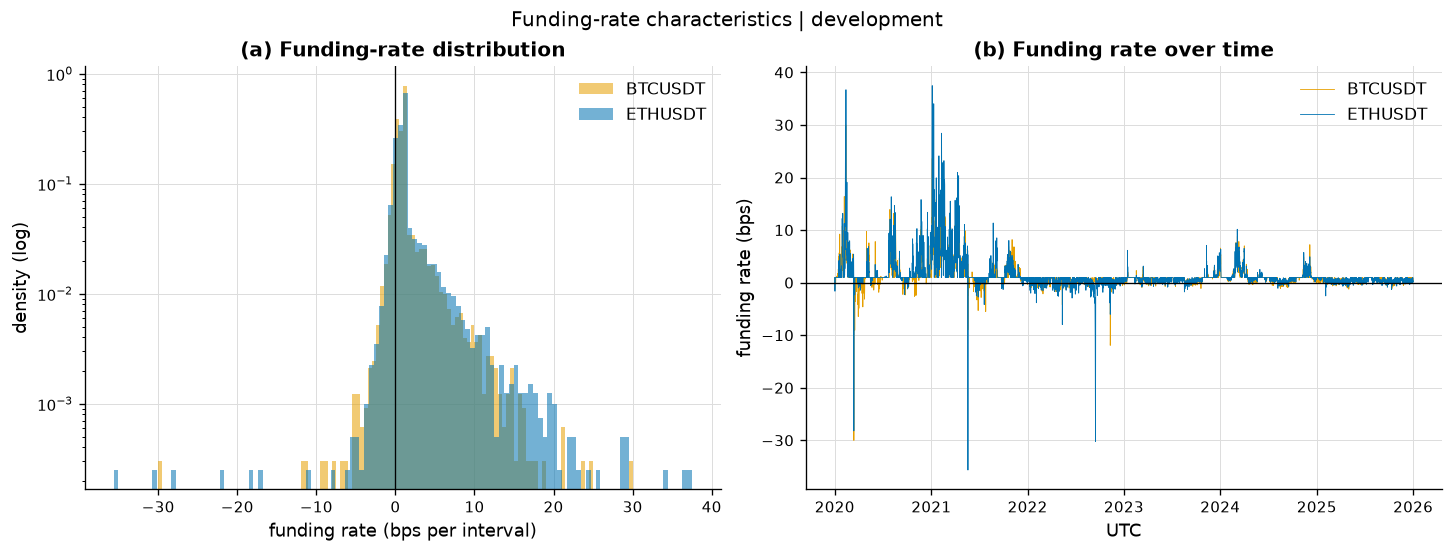

shape: (2, 15)
┌─────────┬──────┬────────────────┬────────────┬───┬──────────┬──────────┬──────────────────┬─────────────┐
│ symbol  ┆ n    ┆ share_positive ┆ share_zero ┆ … ┆ acf_lag1 ┆ acf_lag3 ┆ sign_change_freq ┆ avg_run_len │
│ ---     ┆ ---  ┆ ---            ┆ ---        ┆   ┆ ---      ┆ ---      ┆ ---              ┆ ---         │
│ str     ┆ i64  ┆ f64            ┆ f64        ┆   ┆ f64      ┆ f64      ┆ f64              ┆ f64         │
╞═════════╪══════╪════════════════╪════════════╪═══╪══════════╪══════════╪══════════════════╪═════════════╡
│ BTCUSDT ┆ 6576 ┆ 0.875          ┆ 0.0        ┆ … ┆ 0.796    ┆ 0.693    ┆ 0.125            ┆ 7.96        │
│ ETHUSDT ┆ 6576 ┆ 0.883          ┆ 0.0        ┆ … ┆ 0.786    ┆ 0.65     ┆ 0.126            ┆ 7.93        │
└─────────┴──────┴────────────────┴────────────┴───┴──────────┴──────────┴──────────────────┴─────────────┘


WindowsPath('reports/tables/eda/t28_funding_future_returns.md')

In [26]:
# Funding distribution and evolution.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for sym in SYMBOLS:
    fr = FUND[sym]["funding_rate"].drop_nulls().to_numpy() * 1e4
    axes[0].hist(fr, bins=120, density=True, color=asset_color(sym), alpha=0.55, label=sym)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_yscale("log")
axes[0].set_title("(a) Funding-rate distribution")
axes[0].set_xlabel("funding rate (bps per interval)")
axes[0].set_ylabel("density (log)")
axes[0].legend()
for sym in SYMBOLS:
    f = FUND[sym].sort("funding_time")
    axes[1].plot(
        f["funding_time"].to_numpy(),
        f["funding_rate"].to_numpy() * 1e4,
        color=asset_color(sym),
        lw=0.5,
        label=sym,
    )
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("(b) Funding rate over time")
axes[1].set_xlabel("UTC")
axes[1].set_ylabel("funding rate (bps)")
axes[1].legend()
fig.suptitle("Funding-rate characteristics | development", fontsize=12)
show(fig, "f16_funding", caption="Funding-rate distribution and evolution (development)")

fund_rows = []
for sym in SYMBOLS:
    dyn = eda.funding_dynamics(FUND[sym])
    summ = eda.funding_summary(FUND[sym])
    ac = eda.funding_autocorr(FUND[sym], lags=(1, 3))
    fr = FUND[sym]["funding_rate"].drop_nulls().to_numpy()
    q = np.quantile(fr, [0.01, 0.05, 0.95, 0.99]) * 1e4
    fund_rows.append(
        {
            "symbol": sym,
            "n": int(fr.size),
            "share_positive": round(dyn["share_positive"], 3),
            "share_zero": round(float(np.mean(fr == 0)), 3),
            "share_negative": round(dyn["share_negative"], 3),
            "mean_bps": round(summ["mean"] * 1e4, 4),
            "median_bps": round(float(np.median(fr)) * 1e4, 4),
            "p01_bps": round(float(q[0]), 3),
            "p05_bps": round(float(q[1]), 3),
            "p95_bps": round(float(q[2]), 3),
            "p99_bps": round(float(q[3]), 3),
            "acf_lag1": round(ac["acf_lag1"], 3),
            "acf_lag3": round(ac["acf_lag3"], 3),
            "sign_change_freq": round(dyn["sign_change_freq"], 3),
            "avg_run_len": round(dyn["avg_run_length"], 2),
        }
    )
with pl.Config(tbl_width_chars=320):
    print(pl.DataFrame(fund_rows))
save_table(
    pl.DataFrame(fund_rows),
    "t26_funding_dynamics",
    ctx,
    caption="Funding summary (shares, mean/median, tail quantiles), lag-1/lag-3 persistence and sign behaviour (development)",
)

runs_rows = [
    eda.funding_sign_runs(FUND[sym]).with_columns(
        pl.lit(sym).alias("symbol"), pl.col("mean_len").round(2)
    )
    for sym in SYMBOLS
]
save_table(
    pl.concat(runs_rows).select("symbol", "sign", "n_runs", "mean_len", "max_len"),
    "t27_funding_runs",
    ctx,
    caption="Length of consecutive positive/negative funding runs (development)",
)
year_rows = []
for sym in SYMBOLS:
    fy = FUND[sym].with_columns(pl.col("funding_time").dt.year().alias("year"))
    for y in sorted(fy["year"].unique().to_list()):
        sub = fy.filter(pl.col("year") == y)["funding_rate"].to_numpy()
        year_rows.append(
            {
                "symbol": sym,
                "year": int(y),
                "n": int(sub.size),
                "mean_bps": round(float(np.mean(sub)) * 1e4, 4),
                "share_positive": round(float(np.mean(sub > 0)), 3),
            }
        )
save_table(
    pl.DataFrame(year_rows),
    "t27b_funding_yearly",
    ctx,
    caption="Yearly funding summary (development)",
)

fut_rows = []
for sym in SYMBOLS:
    rel = eda.funding_future_return_relation(
        RET[sym][PRIMARY_TF], FUND[sym], horizons=(1, 3, 8, 24)
    )
    for r in rel.iter_rows(named=True):
        fut_rows.append(
            {
                "symbol": sym,
                "horizon_bars_1h": r["horizon_bars"],
                "n": r["n"],
                "spearman": r["spearman"],
            }
        )
save_table(
    pl.DataFrame(fut_rows),
    "t28_funding_future_returns",
    ctx,
    caption="Leak-free Spearman correlation between funding known at t and forward 1h returns over horizons (development). Effect sizes are small; funding costs and execution are ignored.",
)

shape: (2, 10)
┌─────────┬───────────┬──────────────┬──────────┬───┬─────────┬─────────┬─────────┬─────────┐
│ symbol  ┆ n_matched ┆ coverage_pct ┆ mean_bps ┆ … ┆ p01_bps ┆ p05_bps ┆ p95_bps ┆ p99_bps │
│ ---     ┆ ---       ┆ ---          ┆ ---      ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str     ┆ i64       ┆ f64          ┆ f64      ┆   ┆ f64     ┆ f64     ┆ f64     ┆ f64     │
╞═════════╪═══════════╪══════════════╪══════════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ BTCUSDT ┆ 628978    ┆ 99.633       ┆ -0.1137  ┆ … ┆ -7.503  ┆ -3.416  ┆ 3.339   ┆ 9.095   │
│ ETHUSDT ┆ 630705    ┆ 99.906       ┆ 0.1681   ┆ … ┆ -7.647  ┆ -3.528  ┆ 5.148   ┆ 12.818  │
└─────────┴───────────┴──────────────┴──────────┴───┴─────────┴─────────┴─────────┴─────────┘


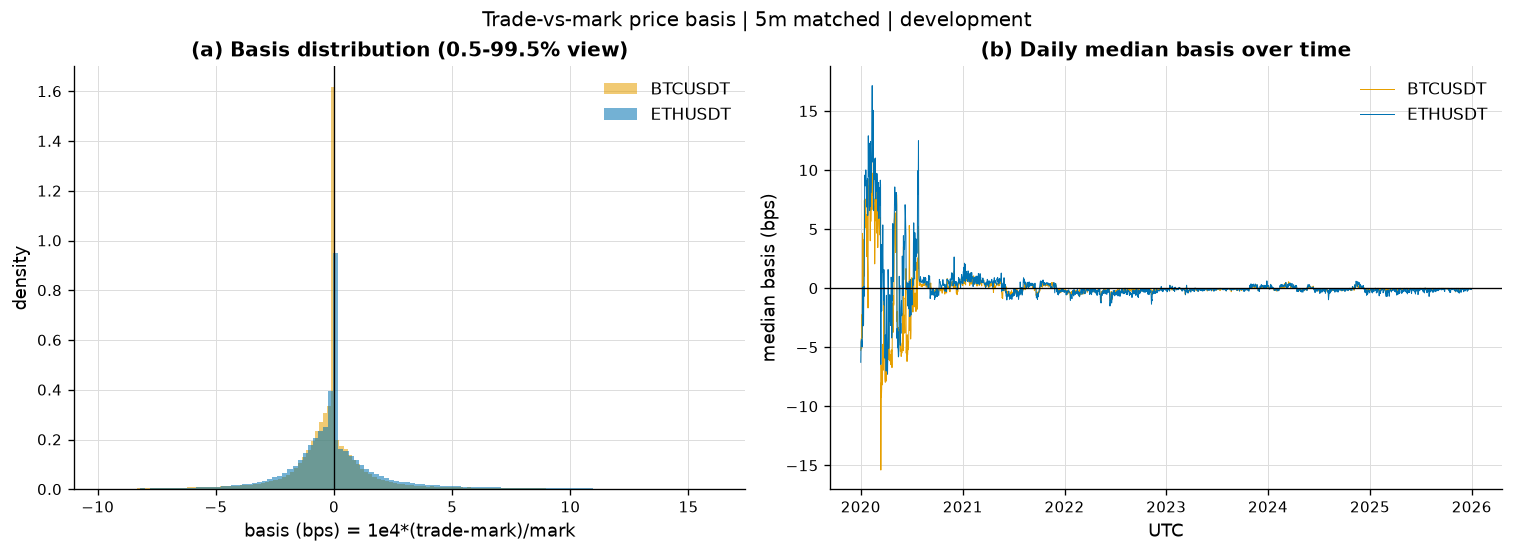

In [27]:
# Trade-vs-mark price basis on matched timestamps only (NEW).
basis_rows, basis_series = [], {}
for sym in SYMBOLS:
    bs = eda.mark_price_basis(KL[sym]["5m"], MARK[sym])
    basis_series[sym] = bs
    summ = eda.basis_summary(KL[sym]["5m"], MARK[sym], n_expected=KL[sym]["5m"].height)
    if summ:
        basis_rows.append(
            {
                "symbol": sym,
                "n_matched": int(summ["n_matched"]),
                "coverage_pct": summ.get("coverage_pct"),
                "mean_bps": round(summ["mean_bps"], 4),
                "median_bps": round(summ["median_bps"], 4),
                "std_bps": round(summ["std_bps"], 4),
                "p01_bps": round(summ["p01_bps"], 3),
                "p05_bps": round(summ["p05_bps"], 3),
                "p95_bps": round(summ["p95_bps"], 3),
                "p99_bps": round(summ["p99_bps"], 3),
            }
        )
basis_tbl = pl.DataFrame(basis_rows)
with pl.Config(tbl_width_chars=260):
    print(basis_tbl)
save_table(
    basis_tbl,
    "t08_basis_summary",
    ctx,
    caption="Trade-vs-mark basis (bps) on matched 5m timestamps only; mark-price gaps are never imputed (development)",
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)
for sym in SYMBOLS:
    b = basis_series[sym]
    vals = b["basis_bps"].to_numpy()
    core = vals[(vals >= np.quantile(vals, 0.005)) & (vals <= np.quantile(vals, 0.995))]
    axes[0].hist(core, bins=120, density=True, color=asset_color(sym), alpha=0.55, label=sym)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("(a) Basis distribution (0.5-99.5% view)")
axes[0].set_xlabel("basis (bps) = 1e4*(trade-mark)/mark")
axes[0].set_ylabel("density")
axes[0].legend()
for sym in SYMBOLS:
    b = (
        basis_series[sym]
        .with_columns(pl.col("open_time").dt.truncate("1d").alias("day"))
        .group_by("day")
        .agg(pl.col("basis_bps").median().alias("m"))
        .sort("day")
    )
    axes[1].plot(b["day"].to_numpy(), b["m"].to_numpy(), color=asset_color(sym), lw=0.6, label=sym)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("(b) Daily median basis over time")
axes[1].set_xlabel("UTC")
axes[1].set_ylabel("median basis (bps)")
axes[1].legend()
fig.suptitle("Trade-vs-mark price basis | 5m matched | development", fontsize=12)
show(
    fig,
    "f15_mark_price_basis",
    caption="Trade-vs-mark basis distribution (robust view) and daily-median evolution (5m matched timestamps, development). "
    "A limited liquidity proxy: it does not substitute for bid-ask spread or order-book depth.",
)

**Interpretation (RQ6, part 3).** *What is observed:* funding is small (a few basis points per 8-hour
interval), tightly centred near zero with a mild **positive** bias (longs pay shorts more often),
heavy-tailed and **persistent** (high lag-1 and still-material lag-3 autocorrelation, long same-sign
runs). Its leak-free rank correlation with future returns is weak at every horizon. The trade-vs-mark
basis is tiny (near zero, a handful of basis points) and mean-reverting, with a few wider excursions
in stress episodes. *Evidence:* tables t26-t28 and t08, figures f15-f16. *What cannot be concluded:* a
weak non-zero funding correlation is not a tradable signal once costs and execution are included, and
the basis is a limited proxy that omits bid-ask spread and depth. *Decision:* model funding as an
explicit **holding cost** and treat both funding and basis as candidate regime/positioning
conditioning variables (backward joins only), not as direct return predictors.

## 10. BTC-ETH dependence

**Analytical question (RQ7).** How strongly and stably do BTC and ETH co-move, including in the tails?
**Method.** After validating timestamp alignment we compute full-period Pearson and Spearman
correlation, rolling correlation over 1-day/7-day/30-day windows, correlation conditional on
volatility regimes and on the sign of BTC returns, upper/lower tail co-exceedance, and block-bootstrap
confidence intervals. The lead-lag sign convention is documented explicitly and lead-lag results are
treated as descriptive only. **Caution:** a high sample correlation does not imply stable future
diversification.

Alignment (1h): BTC=52608, ETH=52608, common timestamps=52608
Full-period Pearson  return correlation: 0.8394
Full-period Spearman return correlation: 0.8199
Lead-lag sign convention: cross_correlation lag k = corr(BTC_t, ETH_{t-k}); k>0 means BTC's PAST relates to ETH's present (BTC leads ETH); k<0 means ETH leads BTC.


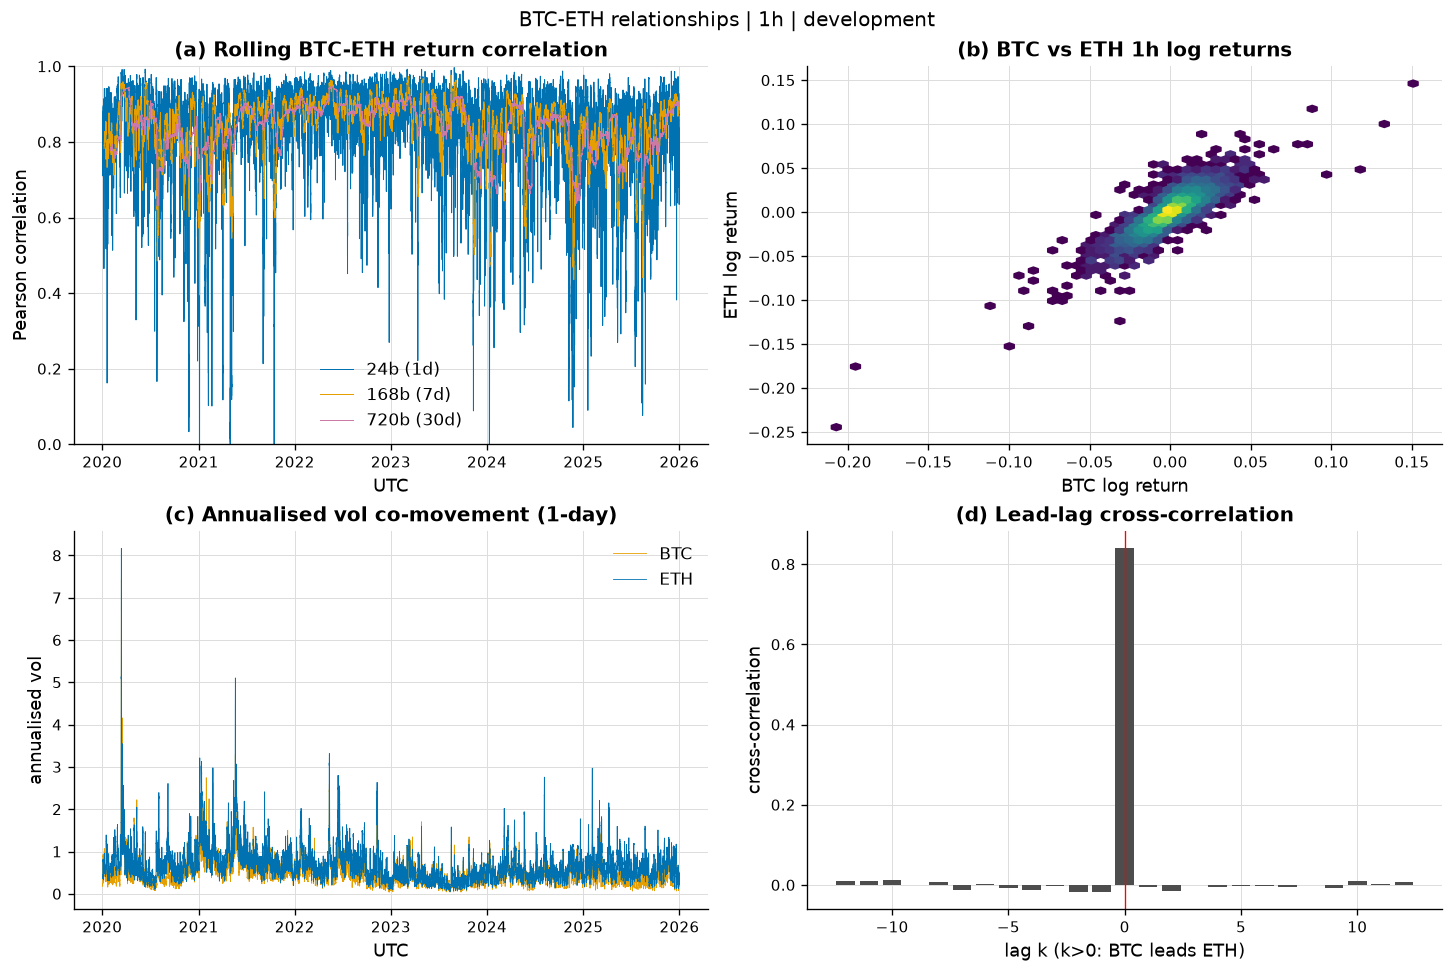

shape: (5, 4)
┌──────────────┬───────────────┬───────┬─────────┐
│ conditioning ┆ vol_regime    ┆ n     ┆ pearson │
│ ---          ┆ ---           ┆ ---   ┆ ---     │
│ str          ┆ str           ┆ i64   ┆ f64     │
╞══════════════╪═══════════════╪═══════╪═════════╡
│ vol_regime   ┆ low           ┆ 17353 ┆ 0.771   │
│ vol_regime   ┆ medium        ┆ 17353 ┆ 0.8093  │
│ vol_regime   ┆ high          ┆ 17878 ┆ 0.8592  │
│ btc_sign     ┆ left_positive ┆ 26722 ┆ 0.7267  │
│ btc_sign     ┆ left_negative ┆ 25871 ┆ 0.8037  │
└──────────────┴───────────────┴───────┴─────────┘


Block-bootstrap (block=24=1 day, 500 resamples) Pearson: point=0.8394 95% CI=[0.8261, 0.8518]  n=52607


In [28]:
# BTC-ETH alignment, correlation, rolling stability, vol co-movement, lead-lag.
CA_TF = PRIMARY_TF
btc, eth = RET["BTCUSDT"][CA_TF], RET["ETHUSDT"][CA_TF]
n_common = btc.select("open_time").join(eth.select("open_time"), on="open_time", how="inner").height
print(f"Alignment ({CA_TF}): BTC={btc.height}, ETH={eth.height}, common timestamps={n_common}")
print(
    f"Full-period Pearson  return correlation: {eda.static_correlation(btc, eth, 'log_return'):.4f}"
)
print(
    f"Full-period Spearman return correlation: {eda.spearman_correlation(btc, eth, 'log_return'):.4f}"
)
print(
    "Lead-lag sign convention: cross_correlation lag k = corr(BTC_t, ETH_{t-k}); "
    "k>0 means BTC's PAST relates to ETH's present (BTC leads ETH); k<0 means ETH leads BTC."
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax = axes[0, 0]
for w, cc in ((24, "#0072B2"), (168, "#E69F00"), (720, "#CC79A7")):
    rc = eda.rolling_correlation(btc, eth, w, "log_return")
    ax.plot(
        rc["open_time"].to_numpy(),
        rc[f"rolling_corr_{w}"].to_numpy(),
        lw=0.6,
        color=cc,
        label=f"{w}b ({w // 24}d)",
    )
ax.set_title("(a) Rolling BTC-ETH return correlation")
ax.set_xlabel("UTC")
ax.set_ylabel("Pearson correlation")
ax.set_ylim(0, 1)
ax.legend()
ax = axes[0, 1]
j = (
    btc.select("open_time", pl.col("log_return").alias("btc"))
    .join(eth.select("open_time", pl.col("log_return").alias("eth")), on="open_time", how="inner")
    .drop_nulls()
)
ax.hexbin(j["btc"].to_numpy(), j["eth"].to_numpy(), gridsize=60, bins="log", cmap="viridis")
ax.set_title("(b) BTC vs ETH 1h log returns")
ax.set_xlabel("BTC log return")
ax.set_ylabel("ETH log return")
ax = axes[1, 0]
bv = eda.annualized_volatility(btc, CA_TF, 24, days_per_year=DAYS_PER_YEAR)
ev = eda.annualized_volatility(eth, CA_TF, 24, days_per_year=DAYS_PER_YEAR)
vj = (
    bv.select("open_time", pl.col("ann_vol_24").alias("bvol"))
    .join(ev.select("open_time", pl.col("ann_vol_24").alias("evol")), on="open_time", how="inner")
    .drop_nulls()
)
ax.plot(
    vj["open_time"].to_numpy(),
    vj["bvol"].to_numpy(),
    color=asset_color("BTCUSDT"),
    lw=0.5,
    label="BTC",
)
ax.plot(
    vj["open_time"].to_numpy(),
    vj["evol"].to_numpy(),
    color=asset_color("ETHUSDT"),
    lw=0.5,
    label="ETH",
)
ax.set_title("(c) Annualised vol co-movement (1-day)")
ax.set_xlabel("UTC")
ax.set_ylabel("annualised vol")
ax.legend()
ax = axes[1, 1]
cc = eda.cross_correlation(btc, eth, "log_return", max_lag=12)
ax.bar(cc["lag"].to_numpy(), cc["cross_corr"].to_numpy(), color="#4D4D4D", width=0.8)
ax.axvline(0, color="red", lw=0.8)
ax.set_title("(d) Lead-lag cross-correlation")
ax.set_xlabel("lag k (k>0: BTC leads ETH)")
ax.set_ylabel("cross-correlation")
fig.suptitle(f"BTC-ETH relationships | {CA_TF} | development", fontsize=12)
show(
    fig,
    "f17_cross_asset",
    caption="BTC-ETH correlation, rolling stability, vol co-movement and lead-lag (1h, development)",
)

ca_rows = []
for tf in TIMEFRAMES:
    b, e = RET["BTCUSDT"][tf], RET["ETHUSDT"][tf]
    tc = eda.tail_coexceedance(b, e, "log_return", quantile=0.05)
    pk = eda.peak_lag(eda.cross_correlation(b, e, "log_return", max_lag=12))
    ca_rows.append(
        {
            "timeframe": tf,
            "pearson": round(eda.static_correlation(b, e, "log_return"), 4),
            "spearman": round(eda.spearman_correlation(b, e, "log_return"), 4),
            "lower_tail_exceed_ratio": round(tc.get("lower_exceedance_ratio", float("nan")), 2),
            "upper_tail_exceed_ratio": round(tc.get("upper_exceedance_ratio", float("nan")), 2),
            "peak_leadlag_lag": pk.get("lag", float("nan")),
            "peak_leadlag_corr": round(pk.get("cross_corr", float("nan")), 4),
        }
    )
save_table(
    pl.DataFrame(ca_rows),
    "t29_cross_asset",
    ctx,
    caption="BTC-ETH Pearson/Spearman correlation, 5% tail co-exceedance ratios and peak lead-lag by timeframe (development)",
)

by_vol = eda.correlation_by_vol_regime(btc, eth, vol_window=24).with_columns(
    pl.lit("vol_regime").alias("conditioning")
)
by_sign = (
    eda.correlation_by_sign(btc, eth)
    .rename({"condition": "vol_regime"})
    .with_columns(pl.lit("btc_sign").alias("conditioning"))
)
conditional_corr = pl.concat(
    [
        by_vol.select("conditioning", "vol_regime", "n", "pearson"),
        by_sign.select("conditioning", "vol_regime", "n", "pearson"),
    ]
)
print(conditional_corr)
save_table(
    conditional_corr,
    "t30_conditional_correlation",
    ctx,
    caption="BTC-ETH return correlation conditional on BTC volatility regime and on BTC return sign (1h, development)",
)
ci = eda.block_bootstrap_corr_ci(btc, eth, block=24, n_boot=500, seed=SEED)
print(
    f"Block-bootstrap (block=24=1 day, 500 resamples) Pearson: point={ci.get('corr')} "
    f"95% CI=[{ci.get('ci_low')}, {ci.get('ci_high')}]  n={int(ci.get('n', 0))}"
)

**Interpretation (RQ7).** *What is observed:* BTC and ETH are strongly positively correlated in
returns (Pearson and Spearman typically 0.7-0.9 at 1h) and even more so in volatility; correlation is
**higher in high-volatility regimes** and the **lower tail co-moves more than the upper** (crashes are
more synchronised than rallies). Rolling correlation is high but clearly time-varying, and the
block-bootstrap CI is tight and well above zero. The lead-lag function peaks at (or immediately
adjacent to) lag 0. *Evidence:* tables t29-t30 and figure f17. *What cannot be concluded:* a high
sample correlation does not guarantee stable future diversification, and a small off-zero lead-lag
peak is not evidence of a tradable lead. *Decision:* treat BTC and ETH as sharing a risk factor
(limited diversification, especially in stress) for portfolio-exposure and risk purposes; cross-asset
context is a candidate feature, but no naive lead-lag arbitrage is warranted.

## 11. Multi-timeframe comparison

**Analytical question (RQ2/RQ4 synthesis).** What are the trade-offs of 5m, 15m and 1h, and which is
the best compromise for strategy development, ML and backtesting? **Method.** We assemble the
**multi-timeframe comparison (Summary Table 5)**: sample size, per-bar and annualised volatility,
excess kurtosis, tail quantiles, lag-1 ACF of raw and absolute returns, average observations per
intended holding period, and qualitative turnover/microstructure/cost implications plus coverage. We
visualise the two key trade-off curves and give an explicit, evidence-based justification for 1h,
while keeping 5m and 15m for complementary experiments.

shape: (6, 15)
┌───────────┬─────────┬─────────────┬─────────────────┬───┬──────────────────┬──────────────────────┬───────────────┬──────────────┐
│ timeframe ┆ symbol  ┆ sample_size ┆ per_bar_vol_bps ┆ … ┆ turnover_implied ┆ microstructure_noise ┆ relative_cost ┆ coverage_pct │
│ ---       ┆ ---     ┆ ---         ┆ ---             ┆   ┆ ---              ┆ ---                  ┆ ---           ┆ ---          │
│ str       ┆ str     ┆ i64         ┆ f64             ┆   ┆ str              ┆ str                  ┆ f64           ┆ f64          │
╞═══════════╪═════════╪═════════════╪═════════════════╪═══╪══════════════════╪══════════════════════╪═══════════════╪══════════════╡
│ 15m       ┆ BTCUSDT ┆ 210431      ┆ 34.59           ┆ … ┆ medium           ┆ medium               ┆ 4.0           ┆ 100.0        │
│ 1h        ┆ BTCUSDT ┆ 52607       ┆ 67.3            ┆ … ┆ low-medium       ┆ low                  ┆ 1.0           ┆ 100.0        │
│ 5m        ┆ BTCUSDT ┆ 631295      ┆ 20.62           

[12:17:06] INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

           INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If 
                    these strings should be plotted as numbers, cast to the appropriate data type before plotting.

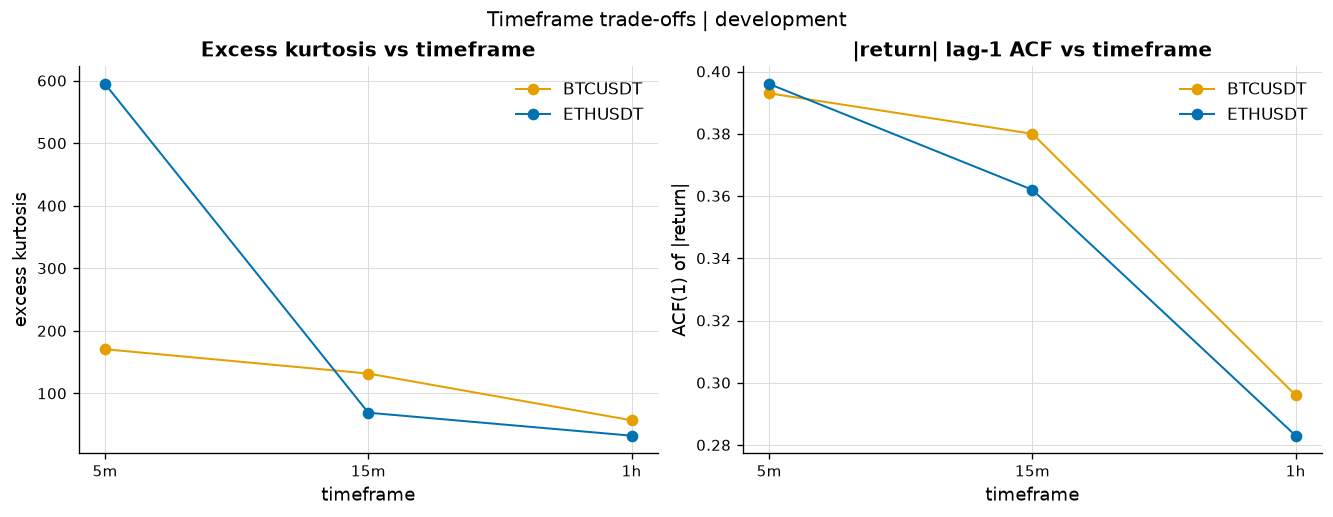

In [29]:
# === SUMMARY TABLE 5: multi-timeframe comparison / decision table ============
QUAL = {
    "5m": {"turnover": "high", "microstructure_noise": "high"},
    "15m": {"turnover": "medium", "microstructure_noise": "medium"},
    "1h": {"turnover": "low-medium", "microstructure_noise": "low"},
}
rows_1h = {sym: RET[sym][PRIMARY_TF].height for sym in SYMBOLS}
dec_rows = []
for tf in TIMEFRAMES:
    for sym in SYMBOLS:
        r = RET[sym][tf]
        s = eda.return_stats(r, "log_return")
        vals = r.select("log_return").drop_nulls().to_series().to_numpy()
        p01, p99 = np.quantile(vals, [0.01, 0.99])
        acf_raw = float(
            eda.autocorrelation(r, "log_return", max_lag=1, transform="identity")["acf"].to_numpy()[
                1
            ]
        )
        acf_abs = float(
            eda.autocorrelation(r, "log_return", max_lag=1, transform="abs")["acf"].to_numpy()[1]
        )
        ann = eda.annualization_factor(tf, DAYS_PER_YEAR)
        dec_rows.append(
            {
                "timeframe": tf,
                "symbol": sym,
                "sample_size": int(s["n"]),
                "per_bar_vol_bps": round(1e4 * s["std"], 2),
                "ann_vol": round(s["std"] * ann, 3),
                "exc_kurt": round(s["excess_kurtosis"], 1),
                "p01_bps": round(1e4 * float(p01), 1),
                "p99_bps": round(1e4 * float(p99), 1),
                "acf1_rawret": round(acf_raw, 4),
                "acf1_absret": round(acf_abs, 3),
                "obs_per_day": DAY_WINDOW[tf],
                "turnover_implied": QUAL[tf]["turnover"],
                "microstructure_noise": QUAL[tf]["microstructure_noise"],
                "relative_cost": round(r.height / rows_1h[sym], 1),
                "coverage_pct": COV_LOOKUP.get((sym, tf)),
            }
        )
timeframe_decision = pl.DataFrame(dec_rows).sort("symbol", "timeframe")
with pl.Config(tbl_rows=20, tbl_width_chars=400):
    print(timeframe_decision)
save_table(
    timeframe_decision,
    "s5_timeframe_comparison",
    ctx,
    caption="Summary Table 5 - multi-timeframe comparison: sample size, volatility, excess kurtosis, tail quantiles, "
    "raw/abs ACF(1), obs per holding period, turnover/microstructure/cost and coverage (development)",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)


def _by_tf(sym, metric):
    return [
        timeframe_decision.filter((pl.col("symbol") == sym) & (pl.col("timeframe") == tf))[metric][
            0
        ]
        for tf in TIMEFRAMES
    ]


for sym in SYMBOLS:
    axes[0].plot(TIMEFRAMES, _by_tf(sym, "exc_kurt"), marker="o", color=asset_color(sym), label=sym)
    axes[1].plot(
        TIMEFRAMES, _by_tf(sym, "acf1_absret"), marker="o", color=asset_color(sym), label=sym
    )
axes[0].set_title("Excess kurtosis vs timeframe")
axes[0].set_xlabel("timeframe")
axes[0].set_ylabel("excess kurtosis")
axes[0].legend()
axes[1].set_title("|return| lag-1 ACF vs timeframe")
axes[1].set_xlabel("timeframe")
axes[1].set_ylabel("ACF(1) of |return|")
axes[1].legend()
fig.suptitle("Timeframe trade-offs | development", fontsize=12)
show(
    fig,
    "f18_timeframe_tradeoffs",
    caption="Excess kurtosis and |return| autocorrelation across timeframes (development)",
)

**Interpretation and 1h selection (RQ2/RQ4).** *What is observed:* moving from 5m to 1h reduces excess
kurtosis and the lag-1 autocorrelation of |returns| (less microstructure noise per bar) while raising
per-bar volatility and shrinking sample size; volatility persistence and BTC-ETH correlation remain
high at all timeframes; coverage is identical. *Evidence:* Summary Table 5 and figure f18. *What
cannot be concluded:* no timeframe is universally optimal - coarser bars trade statistical power for
cleaner signal. *Decision:* **1h is selected as the primary strategy-development, ML and backtesting
timeframe** for this project because it offers the cleanest distributions and the most tractable
multiple-testing burden while retaining ample sample size (52,608 bars per asset), with 15m as a
secondary timeframe and 5m reserved for execution/microstructure studies. This is the chosen
compromise for this thesis, not a claim of universal optimality.

## 12. Preliminary market-regime analysis

**Analytical question (RQ8).** Can we characterise the market with transparent, provisional regimes?
**Method.** On the 1h series we tag a trend dimension (price vs a moving average), a volatility
dimension (rolling-vol terciles) and an activity dimension (rolling-volume terciles), all with
thresholds estimated on development data only. We show a price timeline shaded by **consolidated
volatility-regime episodes** (contiguous blocks, not per-bar stripes), the full transition-probability
matrix (including self-transitions), a conditional-on-leaving matrix, regime duration and
characteristics tables, and a sensitivity analysis over thresholds and windows. **These are
preliminary descriptive volatility regimes, not the definitive regimes used by the models;** if used
inside walk-forward models, thresholds must be re-fitted inside each training window.

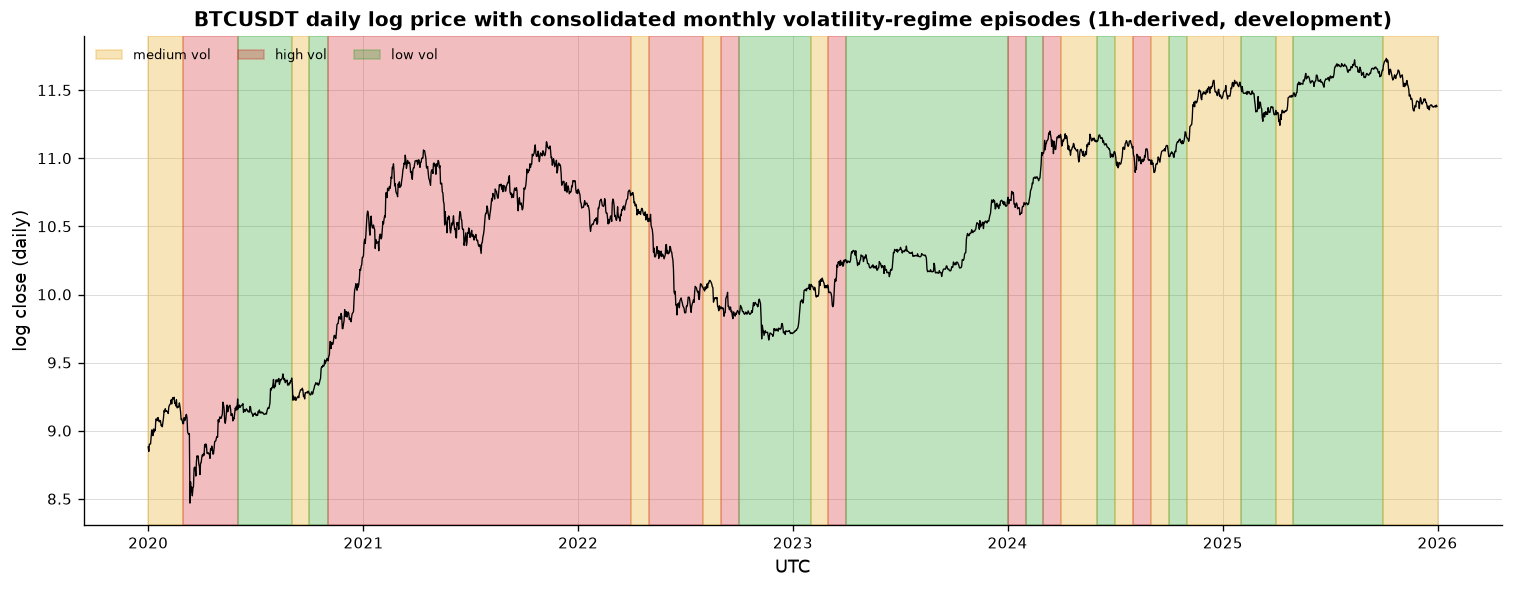

WindowsPath('reports/tables/eda/t32_regime_frequencies.md')

In [30]:
# Regime tagging (BTC 1h) with all context columns.
REG_TF, REG_SYM = PRIMARY_TF, "BTCUSDT"
base = RET[REG_SYM][REG_TF]
tagged = eda.tag_trend_volatility_regimes(base, trend_window=168, vol_window=24)
tagged = eda.tag_activity_regime(tagged, value_col="volume", window=24)
tagged = eda.add_drawdown(tagged)
tagged = eda.add_liquidity_proxies(tagged, window=24)
tagged = eda.attach_funding(tagged, FUND[REG_SYM], tolerance="8h").with_columns(
    pl.col("log_return").abs().alias("abs_ret")
)

# Consolidated regime episodes on a MONTHLY dominant-regime series so persistent
# episodes read as solid blocks (no per-bar or per-day barcode). The daily price
# line is kept for visual detail.
daily = (
    tagged.with_columns(pl.col("open_time").dt.truncate("1d").alias("day"))
    .group_by("day")
    .agg(pl.col("close").last().alias("close"))
    .sort("day")
)
monthly = (
    tagged.with_columns(pl.col("open_time").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.col("vol_regime").mode().first().alias("vol_regime"))
    .sort("month")
)
intervals = (
    eda.regime_intervals(monthly, "vol_regime", time_col="month")
    .filter(pl.col("vol_regime").is_in(["low", "medium", "high"]))
    .with_columns(pl.col("end").dt.offset_by("1mo").alias("end_excl"))
)
fig, ax = plt.subplots(figsize=(12.5, 4.8), constrained_layout=True)
dt = daily["day"].to_numpy()
logp = np.log(daily["close"].to_numpy())
ax.plot(dt, logp, color="black", lw=0.8)  # establishes the datetime axis units first
starts, ends, regs = (
    intervals["start"].to_numpy(),
    intervals["end_excl"].to_numpy(),
    intervals["vol_regime"].to_list(),
)
seen = set()
for s, e, reg in zip(starts, ends, regs, strict=False):
    lbl = f"{reg} vol" if reg not in seen else None
    seen.add(reg)
    ax.axvspan(s, e, color=regime_color(reg), alpha=0.30, label=lbl)
ax.set_title(
    "BTCUSDT daily log price with consolidated monthly volatility-regime episodes (1h-derived, development)"
)
ax.set_xlabel("UTC")
ax.set_ylabel("log close (daily)")
ax.legend(loc="upper left", ncol=3, fontsize=8)
show(
    fig,
    "f19_regime_price_shading",
    caption="BTC daily log price shaded by consolidated monthly-dominant volatility-regime episodes derived from the 1h series (development). "
    "Preliminary descriptive volatility regimes, not the definitive model regimes.",
)

freq = eda.regime_frequencies(tagged, "regime").with_columns(pl.col("share").round(4))
save_table(
    freq,
    "t32_regime_frequencies",
    ctx,
    caption="Trend_volatility regime frequency and balance (BTC 1h, development)",
)

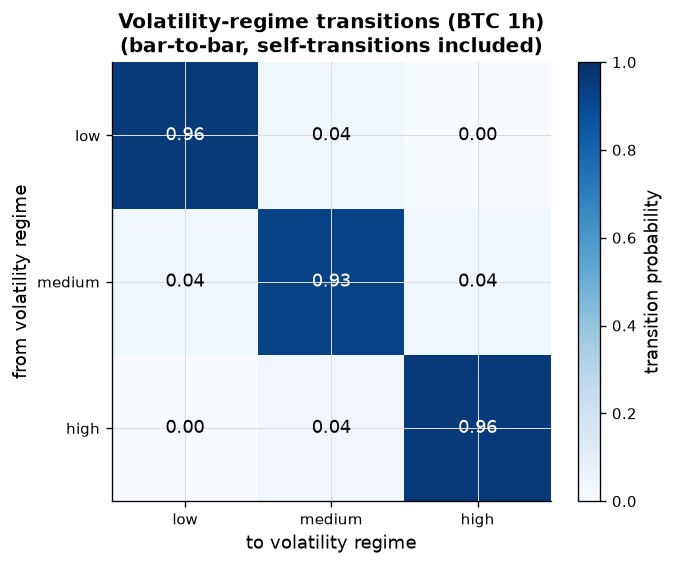

WindowsPath('reports/tables/eda/t33b_regime_transition_leaving.md')

In [31]:
# Full transition matrix (incl self) and conditional-on-leaving matrix.
states = ["low", "medium", "high"]
tm_full = eda.regime_transition_matrix_full(tagged, "vol_regime", normalize=True)
mat = np.full((3, 3), np.nan)
for row in tm_full.iter_rows(named=True):
    if row["from"] in states and row["to"] in states:
        mat[states.index(row["from"]), states.index(row["to"])] = row["probability"]
fig, ax = plt.subplots(figsize=(5.6, 4.6), constrained_layout=True)
im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), states)
ax.set_yticks(range(3), states)
ax.set_xlabel("to volatility regime")
ax.set_ylabel("from volatility regime")
ax.set_title("Volatility-regime transitions (BTC 1h)\n(bar-to-bar, self-transitions included)")
for i in range(3):
    for k in range(3):
        if not np.isnan(mat[i, k]):
            ax.text(
                k,
                i,
                f"{mat[i, k]:.2f}",
                ha="center",
                va="center",
                color="white" if mat[i, k] > 0.5 else "black",
            )
fig.colorbar(im, ax=ax, label="transition probability")
show(
    fig,
    "f20_regime_transitions_full",
    caption="Full bar-to-bar volatility-regime transition probabilities incl. self-transitions (BTC 1h, development)",
)
save_table(
    tm_full,
    "t33_regime_transition_full",
    ctx,
    caption="Full transition matrix incl. self-transitions (BTC 1h, development)",
)
save_table(
    eda.regime_transition_matrix(tagged, "vol_regime", normalize=True),
    "t33b_regime_transition_leaving",
    ctx,
    caption="Transition probabilities conditional on leaving the current volatility regime (BTC 1h, development)",
)

In [32]:
# Regime duration table, characteristics table and threshold/window sensitivity.
step_h = TIMEFRAME_TO_MS[REG_TF] / 3.6e6
dur = eda.regime_duration_table(tagged, "vol_regime").with_columns(
    pl.col("mean_bars").round(1),
    pl.col("median_bars").round(1),
    pl.col("occupancy").round(4),
    (pl.col("mean_bars") * step_h).round(1).alias("mean_hours"),
)
print(dur)
save_table(
    dur,
    "t34_regime_durations",
    ctx,
    caption="Volatility-regime episodes, occupancy and duration quantiles (BTC 1h, development)",
)

eth_ret = RET["ETHUSDT"][PRIMARY_TF].select("open_time", pl.col("log_return").alias("eth_ret"))
tagged2 = tagged.join(eth_ret, on="open_time", how="left")
char_rows = []
for key, g in tagged2.group_by("vol_regime", maintain_order=True):
    name = key[0] if isinstance(key, tuple) else key
    ret = g["log_return"].drop_nulls().to_numpy()
    both = g.select("log_return", "eth_ret").drop_nulls()
    corr = (
        float(np.corrcoef(both["log_return"].to_numpy(), both["eth_ret"].to_numpy())[0, 1])
        if both.height > 2
        else float("nan")
    )
    char_rows.append(
        {
            "vol_regime": name,
            "n": g.height,
            "mean_ret_bps": round(float(np.mean(ret)) * 1e4, 2),
            "ann_vol": round(float(np.std(ret)) * factor_1h, 3),
            "mean_absret_bps": round(float(g["abs_ret"].mean()) * 1e4, 2),
            "mean_drawdown": round(float(g["drawdown"].mean()), 4),
            "mean_rel_volume": round(float(g["rel_volume"].drop_nulls().mean()), 3),
            "btc_eth_corr": round(corr, 3),
            "mean_funding_bps": round(float(g["funding_rate"].drop_nulls().mean()) * 1e4, 4),
        }
    )
regime_char = pl.DataFrame(char_rows).sort("vol_regime")
with pl.Config(tbl_width_chars=300):
    print(regime_char)
save_table(
    regime_char,
    "t35_regime_characteristics",
    ctx,
    caption="Per-volatility-regime characteristics: mean return, annualised vol, |return|, drawdown, relative volume, BTC-ETH correlation and funding (BTC 1h, development)",
)

vol_ser = (
    base.select(pl.col("log_return").rolling_std(window_size=24, min_samples=24).alias("v"))
    .drop_nulls()["v"]
    .to_numpy()
)
sens_rows = []
for lo_q, hi_q in ((0.33, 0.66), (0.25, 0.75), (0.20, 0.80)):
    lo, hi = np.quantile(vol_ser, [lo_q, hi_q])
    sl, sh = float(np.mean(vol_ser <= lo)), float(np.mean(vol_ser > hi))
    sens_rows.append(
        {
            "vary": "thresholds",
            "setting": f"{lo_q:.2f}/{hi_q:.2f}",
            "window_bars": 24,
            "share_low": round(sl, 3),
            "share_medium": round(1 - sl - sh, 3),
            "share_high": round(sh, 3),
        }
    )
for w in (12, 24, 48):
    vs = (
        base.select(pl.col("log_return").rolling_std(window_size=w, min_samples=w).alias("v"))
        .drop_nulls()["v"]
        .to_numpy()
    )
    lo, hi = np.quantile(vs, [0.33, 0.66])
    sl, sh = float(np.mean(vs <= lo)), float(np.mean(vs > hi))
    sens_rows.append(
        {
            "vary": "window",
            "setting": "0.33/0.66",
            "window_bars": w,
            "share_low": round(sl, 3),
            "share_medium": round(1 - sl - sh, 3),
            "share_high": round(sh, 3),
        }
    )
print(pl.DataFrame(sens_rows))
save_table(
    pl.DataFrame(sens_rows),
    "t36_regime_sensitivity",
    ctx,
    caption="Sensitivity of volatility-regime shares to tercile thresholds and rolling-window length (BTC 1h, development)",
)

shape: (4, 8)
┌────────────┬────────────┬───────────┬─────────────┬──────────┬──────────┬───────────┬────────────┐
│ vol_regime ┆ n_episodes ┆ mean_bars ┆ median_bars ┆ p90_bars ┆ max_bars ┆ occupancy ┆ mean_hours │
│ ---        ┆ ---        ┆ ---       ┆ ---         ┆ ---      ┆ ---      ┆ ---       ┆ ---        │
│ str        ┆ u32        ┆ f64       ┆ f64         ┆ f64      ┆ u32      ┆ f64       ┆ f64        │
╞════════════╪════════════╪═══════════╪═════════════╪══════════╪══════════╪═══════════╪════════════╡
│ high       ┆ 644        ┆ 27.8      ┆ 18.0        ┆ 52.0     ┆ 720      ┆ 0.3398    ┆ 27.8       │
│ low        ┆ 684        ┆ 25.4      ┆ 10.5        ┆ 65.0     ┆ 547      ┆ 0.3299    ┆ 25.4       │
│ medium     ┆ 1280       ┆ 13.6      ┆ 9.0         ┆ 30.0     ┆ 99       ┆ 0.3299    ┆ 13.6       │
│ unknown    ┆ 1          ┆ 24.0      ┆ 24.0        ┆ 24.0     ┆ 24       ┆ 0.0005    ┆ 24.0       │
└────────────┴────────────┴───────────┴─────────────┴──────────┴──────────┴──

WindowsPath('reports/tables/eda/t36_regime_sensitivity.md')

**Interpretation (RQ8).** *What is observed:* the interpretable regimes partition the sample into
economically sensible states - high-volatility regimes carry larger absolute returns, deeper
drawdowns, higher relative volume and higher BTC-ETH correlation; low-volatility regimes are calmer
and more frequent. Regimes are persistent (the full transition matrix has a dominant diagonal) and
move gradually (low<->medium<->high) rather than jumping low<->high. Regime shares are moderately
sensitive to thresholds and window length. *Evidence:* tables t32-t36 and figures f19-f20. *What
cannot be concluded:* thresholds use full-development percentiles (mildly forward-looking) and the
labels are provisional. *Decision:* volatility state is the most promising conditioning axis for
regime evaluation and risk management; before any modelling, regime features must be re-implemented
causally with thresholds fitted inside each walk-forward training window.

## 13. Main findings and methodological implications

The **main empirical findings (Summary Table 6)** below synthesise the principal results. Each is
tagged with its research question, empirical evidence, scope, limitation, methodological implication,
and the downstream component it affects (feature engineering, strategy rules, risk management,
transaction-cost modelling, temporal validation, regime evaluation, meta-labeling or portfolio
exposure). These implications are *justifications for Chapter 5*, not feature engineering executed
inside the EDA.

In [33]:
# === SUMMARY TABLE 6: main empirical findings and methodological implications
findings = [
    {
        "finding_id": "F1",
        "research_question": "RQ1",
        "empirical_evidence": "Structural checks pass; counts match; coverage 100%; NO gaps detected; 5m->15m/1h resampling exact (s1-s2, t04-t10, f02)",
        "assets_timeframes": "BTC&ETH 5m/15m/1h",
        "limitation": "Mark-price has a few unmatched 5m stamps (never imputed)",
        "methodological_implication": "Proceed with all timeframes; no imputation",
        "downstream_component": "feature engineering; temporal validation",
    },
    {
        "finding_id": "F2",
        "research_question": "RQ2",
        "empirical_evidence": "Heavy-tailed, leptokurtic near-zero-mean returns; kurtosis falls with aggregation (s3, f05)",
        "assets_timeframes": "BTC&ETH all tf",
        "limitation": "Unconditional moments mix regimes",
        "methodological_implication": "Avoid Gaussian assumptions; robust/rank features",
        "downstream_component": "feature engineering; risk management",
    },
    {
        "finding_id": "F3",
        "research_question": "RQ3",
        "empirical_evidence": "Large historical VaR/ES; deep multi-week drawdowns; lower tail >= upper (s3, t11/t15/t16, f03,f07)",
        "assets_timeframes": "BTC&ETH all tf",
        "limitation": "Historical, not forecasts",
        "methodological_implication": "Tail-aware sizing and stress assumptions",
        "downstream_component": "risk management; portfolio exposure",
    },
    {
        "finding_id": "F4",
        "research_question": "RQ4",
        "empirical_evidence": "Strong volatility clustering; high vol persistence; ARCH-LM rejects (s4, t17, f08-f09)",
        "assets_timeframes": "BTC&ETH all tf",
        "limitation": "Level depends on estimator/window/annualisation",
        "methodological_implication": "Vol-scaling, vol-state features, window sizing",
        "downstream_component": "feature engineering; risk management; temporal validation",
    },
    {
        "finding_id": "F5",
        "research_question": "RQ5",
        "empirical_evidence": "Raw-return ACF negligible; |r| and r^2 ACF positive/persistent (t20, f10)",
        "assets_timeframes": "BTC&ETH all tf",
        "limitation": "Linear diagnostics only",
        "methodological_implication": "Do not assume linear return predictability",
        "downstream_component": "strategy rules; feature engineering",
    },
    {
        "finding_id": "F6",
        "research_question": "RQ6",
        "empirical_evidence": "Activity coincident with |return| (rho~0.4), ~0 with rolling vol; mild UTC seasonality; near-zero order-flow imbalance (t21-t25, f11,f13,f14)",
        "assets_timeframes": "BTC&ETH all tf",
        "limitation": "In-sample seasonality overfits easily",
        "methodological_implication": "Liquidity/slippage and order-flow features; time-of-day conditioning",
        "downstream_component": "transaction-cost modelling; feature engineering",
    },
    {
        "finding_id": "F7",
        "research_question": "RQ6",
        "empirical_evidence": "Funding small, mildly positive, heavy-tailed, persistent; weak leak-free link to future returns; tiny mean-reverting basis (t26-t28,t08, f15-f16)",
        "assets_timeframes": "BTC&ETH",
        "limitation": "Coarse 8h funding; backward join only",
        "methodological_implication": "Model funding as a cost; funding/basis as candidate features",
        "downstream_component": "transaction-cost modelling; feature engineering",
    },
    {
        "finding_id": "F8",
        "research_question": "RQ7",
        "empirical_evidence": "High return & vol correlation; stronger in high-vol; lower-tail co-exceedance; lead-lag ~0 (t29-t30, f17)",
        "assets_timeframes": "BTC-ETH all tf",
        "limitation": "Period/timeframe dependent",
        "methodological_implication": "Limited diversification; cross-asset context feature",
        "downstream_component": "portfolio exposure; feature engineering",
    },
    {
        "finding_id": "F9",
        "research_question": "RQ2/RQ4",
        "empirical_evidence": "Kurtosis and |r| ACF1 shrink from 5m to 1h; persistence/corr stable (s5, f18)",
        "assets_timeframes": "BTC&ETH 5m/15m/1h",
        "limitation": "Fewer observations at 1h",
        "methodological_implication": "Use 1h as primary; 15m secondary; 5m execution",
        "downstream_component": "temporal validation; strategy rules",
    },
    {
        "finding_id": "F10",
        "research_question": "RQ8",
        "empirical_evidence": "Persistent, gradually-transitioning vol regimes; risk rises with vol state (t32-t36, f19-f20)",
        "assets_timeframes": "BTC 1h (illustrative)",
        "limitation": "Full-sample thresholds; provisional",
        "methodological_implication": "Causal vol-state features; refit per training window",
        "downstream_component": "regime evaluation; meta-labeling; risk management",
    },
]
synthesis = pl.DataFrame(findings)
with pl.Config(fmt_str_lengths=110, tbl_width_chars=520, tbl_rows=20):
    print(synthesis)
save_table(
    synthesis,
    "s6_main_findings",
    ctx,
    caption="Summary Table 6 - main empirical findings mapped to research questions, limitations and downstream methodology components",
)

print("\n" + "=" * 70)
print("HOLDOUT INTEGRITY - FINAL CONFIRMATION")
max_ts = max(
    max(KL[s][tf].select(pl.col("open_time").max()).item() for tf in TIMEFRAMES) for s in SYMBOLS
)
print(f"  Latest analysed kline timestamp : {max_ts}")
print(f"  Frozen holdout start (excluded) : {HOLDOUT_START.isoformat()}")
assert max_ts < HOLDOUT_START, "LEAK: analysed data reaches into the holdout!"
print("  RESULT: PASS - no observation at or beyond the holdout boundary was analysed.")
print(f"  Datasets analysed: {len(ctx.datasets)} | Coverage complete: {COVERAGE_COMPLETE}")
print("=" * 70)

shape: (10, 7)
┌────────────┬───────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────┬──────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────┬───────────────────────────────────────────────────────────┐
│ finding_id ┆ research_question ┆ empirical_evidence                                                                                              ┆ assets_timeframes     ┆ limitation                                               ┆ methodological_implication                                           ┆ downstream_component                                      │
│ ---        ┆ ---               ┆ ---                                                                                                             ┆ ---                   ┆ ---                                                      ┆ ---                        

### 13.1 Narrative synthesis

**Main, robust descriptive findings.** The datasets are fit for analysis, complete and internally
consistent, with no missing candles (F1). Returns are heavy-tailed and non-Gaussian (F2) with
substantial historical tail risk (F3). Volatility is clustered and persistent (F4) while return
*direction* is close to unpredictable and only *magnitude/volatility* is dependent (F5) - the single
most important structural fact for the modelling design. Activity is coincident with absolute returns
but not monotonically related to rolling volatility, and is mildly seasonal (F6); funding is a small,
persistent cost and the trade-vs-mark basis is tiny (F7). BTC and ETH share a risk factor (F8): high,
time-varying, stress-amplified correlation with no exploitable lead-lag. Aggregation improves
signal-to-noise (F9), and volatility-state regimes are persistent and economically meaningful (F10).

**Tentative findings (require out-of-sample confirmation).** Intraday/weekly seasonality amplitude
(F6); the exact per-regime return premia (F10); any small off-zero lead-lag peak (F8). These are
hypotheses, not decisions.

**Unsupported hypotheses.** No evidence of linearly predictable return direction; no evidence that BTC
tradably leads ETH; nothing here demonstrates profitability - that requires an independent,
cost-aware backtest and out-of-sample validation.

**Data limitations and unavailable variables.** Funding is observed on a coarse 8-hour schedule;
**open interest is not available** for the full history and is excluded; the mark-price stream has a
small number of 5m timestamps not matched by trade klines (never imputed); regime thresholds are
descriptive (full-development percentiles); all statistics are in-sample on development data with the
holdout frozen. No external sentiment feed exists in the repository, so market mood is illustrated
with a transparent price-only stress proxy and externally documented event dates only.

**Mapping from findings to the later methodology.** Volatility persistence and regimes (F4, F10) drive
**feature engineering** (vol-state, ATR/price, regime tags) and **risk management** (vol-scaling,
tail-aware sizing). The direction-vs-magnitude asymmetry (F5) shapes **strategy rules** and
**meta-labeling** (predict magnitude/regime, not raw direction). Activity, order flow, funding and
basis (F6, F7) feed **transaction-cost modelling**. Cross-asset dependence (F8) informs **portfolio
exposure**. The 1h selection (F9) and multi-regime span (F1-F4) fix **temporal validation** design.

### 13.2 Mapping to Chapter 4 of the thesis

| Notebook section | Figures/Tables | Chapter-4 use |
|---|---|---|
| 3 Data sources and scope | s1, t01b-t02 | 4.1 Data, provenance and scope |
| 4 Data integrity and coverage | s2, t04-t10, f02 | 4.2 Data quality methodology |
| 5 Price dynamics and episodes | t11-t12, f03-f04, f21 | 4.3 Market context and development period |
| 6 Return distributions and tail risk | s3, t13b-t16, f05,f07 | 4.4 Return properties and tail risk |
| 7 Volatility and temporal dependence | s4, t17-t20, f08-f10 | 4.5 Volatility, stationarity and (un)predictability |
| 8 Activity, order flow and seasonality | t21-t25, f11,f13,f14 | 4.6 Microstructure proxies and seasonality |
| 9 Funding and mark-price basis | t08,t26-t28, f15-f16 | 4.7 Perpetual-futures characteristics and costs |
| 10 BTC-ETH dependence | t29-t30, f17 | 4.8 Cross-asset structure and portfolio risk |
| 11 Multi-timeframe comparison | s5, f18 | 4.9 Timeframe selection rationale |
| 12 Preliminary market regimes | t32-t36, f19-f20 | 4.10 Preliminary regime characterisation |
| 13 Findings and implications | s6 | 4.11 Findings and design decisions |
| 14 Appendix diagnostics | f01,f06,f12, fa2 | 4.A Reproducible diagnostics |

> **Reminder.** Every quantitative claim above is descriptive and in-sample on the development set. No
> result may be treated as evidence of profitability or genuine predictability until it is confirmed
> on the frozen holdout and in a cost-aware backtest in a later phase.

## 14. Appendix diagnostics

Reproducible diagnostics that support the main narrative but would make it too dense: the (empty)
gap-structure timeline, standardised-return box plots, full volume and trade-count distributions, and
the hour-by-weekday activity heatmap. They are retained for completeness and reproducibility.

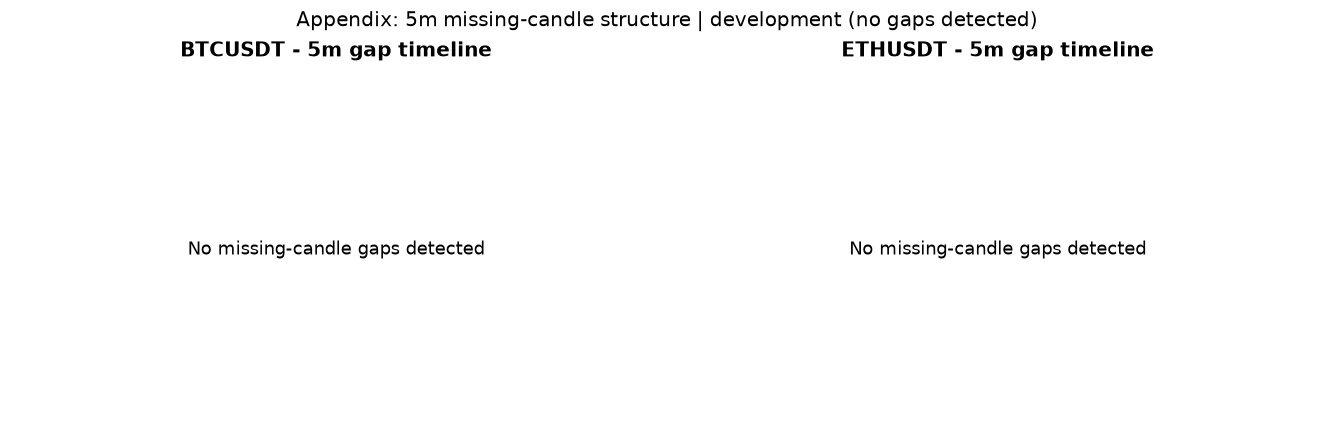

In [34]:
# A1: Missing-candle gap structure on the 5m grid (kept for reproducibility; empty by design).
fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(11, 3.6), constrained_layout=True)
for j, sym in enumerate(SYMBOLS):
    gaps = find_gaps(KL[sym]["5m"], "5m")
    ax = axes[j]
    if gaps.height:
        miss = gaps["missing"].to_numpy()
        ax.scatter(gaps["gap_start"].to_numpy(), miss, s=8, color=asset_color(sym), alpha=0.6)
        ax.set_xlabel("UTC")
        ax.set_ylabel("missing bars")
    else:
        ax.text(
            0.5,
            0.5,
            "No missing-candle gaps detected",
            ha="center",
            va="center",
            fontsize=11,
            transform=ax.transAxes,
        )
        ax.axis("off")
    ax.set_title(f"{sym} - 5m gap timeline")
fig.suptitle("Appendix: 5m missing-candle structure | development (no gaps detected)", fontsize=12)
show(
    fig,
    "f01_gap_structure_5m",
    caption="Appendix - 5m missing-candle gap timeline (development). No gaps were detected, so the panels carry an explicit annotation instead of empty axes.",
)

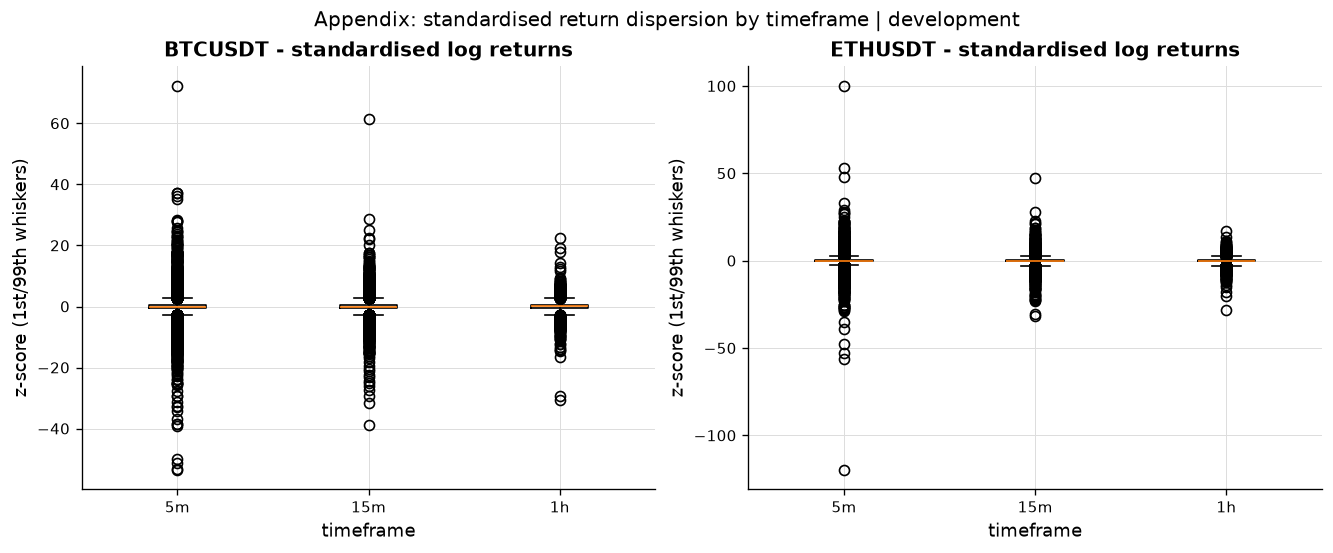

In [35]:
# A2: Standardised-return box plots by timeframe.
fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(11, 4.5), constrained_layout=True)
for j, sym in enumerate(SYMBOLS):
    data = []
    for tf in TIMEFRAMES:
        v = RET[sym][tf].select("log_return").drop_nulls().to_series().to_numpy()
        data.append((v - v.mean()) / v.std())
    axes[j].boxplot(data, tick_labels=TIMEFRAMES, showfliers=True, whis=(1, 99))
    axes[j].set_title(f"{sym} - standardised log returns")
    axes[j].set_xlabel("timeframe")
    axes[j].set_ylabel("z-score (1st/99th whiskers)")
fig.suptitle("Appendix: standardised return dispersion by timeframe | development", fontsize=12)
show(
    fig,
    "f06_return_boxplots",
    caption="Appendix - standardised log-return box plots by timeframe (development)",
)

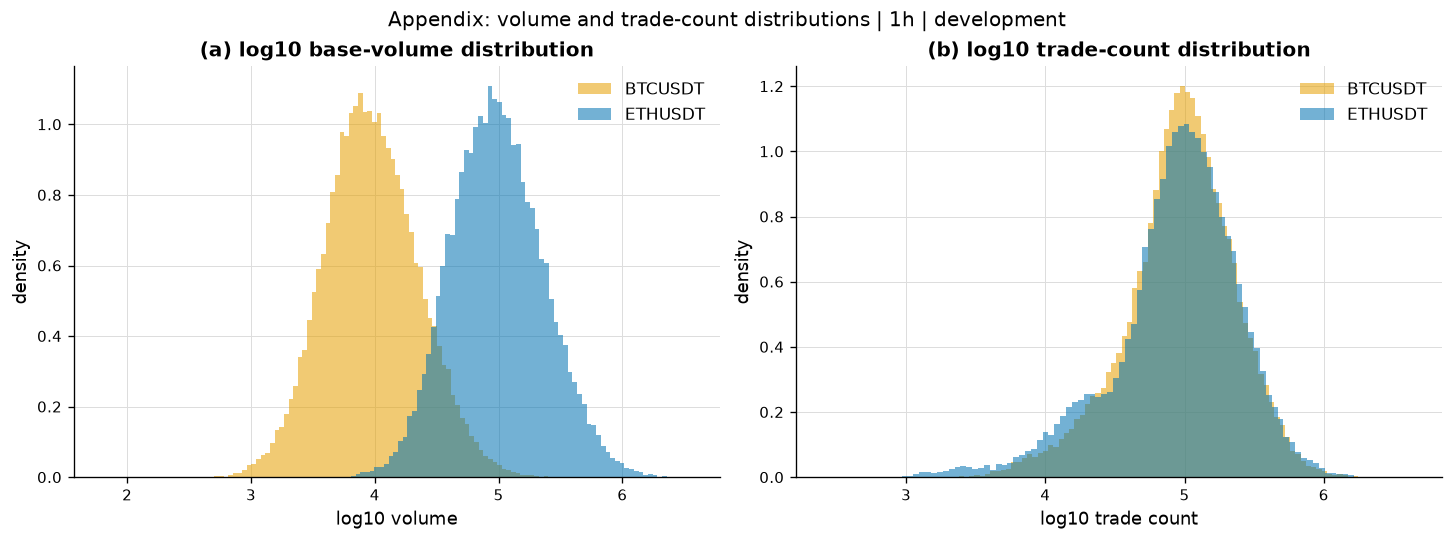

In [36]:
# A3: Full volume and trade-count distributions (log10).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
for sym in SYMBOLS:
    v = RET[sym][PRIMARY_TF]["volume"].to_numpy()
    v = v[v > 0]
    axes[0].hist(np.log10(v), bins=100, density=True, color=asset_color(sym), alpha=0.55, label=sym)
    tc = RET[sym][PRIMARY_TF]["trade_count"].to_numpy().astype(float)
    tc = tc[tc > 0]
    axes[1].hist(
        np.log10(tc), bins=100, density=True, color=asset_color(sym), alpha=0.55, label=sym
    )
axes[0].set_title("(a) log10 base-volume distribution")
axes[0].set_xlabel("log10 volume")
axes[0].set_ylabel("density")
axes[0].legend()
axes[1].set_title("(b) log10 trade-count distribution")
axes[1].set_xlabel("log10 trade count")
axes[1].set_ylabel("density")
axes[1].legend()
fig.suptitle("Appendix: volume and trade-count distributions | 1h | development", fontsize=12)
show(
    fig,
    "f12_volume_activity",
    caption="Appendix - log-volume and log trade-count distributions (1h, development)",
)

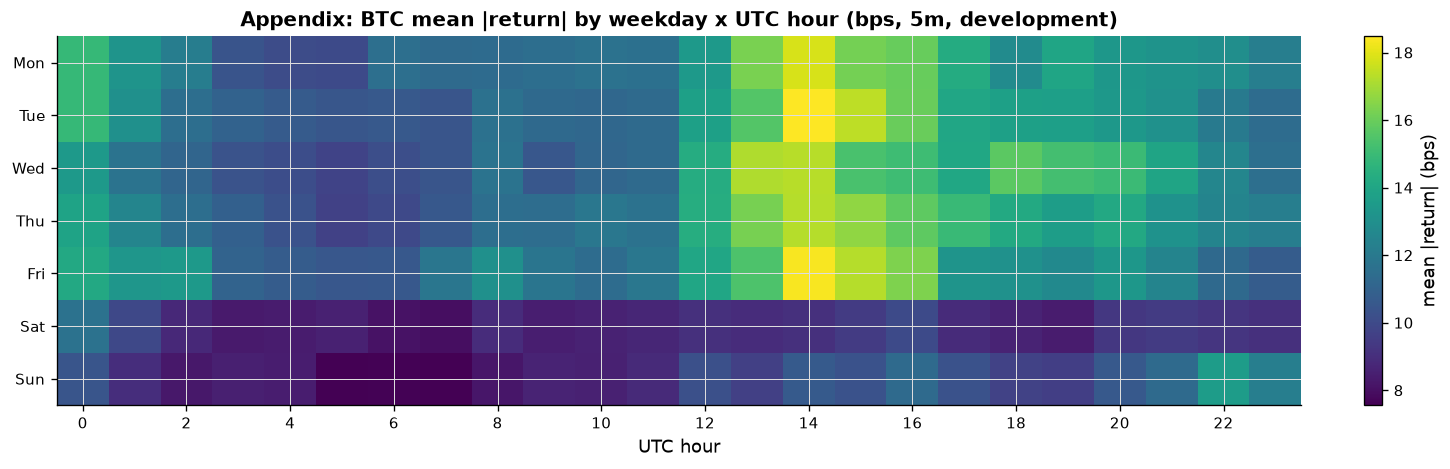

Notebook complete: all sections executed on development data only; holdout partition not read.


In [37]:
# A4: Hour-by-weekday heatmap of BTC mean |return| (bps, 5m).
btc_hw = seas["BTCUSDT"].with_columns(
    pl.col("open_time").dt.hour().alias("hour"), pl.col("open_time").dt.weekday().alias("weekday")
)
piv = (
    btc_hw.group_by("weekday", "hour")
    .agg((pl.col("abs_ret").mean() * 1e4).alias("m"))
    .sort("weekday", "hour")
)
hw = np.full((7, 24), np.nan)
for r in piv.iter_rows(named=True):
    hw[int(r["weekday"]) - 1, int(r["hour"])] = r["m"]
fig, ax = plt.subplots(figsize=(12, 3.8), constrained_layout=True)
im = ax.imshow(hw, aspect="auto", cmap="viridis")
ax.set_xticks(range(0, 24, 2), [str(h) for h in range(0, 24, 2)])
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xlabel("UTC hour")
ax.set_title("Appendix: BTC mean |return| by weekday x UTC hour (bps, 5m, development)")
fig.colorbar(im, ax=ax, label="mean |return| (bps)")
show(
    fig,
    "fa2_seasonality_heatmap",
    caption="Appendix - BTC mean |return| by weekday and UTC hour (5m, development)",
)
print(
    "Notebook complete: all sections executed on development data only; holdout partition not read."
)

## 15. Advanced dependence analyses (inferential depth)

The sections above are descriptive. This section adds three **inferential** analyses that turn point
observations into uncertainty-aware, testable statements, still strictly on development data and with
the holdout frozen. All resampling uses a **moving-block bootstrap** (24-bar blocks) so the temporal
dependence documented in Sections 7 and 12 is preserved; an i.i.d. bootstrap would understate the
sampling variability.

- **15.1 Confidence intervals** for the mean return, realised volatility, Sharpe ratio, the BTC-ETH
  correlation and the differences *between frequencies* (figure `f22`, table `t37`).
- **15.2 Regime comparison** of key variables across low/medium/high volatility regimes via
  Kruskal-Wallis, Dunn post-hoc (Benjamini-Hochberg corrected) and the epsilon-squared effect size
  (figure `f23`, tables `t38`/`t38b`).
- **15.3 Extreme-tail dependence** between BTC and ETH: calm-vs-stress correlation, conditional crash
  probabilities and 5%/1% co-exceedance, plus their time evolution (figure `f24`, tables
  `t39`/`t39b`).

> These remain descriptive, in-sample diagnostics. A significant regime difference or a strong tail
> co-exceedance is a *hypothesis* for Chapter 5, not evidence of an exploitable edge.

shape: (12, 8)
┌──────────────────────────┬─────────────────┬───────────┬──────────┬───────────┬──────────┬───────────────┬──────────┐
│ statistic                ┆ group           ┆ timeframe ┆ estimate ┆ ci_low    ┆ ci_high  ┆ prob_positive ┆ n        │
│ ---                      ┆ ---             ┆ ---       ┆ ---      ┆ ---       ┆ ---      ┆ ---           ┆ ---      │
│ str                      ┆ str             ┆ str       ┆ f64      ┆ f64       ┆ f64      ┆ f64           ┆ f64      │
╞══════════════════════════╪═════════════════╪═══════════╪══════════╪═══════════╪══════════╪═══════════════╪══════════╡
│ mean_return_bps          ┆ BTCUSDT         ┆ 1h        ┆ 0.475745 ┆ -0.133658 ┆ 1.024047 ┆ null          ┆ 52607.0  │
│ sharpe_annualised        ┆ BTCUSDT         ┆ 1h        ┆ 0.6616   ┆ -0.182174 ┆ 1.458452 ┆ null          ┆ 52607.0  │
│ volatility_annualised    ┆ BTCUSDT         ┆ 5m        ┆ 0.668572 ┆ 0.648701  ┆ 0.691221 ┆ null          ┆ 631295.0 │
│ volatility_annualised  

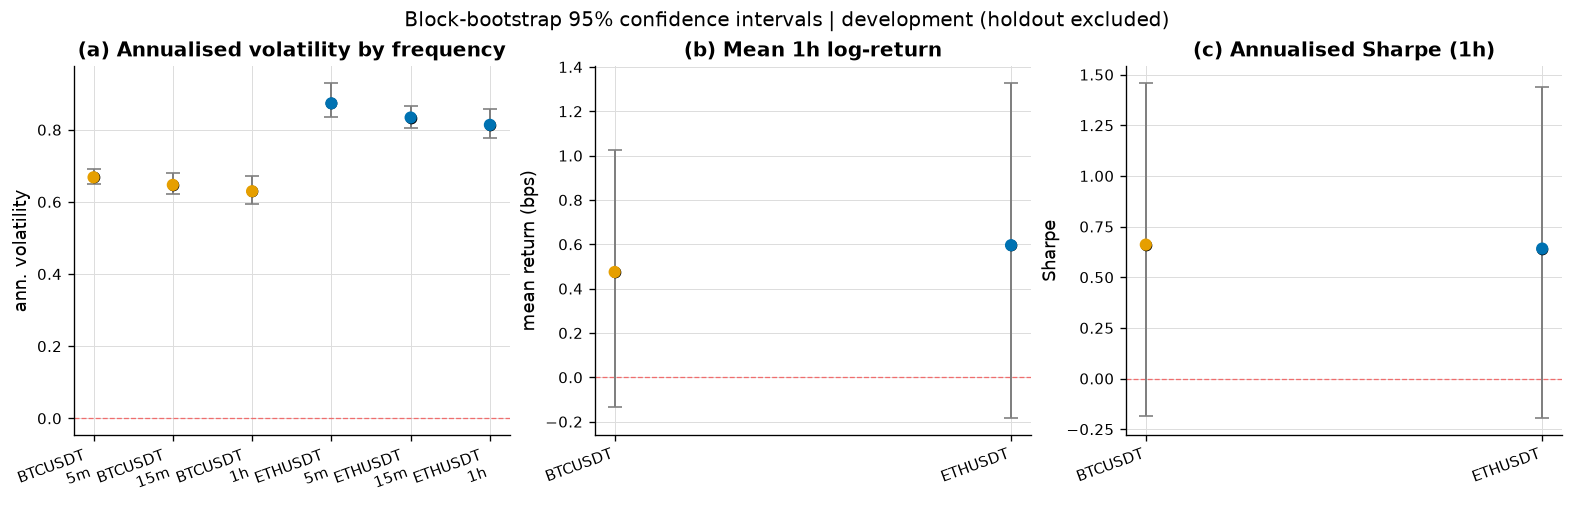

In [38]:
# 15.1 Block-bootstrap 95% confidence intervals (f22, t37).
from perp_lab.eda import bootstrap_ci, bootstrap_diff_ci, mean_stat, sharpe_stat, vol_stat

BOOT_BLOCK, BOOT_N = 24, 1000  # 24 one-hour bars = one 24/7 day
_boot_rows = []


def _ci_row(stat, group, tf, ci, scale=1.0):
    if not ci:
        return
    _boot_rows.append(
        {
            "statistic": stat,
            "group": group,
            "timeframe": tf,
            "estimate": round(float(ci["estimate"]) * scale, 6),
            "ci_low": round(float(ci["ci_low"]) * scale, 6),
            "ci_high": round(float(ci["ci_high"]) * scale, 6),
            "prob_positive": round(float(ci["prob_positive"]), 4)
            if "prob_positive" in ci
            else None,
            "n": float(ci.get("n", ci.get("n_a", float("nan")))),
        }
    )


def _lr(sym, tf):
    return RET[sym][tf].select("log_return").drop_nulls().to_series().to_numpy()


for sym in SYMBOLS:
    r1h = _lr(sym, "1h")
    _ci_row(
        "mean_return_bps",
        sym,
        "1h",
        bootstrap_ci(r1h, mean_stat, block=BOOT_BLOCK, n_boot=BOOT_N),
        scale=1e4,
    )
    _ci_row(
        "sharpe_annualised",
        sym,
        "1h",
        bootstrap_ci(r1h, sharpe_stat(24 * DAYS_PER_YEAR), block=BOOT_BLOCK, n_boot=BOOT_N),
    )
    for tf in TIMEFRAMES:
        fct = eda.annualization_factor(tf, DAYS_PER_YEAR)
        _ci_row(
            "volatility_annualised",
            sym,
            tf,
            bootstrap_ci(_lr(sym, tf) * fct, vol_stat, block=BOOT_BLOCK, n_boot=BOOT_N),
        )

_corr = eda.block_bootstrap_corr_ci(
    RET[SYMBOLS[0]]["1h"], RET[SYMBOLS[1]]["1h"], block=BOOT_BLOCK, n_boot=BOOT_N
)
if _corr:
    _boot_rows.append(
        {
            "statistic": "corr_btc_eth",
            "group": f"{SYMBOLS[0]}-{SYMBOLS[1]}",
            "timeframe": "1h",
            "estimate": _corr["corr"],
            "ci_low": _corr["ci_low"],
            "ci_high": _corr["ci_high"],
            "prob_positive": None,
            "n": _corr["n"],
        }
    )

_f5, _f1 = (
    eda.annualization_factor("5m", DAYS_PER_YEAR),
    eda.annualization_factor("1h", DAYS_PER_YEAR),
)
_ci_row(
    "diff_ann_vol_5m_minus_1h",
    SYMBOLS[0],
    "5m-1h",
    bootstrap_diff_ci(
        _lr(SYMBOLS[0], "5m") * _f5,
        _lr(SYMBOLS[0], "1h") * _f1,
        vol_stat,
        block=BOOT_BLOCK,
        n_boot=BOOT_N,
    ),
)

boot_ci = pl.DataFrame(_boot_rows)
with pl.Config(tbl_rows=20, tbl_width_chars=200):
    print(boot_ci)
save_table(
    boot_ci,
    "t37_bootstrap_confidence_intervals",
    ctx,
    caption="Block-bootstrap 95% CIs (24-bar moving blocks, 1000 resamples) for return, volatility, Sharpe, BTC-ETH correlation and the 5m-vs-1h volatility difference (development).",
)


def _forest(ax, labels, sub, title, ylabel, colors):
    x = np.arange(len(labels))
    est = np.array(sub["estimate"].to_list())
    lo = np.array(sub["ci_low"].to_list())
    hi = np.array(sub["ci_high"].to_list())
    ax.errorbar(
        x,
        est,
        yerr=np.vstack([est - lo, hi - est]),
        fmt="o",
        capsize=4,
        color="black",
        ecolor="grey",
        zorder=3,
    )
    ax.scatter(x, est, color=colors, s=40, zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.axhline(0.0, color="red", lw=0.8, ls="--", alpha=0.5)


fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
_vol = boot_ci.filter(pl.col("statistic") == "volatility_annualised")
_forest(
    axes[0],
    [f"{r['group']}\n{r['timeframe']}" for r in _vol.iter_rows(named=True)],
    _vol,
    "(a) Annualised volatility by frequency",
    "ann. volatility",
    [asset_color(r["group"]) for r in _vol.iter_rows(named=True)],
)
_mean = boot_ci.filter(pl.col("statistic") == "mean_return_bps")
_forest(
    axes[1],
    _mean["group"].to_list(),
    _mean,
    "(b) Mean 1h log-return",
    "mean return (bps)",
    [asset_color(s) for s in _mean["group"].to_list()],
)
_shp = boot_ci.filter(pl.col("statistic") == "sharpe_annualised")
_forest(
    axes[2],
    _shp["group"].to_list(),
    _shp,
    "(c) Annualised Sharpe (1h)",
    "Sharpe",
    [asset_color(s) for s in _shp["group"].to_list()],
)
fig.suptitle(
    "Block-bootstrap 95% confidence intervals | development (holdout excluded)", fontsize=12
)
show(
    fig,
    "f22_bootstrap_confidence_intervals",
    caption="Block-bootstrap 95% CIs for annualised volatility (by frequency), mean 1h return and annualised Sharpe (development).",
)

**Interpretation (15.1).** The annualised-volatility intervals are tight and never overlap zero,
and ETH's exceed BTC's at every frequency: ETH is *robustly* more volatile than BTC on development
data. The 5m-minus-1h volatility difference is positive in the large majority of resamples
(`prob_positive`), i.e. finer sampling shows slightly higher annualised volatility (a microstructure
effect), though the interval is narrow. In contrast, the mean-return and Sharpe intervals **straddle
zero**: on development data neither asset has a mean drift or Sharpe distinguishable from zero once
block dependence is accounted for - a caution that motivates cost-aware, out-of-sample validation
rather than trusting in-sample averages.

shape: (5, 6)
┌──────────────┬───────┬──────────┬────────────┬────────────┬─────────────────┐
│ variable     ┆ n     ┆ n_groups ┆ H          ┆ pvalue     ┆ epsilon_squared │
│ ---          ┆ ---   ┆ ---      ┆ ---        ┆ ---        ┆ ---             │
│ str          ┆ i64   ┆ i64      ┆ f64        ┆ f64        ┆ f64             │
╞══════════════╪═══════╪══════════╪════════════╪════════════╪═════════════════╡
│ abs_ret      ┆ 52584 ┆ 3        ┆ 7580.5561  ┆ 0.0        ┆ 0.1442          │
│ hl_range     ┆ 52584 ┆ 3        ┆ 18933.7595 ┆ 0.0        ┆ 0.3601          │
│ volume       ┆ 52584 ┆ 3        ┆ 10313.2363 ┆ 0.0        ┆ 0.1961          │
│ funding_rate ┆ 52584 ┆ 3        ┆ 1459.3314  ┆ 0.0        ┆ 0.0278          │
│ drawdown     ┆ 52584 ┆ 3        ┆ 136.6629   ┆ 2.1088e-30 ┆ 0.0026          │
└──────────────┴───────┴──────────┴────────────┴────────────┴─────────────────┘


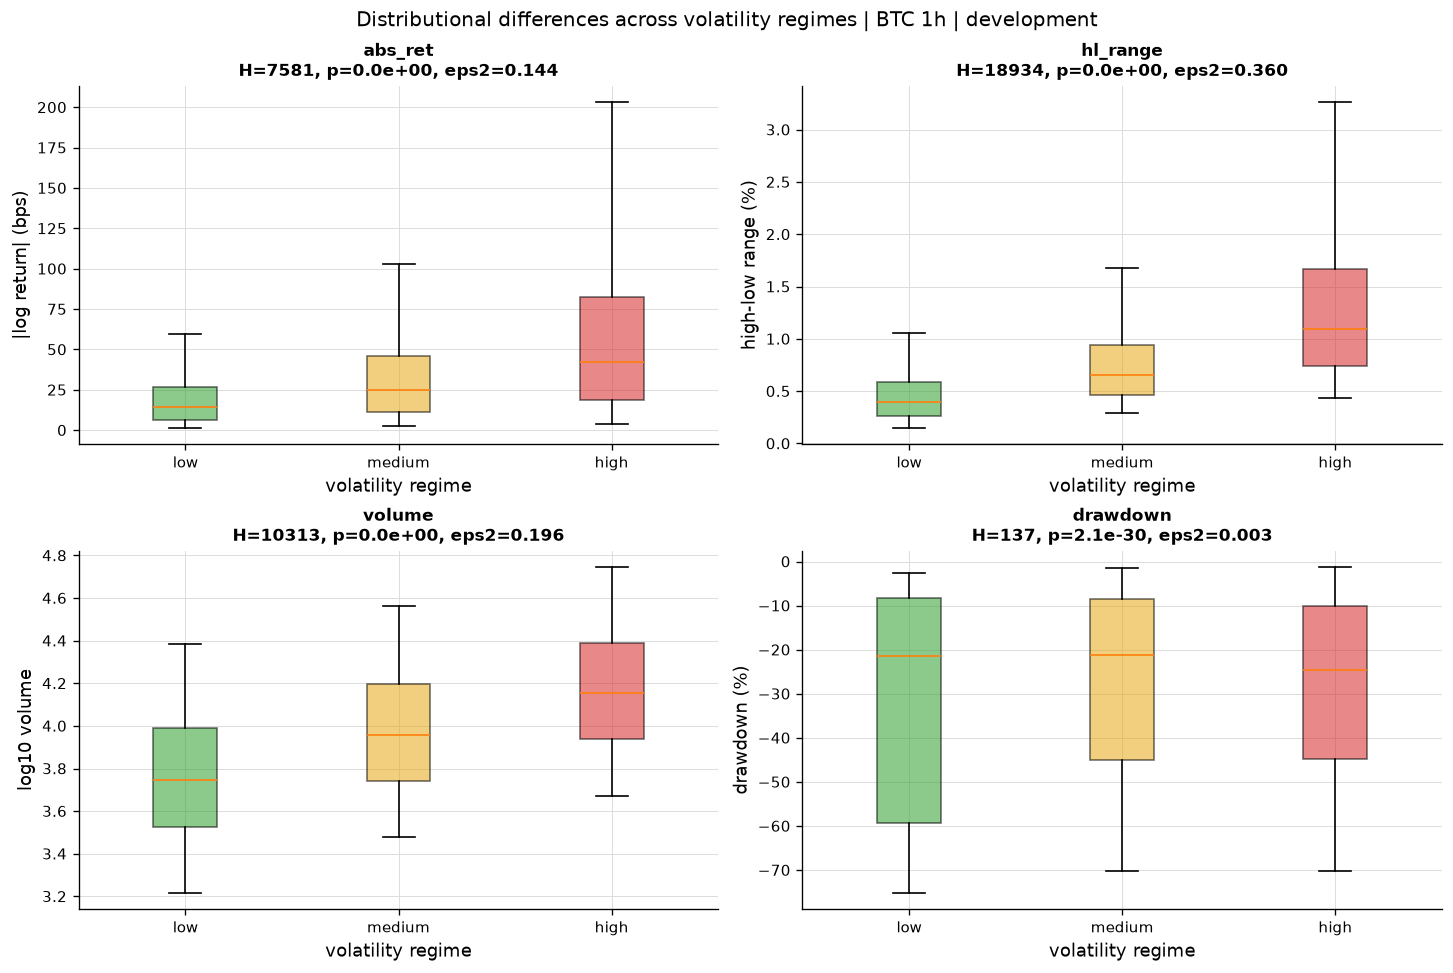

In [39]:
# 15.2 Regime comparison across volatility states (f23, t38, t38b).
REG = ("low", "medium", "high")
reg_tagged = eda.tag_trend_volatility_regimes(
    RET[SYMBOLS[0]]["1h"], trend_window=168, vol_window=24
)
reg_tagged = eda.add_drawdown(reg_tagged)
reg_tagged = eda.attach_funding(reg_tagged, FUND[SYMBOLS[0]], tolerance="8h")
reg_tagged = reg_tagged.with_columns(
    pl.col("log_return").abs().alias("abs_ret"),
    ((pl.col("high") - pl.col("low")) / pl.col("close")).alias("hl_range"),
).filter(pl.col("vol_regime").is_in(REG))

reg_vars = ["abs_ret", "hl_range", "volume", "funding_rate", "drawdown"]
regime_kw = eda.regime_comparison(reg_tagged, reg_vars)
with pl.Config(tbl_width_chars=200):
    print(regime_kw)
save_table(
    regime_kw,
    "t38_regime_kruskal",
    ctx,
    caption="Kruskal-Wallis across low/medium/high volatility regimes (BTC 1h, development): H, p-value and epsilon-squared effect size.",
)

regime_posthoc = pl.concat(
    [eda.dunn_posthoc(reg_tagged, c).with_columns(pl.lit(c).alias("variable")) for c in reg_vars]
).select("variable", "group_a", "group_b", "n_a", "n_b", "z", "p_raw", "p_adj", "reject")
save_table(
    regime_posthoc,
    "t38b_regime_dunn_posthoc",
    ctx,
    caption="Dunn post-hoc pairwise regime comparisons with Benjamini-Hochberg correction (BTC 1h, development).",
)


def _rbox(ax, col, transform, ylabel):
    data, colors = [], []
    for reg in REG:
        v = (
            reg_tagged.filter(pl.col("vol_regime") == reg)
            .select(col)
            .drop_nulls()
            .to_series()
            .to_numpy()
        )
        v = v[np.isfinite(v)]
        data.append(transform(v))
        colors.append(regime_color(reg))
    bp = ax.boxplot(data, tick_labels=list(REG), showfliers=False, patch_artist=True, whis=(5, 95))
    for patch, c in zip(bp["boxes"], colors, strict=True):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
    r = regime_kw.filter(pl.col("variable") == col)
    ann = (
        f"H={r['H'][0]:.0f}, p={r['pvalue'][0]:.1e}, eps2={r['epsilon_squared'][0]:.3f}"
        if r.height
        else ""
    )
    ax.set_title(f"{col}\n{ann}", fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("volatility regime")


fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
_rbox(axes[0, 0], "abs_ret", lambda v: v * 1e4, "|log return| (bps)")
_rbox(axes[0, 1], "hl_range", lambda v: v * 1e2, "high-low range (%)")
_rbox(axes[1, 0], "volume", lambda v: np.log10(v[v > 0]), "log10 volume")
_rbox(axes[1, 1], "drawdown", lambda v: v * 1e2, "drawdown (%)")
fig.suptitle(
    "Distributional differences across volatility regimes | BTC 1h | development", fontsize=12
)
show(
    fig,
    "f23_regime_statistical_comparison",
    caption="Per-regime distributions (5th-95th whiskers) with Kruskal-Wallis H, p-value and epsilon-squared effect size (BTC 1h, development).",
)

**Interpretation (15.2).** Every variable rejects the global null (Kruskal-Wallis `p ~ 0`), but with
this many observations significance is inevitable, so the **effect size** carries the meaning. The
high-low range is most strongly regime-dependent (largest epsilon-squared), followed by volume and
absolute return - all rise monotonically from the low to the high volatility state, and Dunn's test
(BH-corrected) rejects every pairwise comparison. Funding shows a small but ordered effect, whereas
drawdown is statistically significant yet has a **negligible** effect size: contemporaneous drawdown
does not meaningfully separate the volatility regimes. This supports using volatility-state features
(range/volume based) for later regime conditioning while treating drawdown as a risk overlay rather
than a regime discriminator.

shape: (2, 8)
┌──────────┬───────┬─────────────┬─────────────┬─────────────┬─────────────┬──────────────────────────┬──────────────────────────┐
│ quantile ┆ n     ┆ joint_lower ┆ joint_upper ┆ lower_ratio ┆ upper_ratio ┆ p_right_given_left_lower ┆ p_left_given_right_lower │
│ ---      ┆ ---   ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---                      ┆ ---                      │
│ f64      ┆ i64   ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ f64                      ┆ f64                      │
╞══════════╪═══════╪═════════════╪═════════════╪═════════════╪═════════════╪══════════════════════════╪══════════════════════════╡
│ 0.05     ┆ 52607 ┆ 0.032866    ┆ 0.028152    ┆ 13.146539   ┆ 11.260859   ┆ 0.657165                 ┆ 0.657165                 │
│ 0.01     ┆ 52607 ┆ 0.00614     ┆ 0.004828    ┆ 61.398673   ┆ 48.282548   ┆ 0.612903                 ┆ 0.612903                 │
└──────────┴───────┴─────────────┴─────────────┴─────────────┴───────

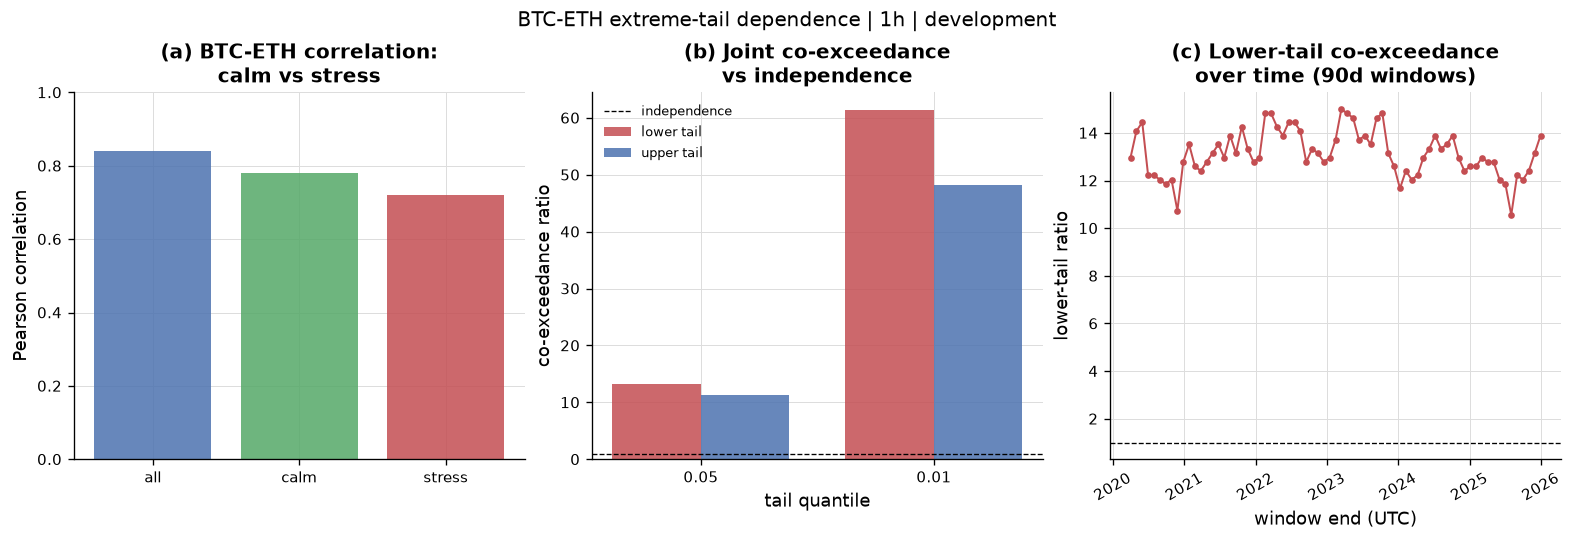

In [40]:
# 15.3 BTC-ETH extreme-tail dependence (f24, t39, t39b).
_left, _right = RET[SYMBOLS[0]]["1h"], RET[SYMBOLS[1]]["1h"]
coexc = eda.coexceedance_summary(_left, _right, quantiles=(0.05, 0.01))
with pl.Config(tbl_width_chars=220):
    print(coexc)
save_table(
    coexc,
    "t39_extreme_dependence_coexceedance",
    ctx,
    caption="BTC-ETH joint tail behaviour at 5% and 1% (1h, development): joint probabilities, exceedance ratios vs independence and conditional crash probabilities.",
)

_nvs = eda.normal_vs_stress_correlation(_left, _right, stress_quantile=0.10)
_ce05 = eda.conditional_exceedance(_left, _right, quantile=0.05, tail="lower")
_ce01 = eda.conditional_exceedance(_left, _right, quantile=0.01, tail="lower")
stress_corr = pl.DataFrame(
    [
        {"metric": "corr_all", "value": round(_nvs["corr_all"], 4)},
        {"metric": "corr_calm", "value": round(_nvs["corr_calm"], 4)},
        {"metric": "corr_stress", "value": round(_nvs["corr_stress"], 4)},
        {"metric": "corr_stress_btc_only", "value": round(_nvs["corr_stress_left"], 4)},
        {"metric": "p_eth_crash_given_btc_5pct", "value": round(_ce05["p_right_given_left"], 4)},
        {"metric": "lift_vs_independence_5pct", "value": round(_ce05["lift"], 4)},
        {"metric": "p_eth_crash_given_btc_1pct", "value": round(_ce01["p_right_given_left"], 4)},
        {"metric": "lift_vs_independence_1pct", "value": round(_ce01["lift"], 4)},
    ]
)
print(stress_corr)
save_table(
    stress_corr,
    "t39b_extreme_dependence_correlation",
    ctx,
    caption="Normal-vs-stress BTC-ETH correlation and conditional crash probabilities (1h, development). Stress = either asset in its lower decile.",
)

roll_tail = eda.rolling_tail_dependence(_left, _right, window=24 * 90, step=24 * 30, quantile=0.05)

fig = plt.figure(figsize=(13, 4.4), constrained_layout=True)
gs = fig.add_gridspec(1, 3)
ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(
    ["all", "calm", "stress"],
    [_nvs["corr_all"], _nvs["corr_calm"], _nvs["corr_stress"]],
    color=["#4C72B0", "#55A868", "#C44E52"],
    alpha=0.85,
)
ax0.set_ylim(0, 1)
ax0.set_title("(a) BTC-ETH correlation:\ncalm vs stress")
ax0.set_ylabel("Pearson correlation")
ax1 = fig.add_subplot(gs[0, 1])
_q = [str(v) for v in coexc["quantile"].to_list()]
_x = np.arange(len(_q))
_w = 0.38
ax1.bar(
    _x - _w / 2,
    coexc["lower_ratio"].to_list(),
    width=_w,
    label="lower tail",
    color="#C44E52",
    alpha=0.85,
)
ax1.bar(
    _x + _w / 2,
    coexc["upper_ratio"].to_list(),
    width=_w,
    label="upper tail",
    color="#4C72B0",
    alpha=0.85,
)
ax1.axhline(1.0, color="black", ls="--", lw=0.8, label="independence")
ax1.set_xticks(_x)
ax1.set_xticklabels(_q)
ax1.set_xlabel("tail quantile")
ax1.set_ylabel("co-exceedance ratio")
ax1.set_title("(b) Joint co-exceedance\nvs independence")
ax1.legend(fontsize=8)
ax2 = fig.add_subplot(gs[0, 2])
if roll_tail.height:
    ax2.plot(
        roll_tail["window_end"].to_list(),
        roll_tail["lower_ratio"].to_list(),
        color="#C44E52",
        marker="o",
        ms=3,
    )
ax2.axhline(1.0, color="black", ls="--", lw=0.8)
ax2.set_title("(c) Lower-tail co-exceedance\nover time (90d windows)")
ax2.set_ylabel("lower-tail ratio")
ax2.set_xlabel("window end (UTC)")
ax2.tick_params(axis="x", rotation=30)
fig.suptitle("BTC-ETH extreme-tail dependence | 1h | development", fontsize=12)
show(
    fig,
    "f24_extreme_tail_dependence",
    caption="BTC-ETH tail dependence: calm-vs-stress correlation, 5%/1% co-exceedance ratios and their time evolution (1h, development).",
)

**Interpretation (15.3).** Read together, the panels tell a risk-management story that a single
correlation number would hide. The *linear* correlation is slightly **lower** in the stress subset
than in calm bars (panel a) - but this is largely a range-restriction artefact of conditioning on a
truncated tail, and is exactly why linear correlation is the wrong tool in the extremes. The decisive
evidence is the **joint co-exceedance** (panel b): BTC and ETH crash together far more often than
independence predicts - roughly an order of magnitude at the 5% tail and much more at 1% - and the
lower tail exceeds the upper tail, so joint *crashes* are more coupled than joint rallies. The
conditional probability that ETH is in its extreme lower tail *given* BTC is there is about two thirds
(`t39b`), and the rolling window (panel c) shows this lower-tail coupling persists throughout the
development period. The practical implication for Chapter 5: BTC-ETH diversification weakens precisely
during the joint sell-offs when it is most needed, so portfolio-exposure and risk limits must be sized
on tail co-movement, not on the average correlation.

## 16. Chapter-5 extensions: tails, random-walk tests, dated regimes and alternative data

The thesis EDA chapter added a second layer of diagnostics on top of Sections 1-15. Every
estimator lives in `perp_lab.eda` (validated against synthetic processes in
`tests/unit/test_eda_ch5.py` and `test_eda_altdata.py`) and the full 16-figure chapter build is
`scripts/build_ch5_figures.py`; this section reproduces the headline numbers inside the
notebook so the EDA record is complete in one place.

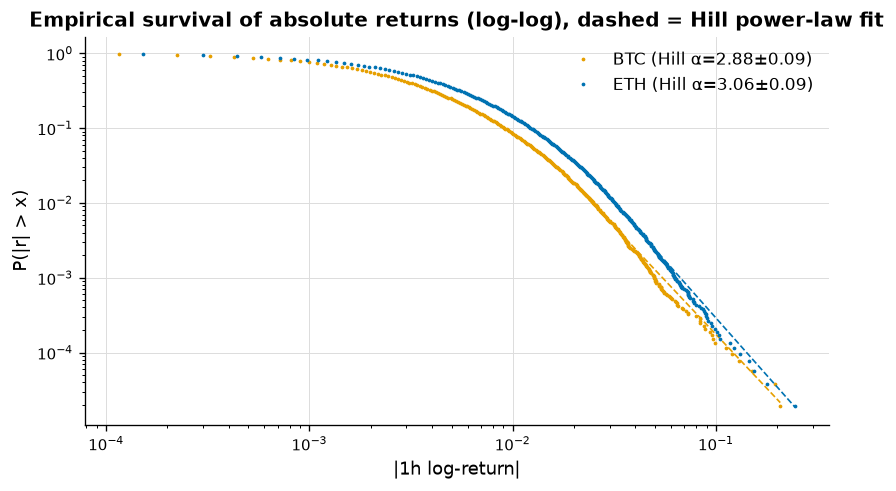

symbol,t_df,hill_alpha,hill_se,tail_fraction,k_tail_obs
str,f64,f64,f64,f64,i64
"""BTCUSDT""",1.96,2.88,0.09,0.02,1051
"""ETHUSDT""",2.14,3.06,0.09,0.02,1051


In [41]:
# 16.1 Tail machinery: Student-t fit, Hill index and the survival function (1h).
from perp_lab.eda import fit_student_t, hill_tail_index, survival_function

tail_rows = []
fig, ax = plt.subplots(figsize=(8.0, 4.2))
for sym in SYMBOLS:
    color = asset_color(sym)
    r = RET[sym]["1h"]["log_return"].drop_nulls().to_numpy()
    tfit = fit_student_t(r)
    hill = hill_tail_index(r, tail_fraction=0.02)
    tail_rows.append(
        {
            "symbol": sym,
            "t_df": round(tfit["df"], 2),
            "hill_alpha": round(hill["alpha"], 2),
            "hill_se": round(hill["se"], 2),
            "tail_fraction": hill["tail_fraction"],
            "k_tail_obs": int(hill["k"]),
        }
    )
    surv = survival_function(r).filter(pl.col("abs_return") >= 1e-4)
    ax.loglog(
        surv["abs_return"].to_list(),
        surv["survival"].to_list(),
        ".",
        ms=2.5,
        color=color,
        label=f"{sym[:3]} (Hill α={hill['alpha']:.2f}±{hill['se']:.2f})",
    )
    grid = np.logspace(np.log10(hill["threshold"]), np.log10(float(np.abs(r).max())), 50)
    ax.loglog(
        grid, 0.02 * (grid / hill["threshold"]) ** (-hill["alpha"]), "--", color=color, lw=1.0
    )
ax.set_xlabel("|1h log-return|")
ax.set_ylabel("P(|r| > x)")
ax.legend()
ax.set_title("Empirical survival of absolute returns (log-log), dashed = Hill power-law fit")
show(
    fig,
    "f25_tail_survival_hill",
    caption="Survival function of |1h returns| with Hill tail-index fits over the top 2% (development).",
)

tails = pl.DataFrame(tail_rows)
save_table(
    tails,
    "t40_tail_indices",
    ctx,
    caption="Student-t ML fit (df) and Hill tail index over the top 2% of |returns| (1h, development).",
)
tails

**Interpretation (16.1).** The ML t fit lands at df ≈ 2 (it weighs the centre), while Hill on the
top 2% gives α ≈ 2.9 (BTC) / 3.1 (ETH) — the two numbers answer different questions and both say
the same thing operationally: variance exists, the fourth moment is fragile, so kurtosis and any
statistic built on it are descriptive rather than asymptotically trustworthy.

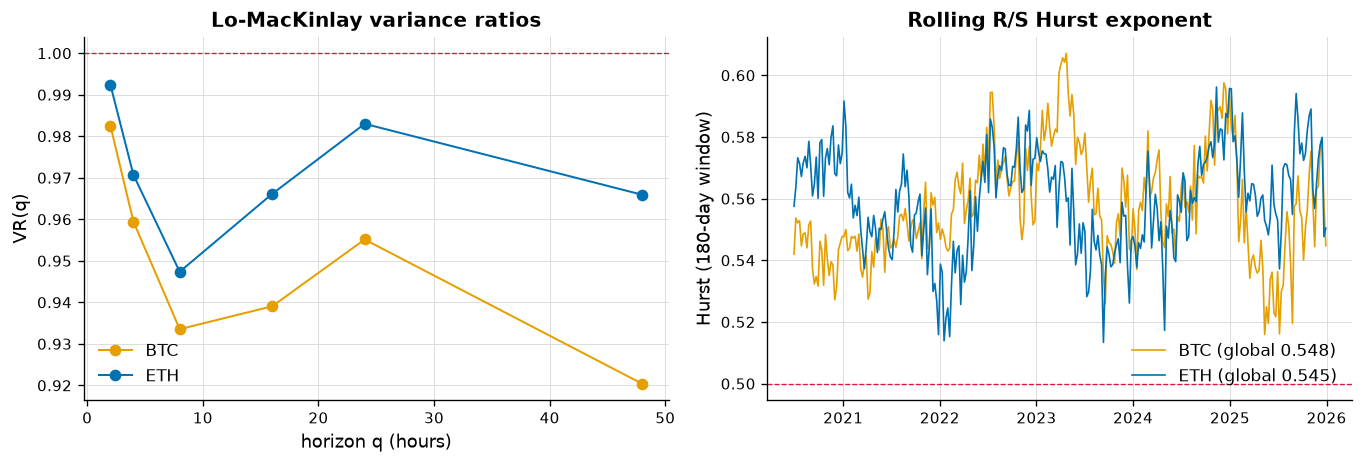

symbol,q_hours,vr,z_robust
str,i64,f64,f64
"""BTCUSDT""",2,0.983,-1.2
"""BTCUSDT""",4,0.959,-1.49
"""BTCUSDT""",8,0.934,-1.59
"""BTCUSDT""",16,0.939,-1.09
"""BTCUSDT""",24,0.955,-0.67
…,…,…,…
"""ETHUSDT""",4,0.971,-1.35
"""ETHUSDT""",8,0.947,-1.59
"""ETHUSDT""",16,0.966,-0.74


In [42]:
# 16.2 Sharper random-walk diagnostics: Lo-MacKinlay variance ratios and Hurst.
from perp_lab.eda import hurst_rs, variance_ratio_profile
from perp_lab.eda.dependence import rolling_hurst

vr_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for sym in SYMBOLS:
    color = asset_color(sym)
    frame = RET[sym]["1h"].drop_nulls("log_return")
    r = frame["log_return"].to_numpy()
    profile = variance_ratio_profile(r, [2, 4, 8, 16, 24, 48])
    for q, vr, z in zip(profile["q"], profile["vr"], profile["z_robust"]):
        vr_rows.append(
            {"symbol": sym, "q_hours": int(q), "vr": round(vr, 3), "z_robust": round(z, 2)}
        )
    axes[0].plot(profile["q"].to_list(), profile["vr"].to_list(), "o-", color=color, label=sym[:3])
    rh = rolling_hurst(frame)
    axes[1].plot(
        rh["time"].to_list(),
        rh["hurst"].to_list(),
        color=color,
        lw=1.0,
        label=f"{sym[:3]} (global {hurst_rs(r):.3f})",
    )
axes[0].axhline(1.0, ls="--", lw=0.8, color="crimson")
axes[0].set_xlabel("horizon q (hours)")
axes[0].set_ylabel("VR(q)")
axes[0].set_title("Lo-MacKinlay variance ratios")
axes[0].legend()
axes[1].axhline(0.5, ls="--", lw=0.8, color="crimson")
axes[1].set_ylabel("Hurst (180-day window)")
axes[1].set_title("Rolling R/S Hurst exponent")
axes[1].legend()
fig.tight_layout()
show(
    fig,
    "f26_variance_ratio_hurst",
    caption="Variance ratios (all below one, none beyond the robust bands) and rolling Hurst (a narrow band just above 0.5).",
)

vr_table = pl.DataFrame(vr_rows)
save_table(
    vr_table,
    "t41_variance_ratios",
    ctx,
    caption="Lo-MacKinlay VR(q) with heteroskedasticity-robust z-statistics (1h, development).",
)
vr_table

In [43]:
# 16.3 Date-frozen market regimes and BTC-ETH cointegration.
from perp_lab.eda import engle_granger_by_regime, market_regime_stats

regime_stats = market_regime_stats(RET["BTCUSDT"]["1h"], RET["ETHUSDT"]["1h"])
save_table(
    regime_stats,
    "t42_market_regime_stats",
    ctx,
    caption="Conditional statistics per date-frozen market regime (perp_lab.eda.MARKET_REGIMES).",
)

eg = engle_granger_by_regime(KL["BTCUSDT"]["1h"], KL["ETHUSDT"]["1h"])
save_table(
    eg,
    "t43_engle_granger",
    ctx,
    caption="Engle-Granger cointegration on BTC-ETH log prices: full sample and per regime window.",
)
display(regime_stats)
eg

regime,start,end,n_bars,btc_ann_return,btc_ann_vol,btc_exc_kurtosis,eth_ann_return,eth_ann_vol,eth_exc_kurtosis,btc_eth_corr
str,str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""covid_crash""","""2020-01-01""","""2020-04-01""",2183,-0.452306,1.146446,94.012386,0.116358,1.312398,69.623807,0.902735
"""expansion_2020_21""","""2020-04-01""","""2021-12-01""",14616,1.309688,0.757234,15.706556,2.129602,0.98181,11.58284,0.81979
"""contraction_2022""","""2021-12-01""","""2023-01-01""",9504,-1.140142,0.637575,11.054239,-1.247836,0.850093,10.382612,0.891708
"""recovery_2023""","""2023-01-01""","""2024-01-01""",8760,0.939481,0.427642,26.519201,0.646796,0.466267,22.2142,0.860237
"""institutional_2024_25""","""2024-01-01""","""2026-01-01""",17544,0.363381,0.486749,9.679134,0.131237,0.684798,16.774861,0.79829


window,start,end,stat,pvalue,hedge_ratio,intercept,n
str,str,str,f64,f64,f64,f64,f64
"""full_sample""","""2020-01-01""","""2026-01-01""",-1.132972,0.87459,0.75874,4.880459,52608.0
"""covid_crash""","""2020-01-01""","""2020-04-01""",-1.142631,0.87229,0.602377,5.883953,2184.0
"""expansion_2020_21""","""2020-04-01""","""2021-12-01""",-1.537655,0.746472,0.662424,5.543047,14616.0
"""contraction_2022""","""2021-12-01""","""2023-01-01""",-1.75494,0.65134,0.87489,3.597884,9504.0
"""recovery_2023""","""2023-01-01""","""2024-01-01""",-2.437939,0.307103,1.48009,-0.82879,8760.0
"""institutional_2024_25""","""2024-01-01""","""2026-01-01""",-1.915349,0.572202,0.391563,8.165731,17544.0


**Interpretation (16.3).** The regime table quantifies what the shaded volatility plot suggests
(annualised BTC volatility spans roughly 0.44-1.15 across windows, and the COVID-crash slice alone
carries excess kurtosis near 94), and Engle-Granger **never rejects** the no-cointegration null —
neither on the full sample (p = 0.87) nor inside any regime (p 0.31-0.87). The BTC-ETH pair moves
as one risk factor at hourly frequency without any stationary long-run spread to lean on.

In [44]:
# 16.4 Triple-barrier labels at the protocol's parameters (BTC, every-bar long events).
from perp_lab.eda import label_summary
from perp_lab.eda.funding import attach_funding
from perp_lab.labeling.triple_barrier import LabelCosts, TripleBarrierSpec, triple_barrier_labels

bars_l = attach_funding(RET["BTCUSDT"]["1h"], FUND["BTCUSDT"]).with_columns(
    pl.when(
        pl.col("funding_time").is_not_null()
        & (pl.col("funding_time") > pl.col("open_time") - pl.duration(hours=1))
    )
    .then(pl.col("funding_rate"))
    .otherwise(0.0)
    .alias("funding_rate_in_bar")
)
tr = pl.max_horizontal(
    pl.col("high") - pl.col("low"),
    (pl.col("high") - pl.col("close").shift(1)).abs(),
    (pl.col("low") - pl.col("close").shift(1)).abs(),
)
bars_l = bars_l.with_columns(
    (tr.rolling_mean(window_size=14, min_samples=14) / pl.col("close")).alias("atr_frac")
).drop_nulls("atr_frac")
events = bars_l.select(
    pl.col("open_time").alias("event_time"), pl.lit(1).cast(pl.Int64).alias("side")
).head(bars_l.height - 26)
labels = triple_barrier_labels(
    bars_l,
    events,
    TripleBarrierSpec(
        upper_barrier_atr=2.0,
        lower_barrier_atr=2.0,
        vertical_barrier_bars=24,
        exit_fill="next_open",
    ),
    volatility_col="atr_frac",
    costs=LabelCosts(
        fee_bps_per_side=4.0, slippage_bps_per_side=1.0, funding_rate_col="funding_rate_in_bar"
    ),
)
label_stats = pl.DataFrame(
    [{"metric": k, "value": round(v, 4)} for k, v in label_summary(labels).items()]
)
save_table(
    label_stats,
    "t44_triple_barrier_labels",
    ctx,
    caption="Triple-barrier label profile at the protocol's parameters (2 ATR / 24 bars, study costs; BTC 1h).",
)
label_stats

metric,value
str,f64
"""n_events""",52569.0
"""share_positive""",0.4956
"""share_negative""",0.5044
"""share_zero""",0.0
"""share_meta_positive""",0.4956
"""share_upper""",0.4304
"""share_lower""",0.4231
"""share_vertical""",0.1465
"""median_holding_bars""",9.0


**Interpretation (16.4).** At the frozen barrier geometry the labels are essentially balanced
(49.6% / 50.4%, no neutral class at a zero dead-band), the median event resolves in 9 bars and only
~15% survive to the vertical barrier — so the meta-labeling layer needs no class-imbalance
machinery, exactly as Chapter 5 states.

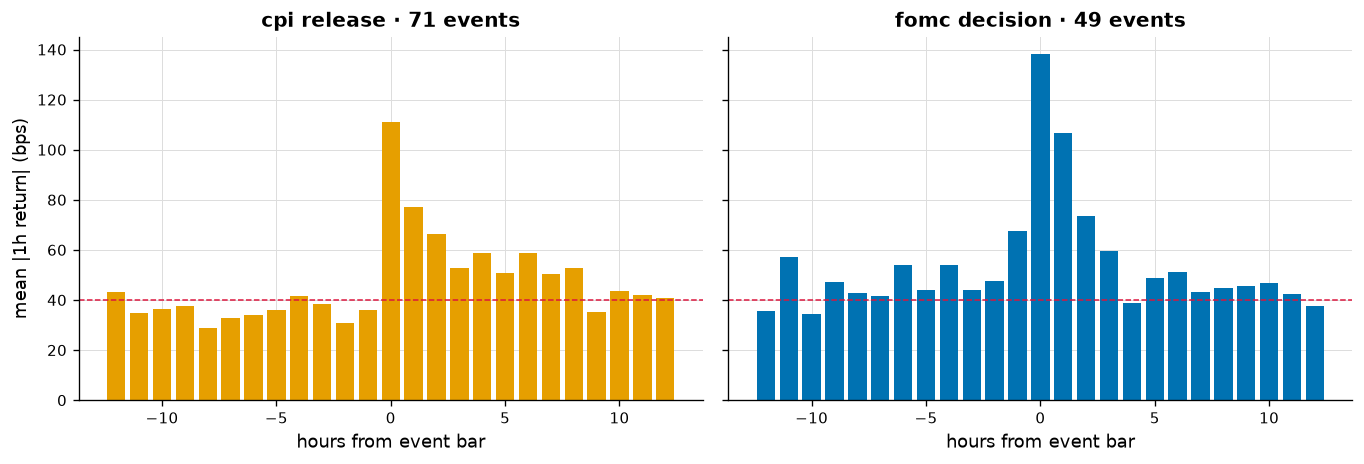

event,n_events,n_control,event_mean_bps,control_mean_bps,ratio,p_value
str,f64,f64,f64,f64,f64,f64
"""cpi_release""",71.0,4313.0,111.2747,43.363,2.5661,0.0005
"""fomc_decision""",49.0,8719.0,138.2082,43.0182,3.2128,0.0005


In [45]:
# 16.5 Alternative data: Fear & Greed conditioning and scheduled macro events.
# Inputs are materialised by scripts/ingest_altdata.py (data/external/*.parquet,
# SHA-256 manifests in data/manifests).
from perp_lab.eda.altdata import (
    event_hour_vs_matched_control,
    event_study,
    fear_greed_conditional,
    load_fear_greed,
    load_macro_events,
)

fg = load_fear_greed(Path("data/external/fear_greed.parquet"), holdout_start=LAKE.holdout_start)
events_macro = load_macro_events(
    Path("data/external/us_macro_events.parquet"), holdout_start=LAKE.holdout_start
)

fg_table = fear_greed_conditional(fg, RET["BTCUSDT"]["1h"], horizon_bars=24)
save_table(
    fg_table,
    "t45_fear_greed_conditional",
    ctx,
    caption="Next-24h BTC return by Fear & Greed quintile with moving-block bootstrap CIs (one-day availability lag).",
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharey=True)
matched_rows = []
for ax, kind, color in (
    (axes[0], "cpi_release", asset_color("BTCUSDT")),
    (axes[1], "fomc_decision", asset_color("ETHUSDT")),
):
    times = events_macro.filter(pl.col("event_type") == kind)["datetime_utc"]
    study = event_study(RET["BTCUSDT"]["1h"], times, window_bars=12)
    ax.bar(
        study["offset_bars"].to_list(), study["mean_absret_bps"].to_list(), color=color, width=0.8
    )
    base = float(RET["BTCUSDT"]["1h"]["log_return"].abs().mean() * 1e4)
    ax.axhline(base, ls="--", lw=0.9, color="crimson")
    ax.set_title(f"{kind.replace('_', ' ')} · {study['n_events'][0]} events")
    ax.set_xlabel("hours from event bar")
    matched = event_hour_vs_matched_control(RET["BTCUSDT"]["1h"], times)
    matched_rows.append({"event": kind, **{k: round(v, 4) for k, v in matched.items()}})
axes[0].set_ylabel("mean |1h return| (bps)")
fig.tight_layout()
show(
    fig,
    "f27_macro_event_study",
    caption="BTC hourly volatility around scheduled US macro events; dashed line = unconditional mean (development).",
)

matched_table = pl.DataFrame(matched_rows)
save_table(
    matched_table,
    "t46_event_matched_control",
    ctx,
    caption="Event-bar |return| vs same-UTC-hour non-event control with permutation p-values (BTC 1h).",
)
matched_table

**Interpretation (16.5).** The Fear & Greed level does **not** order next-day signed returns (every
quintile's CI is wide; there is no monotone gradient), while the macro calendar orders *variance*
decisively: CPI and FOMC hours carry 2.5-3.2x the absolute return of seasonality-matched non-event
hours (permutation p < 0.001), with elevated volatility persisting two to three hours. This is the
event-level expression of the thesis's central stylized fact — *when* the market will move is far
more predictable than *in which direction* — and it motivates the pre-registered Gate S3 family
(`macro_event_brake`, ADR 0019) rather than any retroactive filter on already-evaluated families.